### Old version

In [ ]:
import pandas as pd
import numpy as np
from tableone import TableOne
import pingouin as pg
import seaborn as sns
import colorlog
import logging
import statsmodels.formula.api as smf
from pathlib import Path
from typing import List, Dict
import matplotlib.pyplot as plt
import os

# Constants
RAW_MERGE_FILE = "24EI+03TS-raw-merge.xlsx"
FEATURES_FILE = "features_24EI_compiled.csv"
PATIENT_ID_PREFIX = "24EI-"
PLOTS_DIR = Path("plots")
CLINICAL_COLUMNS = [
    'USUBJID', 'AGE', 'SEX', 'OUTCOME',
    'Adrenaline/Urine (µg/24h)', 'Noradrenaline/Urine (µg/24h)', 'Dopamine/Urine (µg/24h)',
    'ANSD d1', 'ANSD d5', 'ANSD'
]
HRV_COLUMNS = [
    'patient_id', 'date', 'sdnn', 'rmssd', 'nn50', 'pnn50',
    'hrv_triangular_index', 'lf_power', 'hf_power', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_area', 'diastolic_area',
    'systolic_slope', 'diastolic_slope', 'signal_skewness', 'peak_trend_slope',
    'systolic_amplitude_variability', 'diastolic_amplitude_variability', 'dfa'
]
CATECHOLAMINE_RENAME = {
    'Adrenaline/Urine (µg/24h)': 'Adrenalin',
    'Noradrenaline/Urine (µg/24h)': 'Noradrenalin',
    'Dopamine/Urine (µg/24h)': 'Dopamin'
}
PPG_FEATURES = [
    'sdnn', 'rmssd', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_slope', 'diastolic_slope',
    'heart_rate', 'sample_entropy'
]

# Setup colored logging
def setup_logging() -> logging.Logger:
    """Configure colored logging with custom formatting."""
    handler = colorlog.StreamHandler()
    handler.setFormatter(
        colorlog.ColoredFormatter(
            '%(log_color)s%(levelname)s: %(message)s',
            log_colors={
                'DEBUG': 'cyan',
                'INFO': 'green',
                'WARNING': 'yellow',
                'ERROR': 'red',
                'CRITICAL': 'red,bg_white',
            }
        )
    )
    logger = colorlog.getLogger()
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)
    return logger

logger = setup_logging()

# Load and validate data
def load_data(file_path: str, file_type: str = 'excel') -> pd.DataFrame:
    """
    Load data from Excel or CSV file with error handling.
    
    Args:
        file_path: Path to the file.
        file_type: 'excel' or 'csv'.
    
    Returns:
        Loaded DataFrame.
    
    Raises:
        FileNotFoundError: If file is not found.
        ValueError: If file type is invalid.
    """
    logger.info(f"Loading {file_type} file: {file_path}...")
    try:
        if file_type == 'excel':
            df = pd.read_excel(file_path)
        elif file_type == 'csv':
            df = pd.read_csv(file_path)
        else:
            raise ValueError(f"Unsupported file type: {file_type}")
        logger.debug(f"Loaded dataset with shape: {df.shape}")
        return df
    except FileNotFoundError:
        logger.error(f"File '{file_path}' not found. Please check the path.")
        raise

def validate_columns(df: pd.DataFrame, required_columns: List[str]) -> None:
    """
    Validate that required columns exist in the DataFrame.
    
    Args:
        df: DataFrame to validate.
        required_columns: List of required column names.
    
    Raises:
        ValueError: If any required columns are missing.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        logger.error(f"Missing columns: {missing}")
        raise ValueError(f"Missing columns: {missing}")

def preprocess_clinical_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess clinical data: select columns, filter, mutate, and rename.
    
    Args:
        df: Raw clinical DataFrame.
    
    Returns:
        Preprocessed DataFrame with renamed columns and patient_id.
    """
    logger.info("Preprocessing clinical data...")
    
    # Select columns
    validate_columns(df, CLINICAL_COLUMNS)
    clinical = df[CLINICAL_COLUMNS].copy()
    logger.debug(f"Selected columns, shape: {clinical.shape}")
    
    # Filter out NA in Adrenaline
    clinical = clinical.dropna(subset=['Adrenaline/Urine (µg/24h)'])
    logger.debug(f"After filtering NA, shape: {clinical.shape}")
    
    # Mutate ANSD columns
    clinical['ANSD d1'] = clinical['ANSD d1'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    clinical['ANSD d5'] = clinical['ANSD d5'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    logger.debug("ANSD columns mutated.")
    
    # Rename catecholamine columns
    clinical = clinical.rename(columns=CATECHOLAMINE_RENAME)
    logger.debug("Catecholamine columns renamed.")
    
    # Rename USUBJID to patient_id and add prefix
    clinical = clinical.rename(columns={'USUBJID': 'patient_id'})
    clinical['patient_id'] = PATIENT_ID_PREFIX + clinical['patient_id'].astype(str)
    logger.debug("Patient_id renamed and prefixed.")
    
    return clinical

def generate_summary_table(df: pd.DataFrame, columns: List[str], groupby: str) -> TableOne:
    """
    Generate a summary table using TableOne.
    
    Args:
        df: DataFrame to summarize.
        columns: Columns to include in the summary.
        groupby: Column to group by.
    
    Returns:
        TableOne object.
    """
    logger.info(f"Generating summary table for {columns} by {groupby}...")
    table = TableOne(
        df,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True
    )
    logger.debug("Summary table generated.")
    return table

def merge_with_features(clinical: pd.DataFrame, features_file: str) -> pd.DataFrame:
    """
    Merge clinical data with features data on patient_id.
    
    Args:
        clinical: Preprocessed clinical DataFrame.
        features_file: Path to features CSV file.
    
    Returns:
        Merged DataFrame.
    
    Raises:
        ValueError: If merge results in an empty DataFrame.
    """
    features = load_data(features_file, file_type='csv')
    logger.info("Merging clinical and features data...")
    merged = pd.merge(
        clinical,
        features,
        left_on='patient_id',
        right_on='patient_id',
        how='inner'
    )
    logger.debug(f"After merging, shape: {merged.shape}")
    logger.info(f"Unique patients after merge: {merged['patient_id'].nunique()}")
    
    if merged.empty:
        logger.error("Merge resulted in an empty DataFrame. Check patient_id values.")
        raise ValueError("Merge resulted in an empty DataFrame.")
    
    return merged

def process_hrv_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Process HRV data: filter, select columns, assign Day1/Day5 labels, and pivot.
    
    Args:
        df: Merged DataA股Frame.
    
    Returns:
        Pivoted DataFrame with Day1 and Day5 columns.
    """
    logger.info("Processing HRV data...")
    
    # Filter patients with exactly 2 records
    hrv = df.groupby('patient_id').filter(lambda x: len(x) == 2)
    logger.debug(f"After filtering 2 records, shape: {hrv.shape}")
    
    # Select HRV columns
    available_hrv_columns = [col for col in HRV_COLUMNS if col in hrv.columns]
    if len(available_hrv_columns) < len(HRV_COLUMNS):
        logger.warning(f"Missing HRV columns: {[col for col in HRV_COLUMNS if col not in hrv.columns]}")
    hrv = hrv[available_hrv_columns].copy()
    logger.debug(f"HRV columns selected, shape: {hrv.shape}")
    
    # Convert date to datetime
    if 'date' not in hrv.columns:
        logger.error("Column 'date' not found.")
        raise ValueError("Column 'date' not found.")
    hrv['Date'] = pd.to_datetime(hrv['date'], errors='coerce')
    if hrv['Date'].isna().all():
        logger.error("All Date values are invalid or missing.")
        raise ValueError("All Date values are invalid or missing.")
    logger.debug(f"Date NAs: {hrv['Date'].isna().sum()}")
    
    # Assign Day1 and Day5 labels
    hrv = hrv.sort_values(['patient_id', 'Date'])
    hrv['DayLabel'] = hrv.groupby('patient_id')['Date'].transform(
        lambda x: np.where(x == x.min(), 'Day1', np.where(x == x.max(), 'Day5', np.nan))
    )
    hrv = hrv.dropna(subset=['DayLabel']).reset_index(drop=True)
    logger.debug(f"After labeling, shape: {hrv.shape}")
    
    # Pivot to wide format
    pivot_columns = [col for col in hrv.columns if col not in ['patient_id', 'Date', 'DayLabel', 'date']]
    hrv_wide = hrv.pivot(
        index='patient_id',
        columns='DayLabel',
        values=pivot_columns
    )
    hrv_wide.columns = [f"{col[0]}_{col[1]}" for col in hrv_wide.columns]
    hrv_wide = hrv_wide.reset_index()
    logger.debug(f"Pivoted shape: {hrv_wide.shape}")
    
    return hrv_wide

def aggregate_medians(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate medians for Day1 and Day5 columns.
    
    Args:
        df: Pivoted HRV DataFrame.
    
    Returns:
        Aggregated DataFrame with median columns.
    """
    logger.info("Aggregating medians for Day1 and Day5...")
    aggregated = df.copy()
    for col in df.columns:
        if col.endswith('Day1') or col.endswith('Day5'):
            if pd.api.types.is_numeric_dtype(df[col]):
                aggregated[f"{col}_median"] = df[col].median()
            else:
                logger.warning(f"Skipping median for non-numeric column: {col}")
    
    # Clean column names
    aggregated.columns = aggregated.columns.str.replace('Day1_Day1', 'Day1').str.replace('Day5_Day5', 'Day5').str.replace('_median', '')
    logger.debug("Column names cleaned.")
    
    return aggregated

def summarize_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize features with medians, IQRs, and Wilcoxon tests for Day1 vs Day5.
    
    Args:
        df: Aggregated DataFrame.
    
    Returns:
        Summary DataFrame with statistics.
    """
    logger.info("Summarizing features...")
    features = [col for col in df.columns if col != 'patient_id' and not col.lower().startswith('date')]
    base_features = list(set([col.replace('_Day1', '').replace('_Day5', '') for col in features]))
    
    def summarize_single_feature(feature: str) -> pd.Series:
        logger.info(f"Summarizing feature: {feature}")
        day1 = df[f"{feature}_Day1"].dropna()
        day5 = df[f"{feature}_Day5"].dropna()
        
        # Calculate medians and quantiles
        med1 = np.median(day1)
        q1_1, q3_1 = np.percentile(day1, [25, 75])
        med5 = np.median(day5)
        q1_5, q3_5 = np.percentile(day5, [25, 75])
        
        # Wilcoxon test
        try:
            p = pg.wilcoxon(day1, day5, paired=True)['p-val'].iloc[0]
        except:
            p = np.nan
            logger.warning(f"Wilcoxon test failed for {feature}, returning NA.")
        
        return pd.Series({
            'Feature': feature,
            'Day1_Median_IQR': f"{med1:.1f} ({q1_1:.1f}–{q3_1:.1f})",
            'Day5_Median_IQR': f"{med5:.1f} ({q1_5:.1f}–{q3_5:.1f})",
            'P_value': f"{p:.3f}" if not np.isnan(p) else 'NA'
        })
    
    summary = pd.DataFrame([summarize_single_feature(f) for f in base_features])
    logger.debug("Summary table generated.")
    return summary

def detect_outliers(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """
    Detect outliers using IQR method for two columns with validation.
    
    Args:
        df: DataFrame with data.
        x_col: X-axis column name.
        y_col: Y-axis column name.
    
    Returns:
        DataFrame of outliers with patient_id and values.
    """
    logger.info(f"Detecting outliers for {x_col} vs {y_col}...")
    df_clean = df[[x_col, y_col, 'patient_id']].dropna()
    
    # Validate data size
    if len(df_clean) < 4:  # Need at least 4 points for meaningful IQR
        logger.warning(f"Too few data points ({len(df_clean)}) for {x_col} vs {y_col}. Skipping outlier detection.")
        return pd.DataFrame(columns=[x_col, y_col, 'patient_id', 'Plot'])
    
    logger.debug(f"Valid data points for {x_col} vs {y_col}: {len(df_clean)}")
    
    def get_outlier_indices(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return (series < lower) | (series > upper)
    
    x_outliers = get_outlier_indices(df_clean[x_col])
    y_outliers = get_outlier_indices(df_clean[y_col])
    outliers = df_clean[x_outliers | y_outliers]
    
    if not outliers.empty:
        outliers['Plot'] = f"{y_col} vs {x_col}"
    
    logger.debug(f"Found {len(outliers)} outliers for {x_col} vs {y_col}.")
    return outliers

def plot_ppg_features(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Plot PPG features vs Adrenalin, detect outliers, annotate outliers with patient_id, and save plots.
    
    Args:
        df: DataFrame with data.
        features: List of PPG feature column names.
        x_col: X-axis column name (default: 'Adrenalin').
        output_dir: Directory to save plots.
    
    Returns:
        DataFrame of all outliers across plots.
    """
    logger.info("Creating PPG feature plots and detecting outliers...")
    output_dir.mkdir(parents=True, exist_ok=True)
    all_outliers = []
    
    sns.set_style("whitegrid")
    for feature in features:
        if feature not in df.columns or x_col not in df.columns:
            logger.warning(f"Skipping plot for {feature} vs {x_col}: column missing.")
            continue
        
        # Detect outliers
        outliers = detect_outliers(df, x_col, feature)
        if not outliers.empty:
            all_outliers.append(outliers)
        
        # Create scatter plot with regression line
        logger.info(f"Plotting {feature} vs {x_col}...")
        g = sns.lmplot(
            data=df,
            x=x_col,
            y=feature,
            scatter_kws={'color': 'blue', 's': 50},
            line_kws={'color': 'red'},
            ci=95
        )
        
        # Highlight and annotate outliers
        if not outliers.empty:
            ax = g.ax
            for _, row in outliers.iterrows():
                ax.scatter(row[x_col], row[feature], color='red', s=100, label='Outlier' if _ == 0 else None)
                ax.text(
                    row[x_col] + 0.5, row[feature] + 0.5,
                    row['patient_id'],
                    fontsize=8, color='black', ha='left', va='bottom'
                )
            ax.legend()
        
        g.set(
            title=f"Regression of {feature.upper()} vs Adrenaline/Urine (µg/24h)",
            xlabel="Adrenaline/Urine (µg/24h)",
            ylabel=feature.upper()
        )
        
        # Save plot
        plot_path = output_dir / f"{feature}_vs_adrenalin.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved plot to {plot_path}")
    
    # Combine outliers
    outliers_df = pd.concat(all_outliers, ignore_index=True) if all_outliers else pd.DataFrame()
    if not outliers_df.empty:
        # Add PPG feature value column
        outliers_df['PPG_Value'] = outliers_df.apply(
            lambda row: row[row['Plot'].split(' vs ')[0]], axis=1
        )
        outliers_path = output_dir / "outliers_summary.csv"
        outliers_df.to_csv(outliers_path, index=False)
        logger.info(f"Saved outliers summary to {outliers_path}")
    
    return outliers_df

def create_additional_plots(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', output_dir: Path = PLOTS_DIR) -> None:
    """
    Create additional plots: pair plot and correlation heatmap.
    
    Args:
        df: DataFrame with data.
        features: List of features to include.
        x_col: X-axis column name (default: 'Adrenalin').
        output_dir: Directory to save plots.
    """
    logger.info("Creating additional plots...")
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Select available columns
    plot_cols = [x_col] + [f for f in features if f in df.columns]
    if len(plot_cols) < 2:
        logger.warning("Not enough columns for pair plot or heatmap.")
        return
    
    # Pair plot
    logger.info("Creating pair plot...")
    sns.set_style("whitegrid")
    pair_plot = sns.pairplot(
        df[plot_cols],
        diag_kind='kde',
        plot_kws={'color': 'blue', 's': 50}
    )
    pair_plot.fig.suptitle("Pair Plot of Adrenalin and PPG Features", y=1.02)
    pair_path = output_dir / "pair_plot.png"
    pair_plot.savefig(pair_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved pair plot to {pair_path}")
    
    # Correlation heatmap
    logger.info("Creating correlation heatmap...")
    corr = df[plot_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title("Correlation Heatmap of Adrenalin and PPG Features")
    heatmap_path = output_dir / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved heatmap to {heatmap_path}")

def main():
    """Main function to orchestrate the data processing pipeline."""
    logger = setup_logging()
    
    # Load and preprocess clinical data
    clinical_raw = load_data(RAW_MERGE_FILE, file_type='excel')
    clinical = preprocess_clinical_data(clinical_raw)
    
    # Generate summary table for catecholamines
    summary_table = generate_summary_table(
        clinical,
        columns=['Adrenalin', 'Noradrenalin', 'Dopamin'],
        groupby='ANSD'
    )
    print(summary_table)
    
    # Merge with features data
    merged = merge_with_features(clinical, FEATURES_FILE)
    
    # Process HRV data
    hrv_wide = process_hrv_data(merged)
    
    # Aggregate medians
    aggregated = aggregate_medians(hrv_wide)
    
    # Summarize features
    feature_summary = summarize_features(aggregated)
    print("Feature Summary Table:")
    print(feature_summary)
    
    # Split merged data into odd and even rows
    logger.info("Splitting merged data into odd and even rows...")
    merged_2records = merged.groupby('patient_id').filter(lambda x: len(x) == 2)
    evens = merged_2records.iloc[1::2].copy()
    logger.debug(f"Even rows shape: {evens.shape}")
    
    # Plot PPG features and detect outliers
    outliers = plot_ppg_features(evens, PPG_FEATURES)
    if not outliers.empty:
        print("Outliers Detected:")
        print(outliers[['Plot', 'patient_id', 'Adrenalin', 'PPG_Value']])
    
    # Create additional plots
    create_additional_plots(evens, PPG_FEATURES)

if __name__ == "__main__":
    main()

### Analysis of the data

In [ ]:
import pandas as pd
import numpy as np
from tableone import TableOne
import pingouin as pg
import seaborn as sns
import colorlog
import logging
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from pathlib import Path
from typing import List, Dict
import matplotlib.pyplot as plt
import os

# Constants
RAW_MERGE_FILE = "24EI+03TS-raw-merge.xlsx"
FEATURES_FILE = "features_24EI_compiled.csv"
PATIENT_ID_PREFIX = "24EI-"
PLOTS_DIR = Path("plots")
CLINICAL_COLUMNS = [
    'USUBJID', 'AGE', 'SEX', 'OUTCOME',
    'Adrenaline/Urine (µg/24h)', 'Noradrenaline/Urine (µg/24h)', 'Dopamine/Urine (µg/24h)',
    'ANSD d1', 'ANSD d5', 'ANSD'
]
HRV_COLUMNS = [
    'patient_id', 'date', 'sdnn', 'rmssd', 'nn50', 'pnn50',
    'hrv_triangular_index', 'lf_power', 'hf_power', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_area', 'diastolic_area',
    'systolic_slope', 'diastolic_slope', 'signal_skewness', 'peak_trend_slope',
    'systolic_amplitude_variability', 'diastolic_amplitude_variability', 'dfa'
]
CATECHOLAMINE_RENAME = {
    'Adrenaline/Urine (µg/24h)': 'Adrenalin',
    'Noradrenaline/Urine (µg/24h)': 'Noradrenalin',
    'Dopamine/Urine (µg/24h)': 'Dopamin'
}
PPG_FEATURES = [
    'sdnn', 'rmssd', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_slope', 'diastolic_slope',
    'heart_rate', 'sample_entropy'
]

# Setup colored logging
def setup_logging() -> logging.Logger:
    """Configure colored logging with custom formatting."""
    handler = colorlog.StreamHandler()
    handler.setFormatter(
        colorlog.ColoredFormatter(
            '%(log_color)s%(levelname)s: %(message)s',
            log_colors={
                'DEBUG': 'cyan',
                'INFO': 'green',
                'WARNING': 'yellow',
                'ERROR': 'red',
                'CRITICAL': 'red,bg_white',
            }
        )
    )
    logger = colorlog.getLogger()
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)
    return logger

logger = setup_logging()

# Load and validate data
def load_data(file_path: str, file_type: str = 'excel') -> pd.DataFrame:
    """
    Load data from Excel or CSV file with error handling.
    
    Args:
        file_path: Path to the file.
        file_type: 'excel' or 'csv'.
    
    Returns:
        Loaded DataFrame.
    
    Raises:
        FileNotFoundError: If file is not found.
        ValueError: If file type is invalid.
    """
    logger.info(f"Loading {file_type} file: {file_path}...")
    try:
        if file_type == 'excel':
            df = pd.read_excel(file_path)
        elif file_type == 'csv':
            df = pd.read_csv(file_path)
        else:
            raise ValueError(f"Unsupported file type: {file_type}")
        logger.debug(f"Loaded dataset with shape: {df.shape}")
        return df
    except FileNotFoundError:
        logger.error(f"File '{file_path}' not found. Please check the path.")
        raise

def validate_columns(df: pd.DataFrame, required_columns: List[str]) -> None:
    """
    Validate that required columns exist in the DataFrame.
    
    Args:
        df: DataFrame to validate.
        required_columns: List of required column names.
    
    Raises:
        ValueError: If any required columns are missing.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        logger.error(f"Missing columns: {missing}")
        raise ValueError(f"Missing columns: {missing}")

def preprocess_clinical_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess clinical data: select columns, filter, mutate, and rename.
    
    Args:
        df: Raw clinical DataFrame.
    
    Returns:
        Preprocessed DataFrame with renamed columns and patient_id.
    """
    logger.info("Preprocessing clinical data...")
    
    # Select columns
    validate_columns(df, CLINICAL_COLUMNS)
    clinical = df[CLINICAL_COLUMNS].copy()
    logger.debug(f"Selected columns, shape: {clinical.shape}")
    
    # Filter out NA in Adrenaline
    clinical = clinical.dropna(subset=['Adrenaline/Urine (µg/24h)'])
    logger.debug(f"After filtering NA, shape: {clinical.shape}")
    
    # Mutate ANSD columns
    clinical['ANSD d1'] = clinical['ANSD d1'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    clinical['ANSD d5'] = clinical['ANSD d5'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    logger.debug("ANSD columns mutated.")
    
    # Rename catecholamine columns
    clinical = clinical.rename(columns=CATECHOLAMINE_RENAME)
    logger.debug("Catecholamine columns renamed.")
    
    # Rename USUBJID to patient_id and add prefix
    clinical = clinical.rename(columns={'USUBJID': 'patient_id'})
    clinical['patient_id'] = PATIENT_ID_PREFIX + clinical['patient_id'].astype(str)
    logger.debug("Patient_id renamed and prefixed.")
    
    return clinical

def generate_summary_table(df: pd.DataFrame, columns: List[str], groupby: str) -> TableOne:
    """
    Generate a summary table using TableOne.
    
    Args:
        df: DataFrame to summarize.
        columns: Columns to include in the summary.
        groupby: Column to group by.
    
    Returns:
        TableOne object.
    """
    logger.info(f"Generating summary table for {columns} by {groupby}...")
    table = TableOne(
        df,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True
    )
    logger.debug("Summary table generated.")
    return table

def merge_with_features(clinical: pd.DataFrame, features_file: str) -> pd.DataFrame:
    """
    Merge clinical data with features data on patient_id.
    
    Args:
        clinical: Preprocessed clinical DataFrame.
        features_file: Path to features CSV file.
    
    Returns:
        Merged DataFrame.
    
    Raises:
        ValueError: If merge results in an empty DataFrame.
    """
    features = load_data(features_file, file_type='csv')
    logger.info("Merging clinical and features data...")
    merged = pd.merge(
        clinical,
        features,
        left_on='patient_id',
        right_on='patient_id',
        how='inner'
    )
    logger.debug(f"After merging, shape: {merged.shape}")
    logger.info(f"Unique patients after merge: {merged['patient_id'].nunique()}")
    
    if merged.empty:
        logger.error("Merge resulted in an empty DataFrame. Check patient_id values.")
        raise ValueError("Merge resulted in an empty DataFrame.")
    
    return merged

def process_hrv_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Process HRV data: filter, select columns, assign Day1/Day5 labels, and pivot.
    
    Args:
        df: Merged DataFrame.
    
    Returns:
        Pivoted DataFrame with Day1 and Day5 columns, and long format DataFrame before pivoting.
    """
    logger.info("Processing HRV data...")
    
    # Filter patients with exactly 2 records
    hrv = df.groupby('patient_id').filter(lambda x: len(x) == 2)
    logger.debug(f"After filtering 2 records, shape: {hrv.shape}")
    
    # Select HRV columns
    available_hrv_columns = [col for col in HRV_COLUMNS if col in hrv.columns]
    if len(available_hrv_columns) < len(HRV_COLUMNS):
        logger.warning(f"Missing HRV columns: {[col for col in HRV_COLUMNS if col not in hrv.columns]}")
    hrv = hrv[available_hrv_columns].copy()
    logger.debug(f"HRV columns selected, shape: {hrv.shape}")
    
    # Convert date to datetime
    if 'date' not in hrv.columns:
        logger.error("Column 'date' not found.")
        raise ValueError("Column 'date' not found.")
    hrv['Date'] = pd.to_datetime(hrv['date'], errors='coerce')
    if hrv['Date'].isna().all():
        logger.error("All Date values are invalid or missing.")
        raise ValueError("All Date values are invalid or missing.")
    logger.debug(f"Date NAs: {hrv['Date'].isna().sum()}")
    
    # Assign Day1 and Day5 labels
    hrv = hrv.sort_values(['patient_id', 'Date'])
    hrv['DayLabel'] = hrv.groupby('patient_id')['Date'].transform(
        lambda x: np.where(x == x.min(), 'Day1', np.where(x == x.max(), 'Day5', np.nan))
    )
    hrv = hrv.dropna(subset=['DayLabel']).reset_index(drop=True)
    logger.debug(f"After labeling, shape: {hrv.shape}")
    
    # Save long format for plotting
    hrv_long = hrv.copy()
    
    # Pivot to wide format
    pivot_columns = [col for col in hrv.columns if col not in ['patient_id', 'Date', 'DayLabel', 'date']]
    hrv_wide = hrv.pivot(
        index='patient_id',
        columns='DayLabel',
        values=pivot_columns
    )
    hrv_wide.columns = [f"{col[0]}_{col[1]}" for col in hrv_wide.columns]
    hrv_wide = hrv_wide.reset_index()
    logger.debug(f"Pivoted shape: {hrv_wide.shape}")
    
    return hrv_wide, hrv_long

def summarize_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize features with medians, IQRs, and statistical tests for Day1 vs Day5.
    
    Args:
        df: Pivoted HRV DataFrame.
    
    Returns:
        Summary DataFrame with statistics.
    """
    logger.info("Summarizing features...")
    features = [col for col in df.columns if col != 'patient_id' and not col.lower().startswith('date')]
    base_features = list(set([col.replace('_Day1', '').replace('_Day5', '') for col in features]))
    
    def summarize_single_feature(feature: str) -> pd.Series:
        logger.info(f"Summarizing feature: {feature}")
        temp = df[[f"{feature}_Day1", f"{feature}_Day5"]].dropna()
        if temp.empty:
            return pd.Series({
                'Feature': feature,
                'Day1_Median_IQR': 'NA',
                'Day5_Median_IQR': 'NA',
                'P_value': 'NA',
                'Test': 'None',
                'Effect_size': 'NA'
            })
        day1 = temp[f"{feature}_Day1"]
        day5 = temp[f"{feature}_Day5"]
        n = len(day1)
        
        # Calculate medians and quantiles
        med1 = np.median(day1)
        q1_1, q3_1 = np.percentile(day1, [25, 75])
        med5 = np.median(day5)
        q1_5, q3_5 = np.percentile(day5, [25, 75])
        
        if n < 2:
            p = np.nan
            es = np.nan
            test = 'None'
        else:
            diff = day1 - day5
            norm_res = pg.normality(diff)
            norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
            try:
                if norm_p > 0.05:
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n)  # Cohen's d
                    test = 't-test'
                else:
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['RBC'].iloc[0]  # Rank-biserial correlation
                    test = 'Wilcoxon'
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
                p = np.nan
                es = np.nan
                test = 'Failed'
        
        p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
        es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
        
        return pd.Series({
            'Feature': feature,
            'Day1_Median_IQR': f"{med1:.1f} ({q1_1:.1f}–{q3_1:.1f})" if not day1.empty else 'NA',
            'Day5_Median_IQR': f"{med5:.1f} ({q1_5:.1f}–{q3_5:.1f})" if not day5.empty else 'NA',
            'P_value': p_str,
            'Test': test,
            'Effect_size': es_str
        })
    
    summary = pd.DataFrame([summarize_single_feature(f) for f in base_features])
    logger.debug("Summary table generated.")
    return summary

def detect_outliers(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """
    Detect outliers using IQR method for two columns with validation.
    
    Args:
        df: DataFrame with data.
        x_col: X-axis column name.
        y_col: Y-axis column name.
    
    Returns:
        DataFrame of outliers with patient_id and values.
    """
    logger.info(f"Detecting outliers for {x_col} vs {y_col}...")
    df_clean = df[[x_col, y_col, 'patient_id']].dropna()
    
    # Validate data size
    if len(df_clean) < 4:  # Need at least 4 points for meaningful IQR
        logger.warning(f"Too few data points ({len(df_clean)}) for {x_col} vs {y_col}. Skipping outlier detection.")
        return pd.DataFrame(columns=[x_col, y_col, 'patient_id', 'Plot'])
    
    logger.debug(f"Valid data points for {x_col} vs {y_col}: {len(df_clean)}")
    
    def get_outlier_indices(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return (series < lower) | (series > upper)
    
    x_outliers = get_outlier_indices(df_clean[x_col])
    y_outliers = get_outlier_indices(df_clean[y_col])
    outliers = df_clean[x_outliers | y_outliers]
    
    if not outliers.empty:
        outliers['Plot'] = f"{y_col} vs {x_col}"
    
    logger.debug(f"Found {len(outliers)} outliers for {x_col} vs {y_col}.")
    return outliers

def plot_ppg_features(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Plot PPG features vs Adrenalin, detect outliers, exclude outliers from plots and regression, perform model checking, and save plots.
    
    Args:
        df: DataFrame with data.
        features: List of PPG feature column names.
        x_col: X-axis column name (default: 'Adrenalin').
        output_dir: Directory to save plots.
    
    Returns:
        DataFrame of all outliers across plots.
    """
    logger.info("Creating PPG feature plots and detecting outliers...")
    output_dir.mkdir(parents=True, exist_ok=True)
    all_outliers = []
    
    sns.set_style("whitegrid")
    for feature in features:
        if feature not in df.columns or x_col not in df.columns:
            logger.warning(f"Skipping plot for {feature} vs {x_col}: column missing.")
            continue
        
        # Detect outliers
        outliers = detect_outliers(df, x_col, feature)
        if not outliers.empty:
            all_outliers.append(outliers)
        
        df_clean = df[[x_col, feature, 'patient_id']].dropna()
        non_outliers = df_clean[~df_clean.index.isin(outliers.index)]
        
        if len(non_outliers) < 2:
            logger.warning(f"Too few non-outlier points for {feature} vs {x_col}. Skipping plot.")
            continue
        
        # Create scatter plot with regression line on non-outliers
        logger.info(f"Plotting {feature} vs {x_col} without outliers...")
        g = sns.lmplot(
            data=non_outliers,
            x=x_col,
            y=feature,
            scatter_kws={'color': 'blue', 's': 50},
            line_kws={'color': 'red'},
            ci=95
        )
        
        g.set(
            title=f"Regression of {feature.upper()} vs Adrenaline/Urine (µg/24h) (Outliers Excluded)",
            xlabel="Adrenaline/Urine (µg/24h)",
            ylabel=feature.upper()
        )
        
        # Save plot
        plot_path = output_dir / f"{feature}_vs_adrenalin.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved plot to {plot_path}")
        
        # Model checking
        X = sm.add_constant(non_outliers[x_col])
        y = non_outliers[feature]
        model = sm.OLS(y, X).fit()
        
        # Save model summary
        summary_path = output_dir / f"{feature}_model_summary.txt"
        with open(summary_path, 'w') as f:
            f.write(model.summary().as_text())
        logger.debug(f"Saved model summary to {summary_path}")
        
        # Residuals vs Fitted
        fitted = model.fittedvalues
        resid = model.resid
        plt.figure()
        plt.scatter(fitted, resid, color='blue')
        plt.axhline(0, color='red', ls='--')
        plt.title(f'Residuals vs Fitted for {feature}')
        plt.xlabel('Fitted Values')
        plt.ylabel('Residuals')
        resid_path = output_dir / f"{feature}_residuals.png"
        plt.savefig(resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved residuals plot to {resid_path}")
        
        # QQ Plot
        fig = qqplot(resid, line='s')
        plt.title(f'QQ Plot for {feature}')
        qq_path = output_dir / f"{feature}_qq.png"
        plt.savefig(qq_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved QQ plot to {qq_path}")
    
    # Combine outliers
    outliers_df = pd.concat(all_outliers, ignore_index=True) if all_outliers else pd.DataFrame()
    if not outliers_df.empty:
        # Add PPG feature value column
        outliers_df['PPG_Value'] = outliers_df.apply(
            lambda row: row[row['Plot'].split(' vs ')[0]], axis=1
        )
        outliers_path = output_dir / "outliers_summary.csv"
        outliers_df.to_csv(outliers_path, index=False)
        logger.info(f"Saved outliers summary to {outliers_path}")
    
    return outliers_df

def plot_feature_changes(hrv_long: pd.DataFrame, features: List[str], output_dir: Path = PLOTS_DIR) -> None:
    """
    Plot feature changes from Day1 to Day5 using boxplots with paired lines.
    
    Args:
        hrv_long: Long format DataFrame with DayLabel.
        features: List of features to plot.
        output_dir: Directory to save plots.
    """
    logger.info("Creating Day1 vs Day5 comparison plots...")
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for feature in features:
        if feature not in hrv_long.columns:
            logger.warning(f"Skipping plot for {feature}: column missing.")
            continue
        
        plt.figure(figsize=(6, 6))
        sns.boxplot(data=hrv_long, x='DayLabel', y=feature, color='lightblue', order=['Day1', 'Day5'])
        sns.stripplot(data=hrv_long, x='DayLabel', y=feature, color='blue', jitter=True, order=['Day1', 'Day5'])
        
        # Add paired lines
        for pid in hrv_long['patient_id'].unique():
            sub = hrv_long[hrv_long['patient_id'] == pid]
            if len(sub) == 2:
                sub_sorted = sub.sort_values('DayLabel')
                plt.plot([0, 1], sub_sorted[feature], color='gray', alpha=0.5, linewidth=1)
        
        plt.title(f'{feature.upper()} on Day1 vs Day5')
        plt.xlabel('Day')
        plt.ylabel(feature.upper())
        
        plot_path = output_dir / f"{feature}_day_comparison.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved comparison plot to {plot_path}")

def create_additional_plots(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', output_dir: Path = PLOTS_DIR) -> None:
    """
    Create additional plots: pair plot and correlation heatmap.
    
    Args:
        df: DataFrame with data.
        features: List of features to include.
        x_col: X-axis column name (default: 'Adrenalin').
        output_dir: Directory to save plots.
    """
    logger.info("Creating additional plots...")
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Select available columns
    plot_cols = [x_col] + [f for f in features if f in df.columns]
    if len(plot_cols) < 2:
        logger.warning("Not enough columns for pair plot or heatmap.")
        return
    
    # Pair plot
    logger.info("Creating pair plot...")
    sns.set_style("whitegrid")
    pair_plot = sns.pairplot(
        df[plot_cols],
        diag_kind='kde',
        plot_kws={'color': 'blue', 's': 50}
    )
    pair_plot.fig.suptitle("Pair Plot of Adrenalin and PPG Features", y=1.02)
    pair_path = output_dir / "pair_plot.png"
    pair_plot.savefig(pair_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved pair plot to {pair_path}")
    
    # Correlation heatmap
    logger.info("Creating correlation heatmap...")
    corr = df[plot_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title("Correlation Heatmap of Adrenalin and PPG Features")
    heatmap_path = output_dir / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved heatmap to {heatmap_path}")

def main():
    """Main function to orchestrate the data processing pipeline."""
    logger = setup_logging()
    
    # Load and preprocess clinical data
    clinical_raw = load_data(RAW_MERGE_FILE, file_type='excel')
    clinical = preprocess_clinical_data(clinical_raw)
    
    # Generate summary table for catecholamines
    summary_table = generate_summary_table(
        # clinical,
        merged,
        columns=['Adrenalin', 'Noradrenalin', 'Dopamin'],
        groupby='ANSD'
    )
    print(summary_table)
    
    # Merge with features data
    merged = merge_with_features(clinical, FEATURES_FILE)
    
    # Process HRV data
    hrv_wide, hrv_long = process_hrv_data(merged)
    
    # Summarize features
    feature_summary = summarize_features(hrv_wide)
    print("Feature Summary Table:")
    print(feature_summary)
    
    # Split merged data into odd and even rows (assuming even is Day5)
    logger.info("Splitting merged data into odd and even rows...")
    merged_2records = merged.groupby('patient_id').filter(lambda x: len(x) == 2)
    evens = merged_2records.iloc[1::2].copy()
    logger.debug(f"Even rows shape: {evens.shape}")
    
    # Plot PPG features and detect outliers
    outliers = plot_ppg_features(evens, PPG_FEATURES)
    if not outliers.empty:
        print("Outliers Detected:")
        print(outliers[['Plot', 'patient_id', 'Adrenalin', 'PPG_Value']])
    
    # Plot feature changes Day1 vs Day5
    all_features = list(set(PPG_FEATURES + [col.split('_')[0] for col in hrv_wide.columns if '_' in col]))
    plot_feature_changes(hrv_long, all_features)
    
    # Create additional plots
    create_additional_plots(evens, PPG_FEATURES)

if __name__ == "__main__":
    main()

### Update from 2025-07-29, 11:51:55

In [ ]:
import pandas as pd
import numpy as np
from tableone import TableOne
import pingouin as pg
import seaborn as sns
import colorlog
import logging
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.api import het_breuschpagan
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import binomtest
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Constants
RAW_MERGE_FILE = "24EI+03TS-raw-merge.xlsx"
FEATURES_FILE = "features_24EI_compiled.csv"
PATIENT_ID_PREFIX = "24EI-"
PLOTS_DIR = Path("plots")
SUMMARY_DIR = Path("summaries")
CLINICAL_COLUMNS = [
    'USUBJID', 'AGE', 'SEX', 'OUTCOME',
    'Adrenaline/Urine (µg/24h)', 'Noradrenaline/Urine (µg/24h)', 'Dopamine/Urine (µg/24h)',
    'ANSD d1', 'ANSD d5', 'ANSD'
]
HRV_COLUMNS = [
    'patient_id', 'date', 'sdnn', 'rmssd', 'nn50', 'pnn50',
    'hrv_triangular_index', 'lf_power', 'hf_power', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_area', 'diastolic_area',
    'systolic_slope', 'diastolic_slope', 'signal_skewness', 'peak_trend_slope',
    'systolic_amplitude_variability', 'diastolic_amplitude_variability', 'dfa'
]
CATECHOLAMINE_RENAME = {
    'Adrenaline/Urine (µg/24h)': 'Adrenalin',
    'Noradrenaline/Urine (µg/24h)': 'Noradrenalin',
    'Dopamine/Urine (µg/24h)': 'Dopamin'
}
PPG_FEATURES = [
    'sdnn', 'rmssd', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_slope', 'diastolic_slope',
    'heart_rate', 'sample_entropy'
]

# Setup colored logging
def setup_logging() -> logging.Logger:
    """Configure colored logging with custom formatting."""
    handler = colorlog.StreamHandler()
    handler.setFormatter(
        colorlog.ColoredFormatter(
            '%(log_color)s%(levelname)s: %(message)s',
            log_colors={
                'DEBUG': 'cyan',
                'INFO': 'green',
                'WARNING': 'yellow',
                'ERROR': 'red',
                'CRITICAL': 'red,bg_white',
            }
        )
    )
    logger = colorlog.getLogger()
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)
    return logger

logger = setup_logging()

# Load and validate data
def load_data(file_path: str, file_type: str = 'excel') -> pd.DataFrame:
    """
    Load data from Excel or CSV file with error handling.
    
    Args:
        file_path: Path to the file.
        file_type: 'excel' or 'csv'.
    
    Returns:
        Loaded DataFrame.
    
    Raises:
        FileNotFoundError: If file is not found.
        ValueError: If file type is invalid.
    """
    logger.info(f"Loading {file_type} file: {file_path}...")
    try:
        if file_type == 'excel':
            df = pd.read_excel(file_path)
        elif file_type == 'csv':
            df = pd.read_csv(file_path)
        else:
            raise ValueError(f"Unsupported file type: {file_type}")
        logger.debug(f"Loaded dataset with shape: {df.shape}")
        return df
    except FileNotFoundError:
        logger.error(f"File '{file_path}' not found. Please check the path.")
        raise

def validate_columns(df: pd.DataFrame, required_columns: List[str]) -> None:
    """
    Validate that required columns exist in the DataFrame.
    
    Args:
        df: DataFrame to validate.
        required_columns: List of required column names.
    
    Raises:
        ValueError: If any required columns are missing.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        logger.error(f"Missing columns: {missing}")
        raise ValueError(f"Missing columns: {missing}")

def preprocess_clinical_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess clinical data: select columns, filter, mutate, and rename.
    
    Args:
        df: Raw clinical DataFrame.
    
    Returns:
        Preprocessed DataFrame with renamed columns and patient_id.
    """
    logger.info("Preprocessing clinical data...")
    
    # Select columns
    validate_columns(df, CLINICAL_COLUMNS)
    clinical = df[CLINICAL_COLUMNS].copy()
    logger.debug(f"Selected columns, shape: {clinical.shape}")
    
    # Filter out NA in Adrenaline
    clinical = clinical.dropna(subset=['Adrenaline/Urine (µg/24h)'])
    logger.debug(f"After filtering NA, shape: {clinical.shape}")
    
    # Mutate ANSD columns
    clinical['ANSD d1'] = clinical['ANSD d1'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    clinical['ANSD d5'] = clinical['ANSD d5'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    logger.debug("ANSD columns mutated.")
    
    # Rename catecholamine columns
    clinical = clinical.rename(columns=CATECHOLAMINE_RENAME)
    logger.debug("Catecholamine columns renamed.")
    
    # Rename USUBJID to patient_id and add prefix
    clinical = clinical.rename(columns={'USUBJID': 'patient_id'})
    clinical['patient_id'] = PATIENT_ID_PREFIX + clinical['patient_id'].astype(str)
    logger.debug("Patient_id renamed and prefixed.")
    
    return clinical

def generate_summary_table(df: pd.DataFrame, columns: List[str], groupby: str) -> TableOne:
    """
    Generate a summary table using TableOne with standardized mean differences.
    
    Args:
        df: DataFrame to summarize.
        columns: Columns to include in the summary.
        groupby: Column to group by.
    
    Returns:
        TableOne object.
    """
    logger.info(f"Generating summary table for {columns} by {groupby}...")
    table = TableOne(
        df,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True,
        smd=True  # Added standardized mean difference for effect size
    )
    logger.debug("Summary table generated.")
    return table

def merge_with_features(clinical: pd.DataFrame, features_file: str) -> pd.DataFrame:
    """
    Merge clinical data with features data on patient_id.
    
    Args:
        clinical: Preprocessed clinical DataFrame.
        features_file: Path to features CSV file.
    
    Returns:
        Merged DataFrame.
    
    Raises:
        ValueError: If merge results in an empty DataFrame.
    """
    features = load_data(features_file, file_type='csv')
    logger.info("Merging clinical and features data...")
    merged = pd.merge(
        clinical,
        features,
        left_on='patient_id',
        right_on='patient_id',
        how='inner'
    )
    logger.debug(f"After merging, shape: {merged.shape}")
    logger.info(f"Unique patients after merge: {merged['patient_id'].nunique()}")
    
    if merged.empty:
        logger.error("Merge resulted in an empty DataFrame. Check patient_id values.")
        raise ValueError("Merge resulted in an empty DataFrame.")
    
    return merged

def process_hrv_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Process HRV data: filter, select columns, assign Day1/Day5 labels, and pivot.
    
    Args:
        df: Merged DataFrame.
    
    Returns:
        Pivoted DataFrame with Day1 and Day5 columns, and long format DataFrame before pivoting.
    """
    logger.info("Processing HRV data...")
    
    # Filter patients with exactly 2 records
    hrv = df.groupby('patient_id').filter(lambda x: len(x) == 2)
    logger.debug(f"After filtering 2 records, shape: {hrv.shape}")
    
    # Select HRV columns
    available_hrv_columns = [col for col in HRV_COLUMNS if col in hrv.columns]
    if len(available_hrv_columns) < len(HRV_COLUMNS):
        logger.warning(f"Missing HRV columns: {[col for col in HRV_COLUMNS if col not in hrv.columns]}")
    hrv = hrv[available_hrv_columns].copy()
    logger.debug(f"HRV columns selected, shape: {hrv.shape}")
    
    # Convert date to datetime
    if 'date' not in hrv.columns:
        logger.error("Column 'date' not found.")
        raise ValueError("Column 'date' not found.")
    hrv['Date'] = pd.to_datetime(hrv['date'], errors='coerce')
    if hrv['Date'].isna().all():
        logger.error("All Date values are invalid or missing.")
        raise ValueError("All Date values are invalid or missing.")
    logger.debug(f"Date NAs: {hrv['Date'].isna().sum()}")
    
    # Assign Day1 and Day5 labels
    hrv = hrv.sort_values(['patient_id', 'Date'])
    hrv['DayLabel'] = hrv.groupby('patient_id')['Date'].transform(
        lambda x: np.where(x == x.min(), 'Day1', np.where(x == x.max(), 'Day5', np.nan))
    )
    hrv = hrv.dropna(subset=['DayLabel']).reset_index(drop=True)
    logger.debug(f"After labeling, shape: {hrv.shape}")
    
    # Save long format for plotting
    hrv_long = hrv.copy()
    
    # Pivot to wide format
    pivot_columns = [col for col in hrv.columns if col not in ['patient_id', 'Date', 'DayLabel', 'date']]
    hrv_wide = hrv.pivot(
        index='patient_id',
        columns='DayLabel',
        values=pivot_columns
    )
    hrv_wide.columns = [f"{col[0]}_{col[1]}" for col in hrv_wide.columns]
    hrv_wide = hrv_wide.reset_index()
    logger.debug(f"Pivoted shape: {hrv_wide.shape}")
    
    return hrv_wide, hrv_long

def summarize_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize features with medians, IQRs, and statistical tests for Day1 vs Day5.
    Includes paired t-test or Wilcoxon based on normality, and a sign test.
    
    Args:
        df: Pivoted HRV DataFrame with Day1 and Day5 columns.
    
    Returns:
        Summary DataFrame with statistics, including p-values and effect sizes.
    """
    logger.info("Summarizing features...")
    features = [col for col in df.columns if col != 'patient_id' and not col.lower().startswith('date')]
    base_features = list(set([col.replace('_Day1', '').replace('_Day5', '') for col in features]))
    
    def summarize_single_feature(feature: str) -> pd.Series:
        logger.info(f"Summarizing feature: {feature}")
        temp = df[[f"{feature}_Day1", f"{feature}_Day5"]].dropna()
        if temp.empty:
            return pd.Series({
                'Feature': feature,
                'Day1_Median_IQR': 'NA',
                'Day5_Median_IQR': 'NA',
                'P_value': 'NA',
                'Test': 'None',
                'Effect_size': 'NA',
                'Sign_test_p': 'NA',
                'Sign_test_es': 'NA'
            })
        
        day1 = temp[f"{feature}_Day1"]
        day5 = temp[f"{feature}_Day5"]
        n = len(day1)
        
        # Calculate medians and IQRs
        med1 = np.median(day1)
        q1_1, q3_1 = np.percentile(day1, [25, 75])
        med5 = np.median(day5)
        q1_5, q3_5 = np.percentile(day5, [25, 75])
        
        # Initialize outputs
        p = np.nan
        es = np.nan
        test = 'None'
        sign_p = np.nan
        sign_es = np.nan
        
        if n >= 2:
            diff = day1 - day5
            norm_res = pg.normality(diff)
            norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
            
            try:
                if norm_p > 0.05:
                    # Paired t-test for normally distributed differences
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n)  # Cohen's d
                    test = 't-test'
                else:
                    # Wilcoxon test for non-normal differences
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['CLES'].iloc[0] if 'CLES' in w_res.columns else w_res['RBC'].iloc[0]
                    test = 'Wilcoxon'
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
                test = 'Failed'
            
            # Sign test
            try:
                # Count positive and negative differences (exclude zeros)
                non_zero_diff = diff[diff != 0]
                if len(non_zero_diff) > 0:
                    n_positive = np.sum(non_zero_diff > 0)
                    n_total = len(non_zero_diff)
                    # Perform sign test using binomtest
                    sign_result = binomtest(n_positive, n_total, p=0.5, alternative='two-sided')
                    sign_p = sign_result.pvalue
                    sign_es = n_positive / n_total if n_total > 0 else np.nan  # Proportion of positive differences
                else:
                    logger.warning(f"No non-zero differences for sign test in {feature}")
            except Exception as e:
                logger.warning(f"Sign test failed for {feature}: {e}")
        
        # Format p-values and effect sizes
        p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
        es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
        sign_p_str = '<0.001' if sign_p < 0.001 else f"{sign_p:.3f}" if not np.isnan(sign_p) else 'NA'
        sign_es_str = f"{sign_es:.2f}" if not np.isnan(sign_es) else 'NA'
        
        return pd.Series({
            'Feature': feature,
            'Day1_Median_IQR': f"{med1:.1f} ({q1_1:.1f}–{q3_1:.1f})" if not day1.empty else 'NA',
            'Day5_Median_IQR': f"{med5:.1f} ({q1_5:.1f}–{q3_5:.1f})" if not day5.empty else 'NA',
            'P_value': p_str,
            'Test': test,
            'Effect_size': es_str,
            'Sign_test_p': sign_p_str,
            'Sign_test_es': sign_es_str
        })
    
    summary = pd.DataFrame([summarize_single_feature(f) for f in base_features])
    logger.debug("Summary table generated.")
    return summary

def detect_outliers(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """
    Detect outliers using IQR method for two columns with validation.
    
    Args:
        df: DataFrame with data.
        x_col: X-axis column name.
        y_col: Y-axis column name.
    
    Returns:
        DataFrame of outliers with patient_id and values.
    """
    logger.info(f"Detecting outliers for {x_col} vs {y_col}...")
    df_clean = df[[x_col, y_col, 'patient_id']].dropna()
    
    # Validate data size
    if len(df_clean) < 4:
        logger.warning(f"Too few data points ({len(df_clean)}) for {x_col} vs {y_col}. Skipping outlier detection.")
        return pd.DataFrame(columns=[x_col, y_col, 'patient_id', 'Plot'])
    
    logger.debug(f"Valid data points for {x_col} vs {y_col}: {len(df_clean)}")
    
    def get_outlier_indices(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return (series < lower) | (series > upper)
    
    x_outliers = get_outlier_indices(df_clean[x_col])
    y_outliers = get_outlier_indices(df_clean[y_col])
    outliers = df_clean[x_outliers | y_outliers]
    
    if not outliers.empty:
        outliers['Plot'] = f"{y_col} vs {x_col}"
    
    logger.debug(f"Found {len(outliers)} outliers for {x_col} vs {y_col}.")
    return outliers

def plot_ppg_features(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Plot PPG features vs Adrenalin using linear regression with a red shaded confidence interval,
    detect outliers, exclude outliers from plots and regression, perform model checking with advanced diagnostics,
    and save in feature-specific folders.
    
    Args:
        df: DataFrame with data.
        features: List of PPG feature column names.
        x_col: X-axis column name (default: 'Adrenalin').
        base_output_dir: Base directory to save plots.
    
    Returns:
        DataFrame of all outliers across plots.
    """
    logger.info("Creating PPG feature plots and detecting outliers...")
    all_outliers = []
    
    sns.set_theme(style="whitegrid", palette="muted")
    for feature in features:
        feature_dir = base_output_dir / feature
        feature_dir.mkdir(parents=True, exist_ok=True)
        
        if feature not in df.columns or x_col not in df.columns:
            logger.warning(f"Skipping plot for {feature} vs {x_col}: column missing.")
            continue
        
        # Detect outliers
        outliers = detect_outliers(df, x_col, feature)
        if not outliers.empty:
            all_outliers.append(outliers)
        
        df_clean = df[[x_col, feature, 'patient_id']].dropna()
        # non_outliers = df_clean[~df_clean.index.isin(outliers.index)]
        non_outliers = df_clean
        
        if len(non_outliers) < 2:  # Need at least 2 points for linear regression
            logger.warning(f"Too few non-outlier points for {feature} vs {x_col}. Skipping plot.")
            continue
        
        # Linear regression using statsmodels for diagnostics
        logger.info(f"Plotting {feature} vs {x_col} with linear regression...")
        model = smf.ols(f"{feature} ~ {x_col}", data=non_outliers).fit()
        
        # Generate smooth curve for plotting with confidence interval
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=non_outliers, x=x_col, y=feature, color='blue', s=50, alpha=0.8)
        sns.regplot(
            data=non_outliers, x=x_col, y=feature, 
            scatter=False, 
            color='red', 
            line_kws={'lw': 2, 'label': 'Linear Fit', 'color': 'red'},
            ci=95,  # 95% confidence interval
            scatter_kws={'alpha': 0}  # Hide extra scatter points from regplot
        )
        plt.title(f"Linear Regression of {feature.upper()} vs Adrenaline/Urine (µg/24h) (Outliers Excluded)", fontsize=14)
        plt.xlabel("Adrenaline/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.legend(loc='best')
        
        # Save plot
        plot_path = feature_dir / f"{feature}_vs_adrenalin_linear.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved linear regression plot to {plot_path}")
        
        # Description for linear regression plot
        desc_text = f"""Description of {feature}_vs_adrenalin_linear.png:
This plot shows a linear regression of {feature.upper()} against Adrenaline/Urine levels.
Blue points represent non-outlier data.
The red line is the linear fit, with a red shaded area indicating the 95% confidence interval.
Outliers were excluded to improve model fit.
The shaded region shows the uncertainty of the regression line."""
        desc_path = feature_dir / f"{feature}_vs_adrenalin_linear_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Model checking
        resid = model.resid
        fitted = model.fittedvalues
        influence = model.get_influence()
        cooks_dist = influence.cooks_distance[0]
        
        # Heteroscedasticity test
        bp_test = het_breuschpagan(resid, model.model.exog)
        bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = bp_test
        
        # Normality test on residuals
        norm_test = pg.normality(resid)
        norm_p = norm_test['pval'].iloc[0] if not norm_test.empty else np.nan
        
        # Interpretation
        interpretation = f"""Model Interpretation for {feature} (Linear OLS):
R-squared: {model.rsquared:.3f} - Explains {model.rsquared*100:.1f}% of variance.
Coefficient for {x_col}: {model.params[x_col]:.3f} (p={model.pvalues[x_col]:.3f})
If p < 0.05, significant linear relationship.

Diagnostics:
Heteroscedasticity (Breusch-Pagan test): LM={bp_lm:.3f}, p={bp_lm_pvalue:.3f}
If p < 0.05, residuals have non-constant variance (heteroscedastic).
Normality of residuals (Shapiro-Wilk): p={norm_p:.3f}
If p < 0.05, residuals not normally distributed.
Outliers/Influence: Max Cook's distance {np.max(cooks_dist):.3f} (threshold ~1 or 4/n={4/len(non_outliers):.3f})
"""
        summary_path = feature_dir / "model_summary.txt"
        with open(summary_path, 'w') as f:
            f.write(model.summary().as_text() + "\n\n" + interpretation)
        logger.debug(f"Saved model summary to {summary_path}")
        
        # Residuals vs Fitted with color based on residual magnitude
        resid_std = np.std(resid)
        colors = ['green' if abs(r) < resid_std else 'orange' if abs(r) < 2*resid_std else 'red' for r in resid]
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=fitted, y=resid, c=colors, alpha=0.8, s=60)
        sns.regplot(x=fitted, y=resid, lowess=True, scatter=False, line_kws={'color': 'blue', 'lw': 1}, ci=None)
        plt.axhline(0, color='red', ls='--', lw=2)
        plt.title(f'Residuals vs Fitted for {feature.upper()}\n(Green: <1SD, Orange: 1-2SD, Red: >2SD)', fontsize=14)
        plt.xlabel('Fitted Values (Linear OLS)', fontsize=12)
        plt.ylabel('Residuals', fontsize=12)
        
        # Add legend for blue line
        legend_elements = [mpatches.Patch(color='blue', label='LOWESS trend (detects residual patterns like curvature or spread)')]
        plt.legend(handles=legend_elements, loc='best', fontsize=10)
        
        resid_path = feature_dir / "residuals.png"
        plt.savefig(resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved residuals plot to {resid_path}")
        
        # Description for residuals plot
        desc_text = f"""Description of residuals.png:
This plot shows residuals (prediction errors) against fitted values for {feature} using linear OLS.
Green points: residuals within 1 SD.
Orange points: residuals between 1-2 SD.
Red points: residuals beyond 2 SD (potential outliers).
The blue LOWESS trend line highlights patterns like curvature (non-linearity) or changing spread (heteroscedasticity).
Ideal: random scatter around zero with a flat blue line, indicating no systematic errors."""
        desc_path = feature_dir / "residuals_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # QQ Plot with enhanced visualization
        plt.figure(figsize=(6, 6))
        qqplot(resid, line='s', ax=plt.gca(), marker='o', markerfacecolor='blue', markeredgecolor='darkblue', alpha=0.7)
        plt.title(f'QQ Plot for {feature.upper()} Residuals (Linear OLS)', fontsize=14)
        plt.xlabel('Theoretical Quantiles', fontsize=12)
        plt.ylabel('Sample Quantiles', fontsize=12)
        qq_path = feature_dir / "qq.png"
        plt.savefig(qq_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved QQ plot to {qq_path}")
        
        # Description for QQ plot
        desc_text = f"""Description of qq.png:
This QQ plot compares residuals of {feature} (from linear OLS) to a normal distribution.
Blue points represent sample quantiles vs theoretical normal quantiles.
Points along the red line indicate normality.
Deviations at ends suggest skewness or heavy tails in residuals."""
        desc_path = feature_dir / "qq_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Leverage plot with colors
        fig, ax = plt.subplots(figsize=(8, 6))
        sm.graphics.influence_plot(model, criterion="cooks", ax=ax)
        ax.set_title(f'Influence Plot for {feature.upper()} (Linear OLS)', fontsize=14)
        leverage_path = feature_dir / "leverage.png"
        fig.savefig(leverage_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved leverage plot to {leverage_path}")
        
        # Description for leverage plot
        desc_text = f"""Description of leverage.png:
This influence plot shows leverage (x-axis) vs studentized residuals (y-axis) for {feature} (linear OLS).
Point size reflects Cook's distance, indicating influence.
Large or distant points are potentially influential outliers."""
        desc_path = feature_dir / "leverage_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Residual histogram
        plt.figure(figsize=(6, 4))
        sns.histplot(resid, kde=True, color='purple', bins=10)
        plt.title(f'Residual Histogram for {feature.upper()} (Linear OLS)', fontsize=14)
        plt.xlabel('Residuals', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        hist_resid_path = feature_dir / "residual_histogram.png"
        plt.savefig(hist_resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved residual histogram to {hist_resid_path}")
        
        # Description for residual histogram
        desc_text = f"""Description of residual_histogram.png:
This histogram with KDE shows the distribution of residuals for {feature} (linear OLS).
A normal distribution centered at zero supports OLS assumptions.
Skewness or multimodality may indicate model issues."""
        desc_path = feature_dir / "residual_histogram_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Jointplot for bivariate distribution
        joint_g = sns.jointplot(data=non_outliers, x=x_col, y=feature, kind='reg', color='blue', 
                               joint_kws={'scatter_kws': {'alpha': 0.8}, 'line_kws': {'color': 'red'}},
                               marginal_kws={'fill': True})
        joint_g.set_axis_labels("Adrenaline/Urine (µg/24h)", feature.upper(), fontsize=12)
        joint_g.fig.suptitle(f'Joint Plot of {feature.upper()} vs Adrenalin', y=1.02, fontsize=14)
        joint_path = feature_dir / "joint_plot.png"
        joint_g.savefig(joint_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved joint plot to {joint_path}")
        
        # Description for joint plot
        desc_text = f"""Description of joint_plot.png:
This joint plot shows the scatter of {feature.upper()} vs Adrenalin with a linear regression line.
Marginal histograms with KDE show variable distributions.
The red regression line indicates the strength and direction of the relationship."""
        desc_path = feature_dir / "joint_plot_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Hexbin plot for density visualization
        plt.figure(figsize=(8, 6))
        plt.hexbin(non_outliers[x_col], non_outliers[feature], gridsize=30, cmap='Blues', mincnt=1)
        plt.colorbar(label='Count')
        plt.title(f'Hexbin Plot of {feature.upper()} vs Adrenaline', fontsize=14)
        plt.xlabel("Adrenaline/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        hexbin_path = feature_dir / "hexbin_plot.png"
        plt.savefig(hexbin_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved hexbin plot to {hexbin_path}")
        
        # Description for hexbin plot
        desc_text = f"""Description of hexbin_plot.png:
This hexbin plot visualizes the density of {feature.upper()} vs Adrenaline data points.
Darker hexagons indicate higher point density.
Useful for identifying clusters or patterns in dense datasets."""
        desc_path = feature_dir / "hexbin_plot_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
    
    # Combine outliers
    outliers_df = pd.concat(all_outliers, ignore_index=True) if all_outliers else pd.DataFrame()
    if not outliers_df.empty:
        outliers_df['PPG_Value'] = outliers_df.apply(
            lambda row: row[row['Plot'].split(' vs ')[0]], axis=1
        )
        outliers_path = base_output_dir / "outliers_summary.csv"
        outliers_df.to_csv(outliers_path, index=False)
        logger.info(f"Saved outliers summary to {outliers_path}")
    
    return outliers_df

def plot_feature_changes(hrv_long: pd.DataFrame, features: List[str], base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Plot feature changes from Day1 to Day5 using boxplots with paired lines colored by increase/decrease, compute stats, and save in feature-specific folders.
    
    Args:
        hrv_long: Long format DataFrame with DayLabel.
        features: List of features to plot.
        base_output_dir: Base directory to save plots.
    """
    logger.info("Creating Day1 vs Day5 comparison plots...")
    
    sns.set_theme(style="ticks", palette="pastel")
    for feature in features:
        feature_dir = base_output_dir / feature
        feature_dir.mkdir(parents=True, exist_ok=True)
        
        if feature not in hrv_long.columns:
            logger.warning(f"Skipping plot for {feature}: column missing.")
            continue
        
        plt.figure(figsize=(7, 6))
        sns.boxplot(data=hrv_long, x='DayLabel', y=feature, color='lightblue', width=0.35, order=['Day1', 'Day5'], fliersize=0)
        sns.stripplot(data=hrv_long, x='DayLabel', y=feature, color='blue', jitter=0.2, size=6, order=['Day1', 'Day5'], alpha=0.7)
        
        # Add paired lines with color based on increase/decrease
        changes = []
        day1_vals = []
        day5_vals = []
        for pid in hrv_long['patient_id'].unique():
            sub = hrv_long[hrv_long['patient_id'] == pid]
            if len(sub) == 2:
                sub_sorted = sub.sort_values('DayLabel')
                day1_val = sub_sorted[feature].iloc[0]
                day5_val = sub_sorted[feature].iloc[1]
                change = day5_val - day1_val
                changes.append(change)
                day1_vals.append(day1_val)
                day5_vals.append(day5_val)
                color = 'green' if change > 0 else 'red' if change < 0 else 'gray'
                plt.plot([0, 1], [day1_val, day5_val], color=color, alpha=0.6, linewidth=1.5)
        
        sns.despine(trim=True)
        plt.title(f'{feature.upper()} on Day1 vs Day5', fontsize=14)
        plt.xlabel('Day', fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # Add legend for colors
        legend_elements = [
            mpatches.Patch(color='green', label='Increase'),
            mpatches.Patch(color='red', label='Decrease'),
            mpatches.Patch(color='gray', label='No Change')
        ]
        plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
        
        # Add text annotation for counts
        if len(changes) > 0:
            increasing = np.sum(np.array(changes) > 0)
            decreasing = np.sum(np.array(changes) < 0)
            no_change = np.sum(np.array(changes) == 0)
            plt.text(0.5, 0.95, f"Increase: {increasing}\nDecrease: {decreasing}\nNo Change: {no_change}", 
                     ha='center', va='top', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
        
        plot_path = feature_dir / f"{feature}_day_comparison.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved comparison plot to {plot_path}")
        
        # Description for day comparison plot
        desc_text = f"""Description of {feature}_day_comparison.png:
Boxplot with connected lines showing {feature.upper()} from Day1 to Day5.
Green lines indicate increase, red decrease, gray no change.
Strip points show individual values.
Counts: Increase: {increasing if len(changes) > 0 else 0}, Decrease: {decreasing if len(changes) > 0 else 0}, No Change: {no_change if len(changes) > 0 else 0}.
This quantifies the number of patients with each change type."""
        desc_path = feature_dir / f"{feature}_day_comparison_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Compute stats
        if len(changes) > 0:
            changes = np.array(changes)
            day1 = np.array(day1_vals)
            day5 = np.array(day5_vals)
            n = len(changes)
            increasing = np.sum(changes > 0)
            decreasing = np.sum(changes < 0)
            no_change = np.sum(changes == 0)
            mean_change = np.mean(changes)
            median_change = np.median(changes)
            percent_increasing = (increasing / n) * 100
            percent_decreasing = (decreasing / n) * 100
            
            # Statistical test
            test = 'None'
            p = np.nan
            es = np.nan
            try:
                changes_diff = day1 - day5
                norm_res = pg.normality(changes_diff)
                norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
                if norm_p > 0.05:
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n)  # Cohen's d
                    test = 't-test'
                else:
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['CLES'].iloc[0] if 'CLES' in w_res.columns else w_res['RBC'].iloc[0]
                    test = 'Wilcoxon'
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
            
            p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
            es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
            
            # Interpretation
            sig_diff = "significant" if p < 0.05 else "not significant"
            direction = "increase" if mean_change > 0 else "decrease" if mean_change < 0 else "no change"
            es_interp = "small" if abs(es) < 0.5 else "medium" if abs(es) < 0.8 else "large"
            
            stats_text = f"""Change Statistics for {feature}:
Total patients: {n}
Increasing: {increasing} ({percent_increasing:.1f}%)
Decreasing: {decreasing} ({percent_decreasing:.1f}%)
No change: {no_change}
Mean change: {mean_change:.2f}
Median change: {median_change:.2f}
Paired test ({test}): p = {p_str}, effect size = {es_str}

Interpretation:
There is a {sig_diff} difference between Day1 and Day5 (p={p_str}).
The change shows an overall {direction} with {es_interp} effect size ({es_str}).
{percent_increasing:.1f}% of patients showed increase, suggesting potential trend in {feature}.
"""
            stats_path = feature_dir / "change_stats.txt"
            with open(stats_path, 'w') as f:
                f.write(stats_text)
            logger.debug(f"Saved change stats to {stats_path}")
            print(stats_text)
            
            # Additional plot: Histogram of changes with colors
            plt.figure(figsize=(6, 4))
            sns.histplot(changes, kde=True, color='purple', bins=10)
            plt.title(f'Distribution of Changes in {feature.upper()}', fontsize=14)
            plt.xlabel('Change (Day5 - Day1)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            hist_path = feature_dir / "change_histogram.png"
            plt.savefig(hist_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved change histogram to {hist_path}")
            
            # Description for change histogram
            desc_text = f"""Description of change_histogram.png:
This histogram with KDE shows the distribution of changes in {feature.upper()} from Day1 to Day5.
Centered around {np.median(changes):.2f}, skewness indicates asymmetry in changes."""
            desc_path = feature_dir / "change_histogram_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)
        
        # Additional plot: QQ plot for changes with colors
        if len(changes) > 1:
            plt.figure(figsize=(6, 6))
            qqplot(changes, line='s', ax=plt.gca(), marker='o', markerfacecolor='green', markeredgecolor='darkgreen', alpha=0.7)
            plt.title(f'QQ Plot of Changes in {feature.upper()}', fontsize=14)
            plt.xlabel('Theoretical Quantiles', fontsize=12)
            plt.ylabel('Sample Quantiles', fontsize=12)
            qq_change_path = feature_dir / "change_qq.png"
            plt.savefig(qq_change_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved change QQ plot to {qq_change_path}")
            
            # Description for change QQ plot
            desc_text = f"""Description of change_qq.png:
This QQ plot compares changes in {feature.upper()} to a normal distribution.
Green points should align with the red line for normality.
Deviations at ends indicate skewness or heavy tails."""
            desc_path = feature_dir / "change_qq_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)
        
        # Replacement plot: Overlapping KDE for Day1 and Day5
        if len(changes) > 0:
            plt.figure(figsize=(6, 4))
            sns.kdeplot(day1, color='blue', label='Day1', fill=True, alpha=0.5)
            sns.kdeplot(day5, color='green', label='Day5', fill=True, alpha=0.5)
            plt.title(f'KDE Comparison of {feature.upper()} on Day1 vs Day5', fontsize=14)
            plt.xlabel(feature.upper(), fontsize=12)
            plt.ylabel('Density', fontsize=12)
            plt.legend(loc='upper right')
            kde_path = feature_dir / "day_kde_comparison.png"
            plt.savefig(kde_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved day KDE comparison to {kde_path}")
            
            # Description for day KDE comparison
            desc_text = f"""Description of day_kde_comparison.png:
This plot shows overlapping kernel density estimates (KDE) for {feature.upper()} on Day1 (blue) and Day5 (green).
Filled areas represent density, allowing easy comparison of distributions.
Shifts in peaks or shapes indicate changes in the feature over time."""
            desc_path = feature_dir / "day_kde_comparison_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)

def create_additional_plots(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Create additional plots: pair plot, correlation heatmap, PCA plot, and feature distribution plots, saved in a general folder.
    
    Args:
        df: DataFrame with data.
        features: List of features to include.
        x_col: X-axis column name (default: 'Adrenalin').
        base_output_dir: Base directory to save plots.
    """
    logger.info("Creating additional plots...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    
    # Select available columns
    plot_cols = [x_col] + [f for f in features if f in df.columns]
    if len(plot_cols) < 2:
        logger.warning("Not enough columns for pair plot or heatmap.")
        return
    
    # Pair plot
    logger.info("Creating pair plot...")
    sns.set_theme(style="whitegrid", palette="muted")
    pair_plot = sns.pairplot(
        df[plot_cols],
        diag_kind='kde',
        plot_kws={'color': 'blue', 's': 50, 'alpha': 0.8}
    )
    pair_plot.fig.suptitle("Pair Plot of Adrenalin and PPG Features", y=1.02, fontsize=16)
    pair_path = general_dir / "pair_plot.png"
    pair_plot.savefig(pair_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved pair plot to {pair_path}")
    
    # Description for pair plot
    desc_text = f"""Description of pair_plot.png:
This pair plot shows pairwise relationships between Adrenalin and PPG features.
Diagonal: KDE distributions for each variable.
Off-diagonal: Scatter plots with regression lines for correlations."""
    desc_path = general_dir / "pair_plot_desc.txt"
    with open(desc_path, 'w') as f:
        f.write(desc_text)
    
    # Correlation heatmap
    logger.info("Creating correlation heatmap...")
    corr = df[plot_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Adrenalin and PPG Features", fontsize=16)
    heatmap_path = general_dir / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved heatmap to {heatmap_path}")
    
    # Description for heatmap
    desc_text = f"""Description of correlation_heatmap.png:
This heatmap shows Pearson correlations between Adrenalin and PPG features.
Colors range from blue (negative) to red (positive), with values annotated.
Strong correlations (close to ±1) indicate linear relationships."""
    desc_path = general_dir / "correlation_heatmap_desc.txt"
    with open(desc_path, 'w') as f:
        f.write(desc_text)
    
    # PCA plot
    logger.info("Creating PCA plot...")
    df_features = df[features].dropna()
    if len(df_features) < 2:
        logger.warning("Not enough samples after dropping NA for PCA analysis.")
    else:
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_features)
        pca = PCA(n_components=2)
        pca_components = pca.fit_transform(scaled_data)
        pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'], index=df_features.index)
        pca_df[x_col] = df[x_col].loc[pca_df.index]  # Align with dropped NA
        
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=x_col, palette='viridis', s=60)
        plt.title('PCA of PPG Features Colored by Adrenalin', fontsize=16)
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
        pca_path = general_dir / "pca_plot.png"
        plt.savefig(pca_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved PCA plot to {pca_path}")
        
        # Description for PCA plot
        desc_text = f"""Description of pca_plot.png:
This PCA plot reduces PPG features to two principal components (PC1, PC2).
Points are colored by Adrenalin levels (viridis: low to high).
Clustering or gradients suggest how Adrenalin relates to feature variance.
PC1 explains {pca.explained_variance_ratio_[0]:.2%}, PC2 {pca.explained_variance_ratio_[1]:.2%} of variance."""
        desc_path = general_dir / "pca_plot_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
    
    # Additional analysis: Boxplot by Adrenalin quartiles
    logger.info("Creating boxplot by Adrenalin quartiles...")
    df_quartiles = df[plot_cols].copy()
    df_quartiles['Adrenalin_Quartile'] = pd.qcut(df_quartiles[x_col], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    
    for feature in features:
        if feature in df_quartiles.columns:
            plt.figure(figsize=(8, 6))
            sns.boxplot(data=df_quartiles, x='Adrenalin_Quartile', y=feature, palette='Set2')
            plt.title(f'{feature.upper()} by Adrenalin Quartiles', fontsize=16)
            plt.xlabel('Adrenalin Quartiles', fontsize=12)
            plt.ylabel(feature.upper(), fontsize=12)
            box_quartile_path = general_dir / f"{feature}_adrenalin_quartiles.png"
            plt.savefig(box_quartile_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved boxplot by Adrenalin quartiles to {box_quartile_path}")
            
            # Description for boxplot
            desc_text = f"""Description of {feature}_adrenalin_quartiles.png:
This boxplot shows {feature.upper()} across Adrenalin quartiles (Q1 to Q4, low to high).
Boxes represent IQR, with median lines and whiskers (1.5*IQR).
Differences in medians or spread suggest how {feature} varies with Adrenalin levels."""
            desc_path = general_dir / f"{feature}_adrenalin_quartiles_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)

def main():
    """Main function to orchestrate the data processing pipeline."""
    logger = setup_logging()
    
    SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
    
    # Load and preprocess clinical data
    clinical_raw = load_data(RAW_MERGE_FILE, file_type='excel')
    clinical = preprocess_clinical_data(clinical_raw)
    
    # Generate summary table for catecholamines
    summary_table = generate_summary_table(
        clinical,
        columns=['Adrenalin', 'Noradrenalin', 'Dopamin'],
        groupby='ANSD'
    )
    print(summary_table)
    summary_table.to_csv(SUMMARY_DIR / "catecholamine_summary.csv")
    
    # Merge with features data
    merged = merge_with_features(clinical, FEATURES_FILE)
    
    # Process HRV data
    hrv_wide, hrv_long = process_hrv_data(merged)
    
    # Summarize features
    feature_summary = summarize_features(hrv_wide)
    print("Feature Summary Table:")
    print(feature_summary)
    feature_summary.to_csv(SUMMARY_DIR / "feature_summary.csv", index=False)
    
    # Split merged data into odd and even rows (assuming even is Day5)
    logger.info("Splitting merged data into odd and even rows...")
    merged_2records = merged.groupby('patient_id').filter(lambda x: len(x) == 2)
    evens = merged_2records.iloc[1::2].copy()
    logger.debug(f"Even rows shape: {evens.shape}")
    
    # Plot PPG features and detect outliers
    outliers = plot_ppg_features(evens, PPG_FEATURES)
    if not outliers.empty:
        print("Outliers Detected:")
        print(outliers[['Plot', 'patient_id', 'Adrenalin', 'PPG_Value']])
    
    # Plot feature changes Day1 vs Day5
    all_features = list(set(PPG_FEATURES + [col.split('_')[0] for col in hrv_wide.columns if '_' in col]))
    plot_feature_changes(hrv_long, all_features)
    
    # Create additional plots
    create_additional_plots(evens, PPG_FEATURES)

if __name__ == "__main__":
    main()

### Final combination

In [ ]:
import pandas as pd
import numpy as np
from tableone import TableOne
import pingouin as pg
import seaborn as sns
import colorlog
import logging
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.api import het_breuschpagan
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import binomtest
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Constants
RAW_MERGE_FILE = "24EI+03TS-raw-merge.xlsx"
FEATURES_FILE = "features_24EI_compiled.csv"
PATIENT_ID_PREFIX = "24EI-"
PLOTS_DIR = Path("plots")
SUMMARY_DIR = Path("summaries")
CLINICAL_COLUMNS = [
    'USUBJID', 'AGE', 'SEX', 'OUTCOME',
    'Adrenaline/Urine (µg/24h)', 'Noradrenaline/Urine (µg/24h)', 'Dopamine/Urine (µg/24h)',
    'ANSD d1', 'ANSD d5', 'ANSD'
]
HRV_COLUMNS = [
    'patient_id', 'date', 'sdnn', 'rmssd', 'nn50', 'pnn50',
    'hrv_triangular_index', 'lf_power', 'hf_power', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_area', 'diastolic_area',
    'systolic_slope', 'diastolic_slope', 'signal_skewness', 'peak_trend_slope',
    'systolic_amplitude_variability', 'diastolic_amplitude_variability', 'dfa'
]
CATECHOLAMINE_RENAME = {
    'Adrenaline/Urine (µg/24h)': 'Adrenalin',
    'Noradrenaline/Urine (µg/24h)': 'Noradrenalin',
    'Dopamine/Urine (µg/24h)': 'Dopamin'
}
PPG_FEATURES = [
    'sdnn', 'rmssd', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_slope', 'diastolic_slope',
    'heart_rate', 'sample_entropy'
]

# Setup colored logging
def setup_logging() -> logging.Logger:
    """Configure colored logging with custom formatting."""
    handler = colorlog.StreamHandler()
    handler.setFormatter(
        colorlog.ColoredFormatter(
            '%(log_color)s%(levelname)s: %(message)s',
            log_colors={
                'DEBUG': 'cyan',
                'INFO': 'green',
                'WARNING': 'yellow',
                'ERROR': 'red',
                'CRITICAL': 'red,bg_white',
            }
        )
    )
    logger = colorlog.getLogger()
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)
    return logger

logger = setup_logging()

# Load and validate data
def load_data(file_path: str, file_type: str = 'excel') -> pd.DataFrame:
    """
    Load data from Excel or CSV file with error handling.
    
    Args:
        file_path: Path to the file.
        file_type: 'excel' or 'csv'.
    
    Returns:
        Loaded DataFrame.
    
    Raises:
        FileNotFoundError: If file is not found.
        ValueError: If file type is invalid.
    """
    logger.info(f"Loading {file_type} file: {file_path}...")
    try:
        if file_type == 'excel':
            df = pd.read_excel(file_path)
        elif file_type == 'csv':
            df = pd.read_csv(file_path)
        else:
            raise ValueError(f"Unsupported file type: {file_type}")
        logger.debug(f"Loaded dataset with shape: {df.shape}")
        return df
    except FileNotFoundError:
        logger.error(f"File '{file_path}' not found. Please check the path.")
        raise

def validate_columns(df: pd.DataFrame, required_columns: List[str]) -> None:
    """
    Validate that required columns exist in the DataFrame.
    
    Args:
        df: DataFrame to validate.
        required_columns: List of required column names.
    
    Raises:
        ValueError: If any required columns are missing.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        logger.error(f"Missing columns: {missing}")
        raise ValueError(f"Missing columns: {missing}")

def preprocess_clinical_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess clinical data: select columns, filter, mutate, and rename.
    
    Args:
        df: Raw clinical DataFrame.
    
    Returns:
        Preprocessed DataFrame with renamed columns and patient_id.
    """
    logger.info("Preprocessing clinical data...")
    
    # Select columns
    validate_columns(df, CLINICAL_COLUMNS)
    clinical = df[CLINICAL_COLUMNS].copy()
    logger.debug(f"Selected columns, shape: {clinical.shape}")
    
    # Filter out NA in Adrenaline
    clinical = clinical.dropna(subset=['Adrenaline/Urine (µg/24h)'])
    logger.debug(f"After filtering NA, shape: {clinical.shape}")
    
    # Mutate ANSD columns
    clinical['ANSD d1'] = clinical['ANSD d1'].apply(lambda x: 'ANSD' if x == 1 else 'Non_ANSD')
    clinical['ANSD d5'] = clinical['ANSD d5'].apply(lambda x: 'ANSD' if x == 1 else 'Non_ANSD')
    logger.debug("ANSD columns mutated.")
    
    # Rename catecholamine columns
    clinical = clinical.rename(columns=CATECHOLAMINE_RENAME)
    logger.debug("Catecholamine columns renamed.")
    
    # Rename USUBJID to patient_id and add prefix
    clinical = clinical.rename(columns={'USUBJID': 'patient_id'})
    clinical['patient_id'] = PATIENT_ID_PREFIX + clinical['patient_id'].astype(str)
    logger.debug("Patient_id renamed and prefixed.")
    
    return clinical

def generate_summary_table(df: pd.DataFrame, columns: List[str], groupby: str) -> TableOne:
    """
    Generate a summary table using TableOne with standardized mean differences.
    
    Args:
        df: DataFrame to summarize.
        columns: Columns to include in the summary.
        groupby: Column to group by.
    
    Returns:
        TableOne object.
    """
    logger.info(f"Generating summary table for {columns} by {groupby}...")
    table = TableOne(
        df,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True,
        smd=True  # Added standardized mean difference for effect size
    )
    logger.debug("Summary table generated.")
    return table

def merge_with_features(clinical: pd.DataFrame, features_file: str) -> pd.DataFrame:
    """
    Merge clinical data with features data on patient_id.
    
    Args:
        clinical: Preprocessed clinical DataFrame.
        features_file: Path to features CSV file.
    
    Returns:
        Merged DataFrame.
    
    Raises:
        ValueError: If merge results in an empty DataFrame.
    """
    features = load_data(features_file, file_type='csv')
    logger.info("Merging clinical and features data...")
    merged = pd.merge(
        clinical,
        features,
        left_on='patient_id',
        right_on='patient_id',
        how='inner'
    )
    logger.debug(f"After merging, shape: {merged.shape}")
    logger.info(f"Unique patients after merge: {merged['patient_id'].nunique()}")
    
    if merged.empty:
        logger.error("Merge resulted in an empty DataFrame. Check patient_id values.")
        raise ValueError("Merge resulted in an empty DataFrame.")
    
    return merged

def process_hrv_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Process HRV data: filter, select columns, assign Day1/Day5 labels, and pivot.
    
    Args:
        df: Merged DataFrame.
    
    Returns:
        Pivoted DataFrame with Day1 and Day5 columns, and long format DataFrame before pivoting.
    """
    logger.info("Processing HRV data...")
    
    # Filter patients with exactly 2 records
    hrv = df.groupby('patient_id').filter(lambda x: len(x) == 2)
    logger.debug(f"After filtering 2 records, shape: {hrv.shape}")
    
    # Select HRV columns
    available_hrv_columns = [col for col in HRV_COLUMNS if col in hrv.columns]
    if len(available_hrv_columns) < len(HRV_COLUMNS):
        logger.warning(f"Missing HRV columns: {[col for col in HRV_COLUMNS if col not in hrv.columns]}")
    hrv = hrv[available_hrv_columns].copy()
    logger.debug(f"HRV columns selected, shape: {hrv.shape}")
    
    # Convert date to datetime
    if 'date' not in hrv.columns:
        logger.error("Column 'date' not found.")
        raise ValueError("Column 'date' not found.")
    hrv['Date'] = pd.to_datetime(hrv['date'], errors='coerce')
    if hrv['Date'].isna().all():
        logger.error("All Date values are invalid or missing.")
        raise ValueError("All Date values are invalid or missing.")
    logger.debug(f"Date NAs: {hrv['Date'].isna().sum()}")
    
    # Assign Day1 and Day5 labels
    hrv = hrv.sort_values(['patient_id', 'Date'])
    hrv['DayLabel'] = hrv.groupby('patient_id')['Date'].transform(
        lambda x: np.where(x == x.min(), 'Day1', np.where(x == x.max(), 'Day5', np.nan))
    )
    hrv = hrv.dropna(subset=['DayLabel']).reset_index(drop=True)
    logger.debug(f"After labeling, shape: {hrv.shape}")
    
    # Save long format for plotting
    hrv_long = hrv.copy()
    
    # Pivot to wide format
    pivot_columns = [col for col in hrv.columns if col not in ['patient_id', 'Date', 'DayLabel', 'date']]
    hrv_wide = hrv.pivot(
        index='patient_id',
        columns='DayLabel',
        values=pivot_columns
    )
    hrv_wide.columns = [f"{col[0]}_{col[1]}" for col in hrv_wide.columns]
    hrv_wide = hrv_wide.reset_index()
    logger.debug(f"Pivoted shape: {hrv_wide.shape}")
    
    return hrv_wide, hrv_long

def summarize_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize features with medians, IQRs, and statistical tests for Day1 vs Day5.
    Includes paired t-test or Wilcoxon based on normality, and a sign test.
    
    Args:
        df: Pivoted HRV DataFrame with Day1 and Day5 columns.
    
    Returns:
        Summary DataFrame with statistics, including p-values and effect sizes.
    """
    logger.info("Summarizing features...")
    features = [col for col in df.columns if col != 'patient_id' and not col.lower().startswith('date')]
    base_features = list(set([col.replace('_Day1', '').replace('_Day5', '') for col in features]))
    
    def summarize_single_feature(feature: str) -> pd.Series:
        logger.info(f"Summarizing feature: {feature}")
        temp = df[[f"{feature}_Day1", f"{feature}_Day5"]].dropna()
        if temp.empty:
            return pd.Series({
                'Feature': feature,
                'Day1_Median_IQR': 'NA',
                'Day5_Median_IQR': 'NA',
                'P_value': 'NA',
                'Test': 'None',
                'Effect_size': 'NA',
                'Sign_test_p': 'NA',
                'Sign_test_es': 'NA'
            })
        
        day1 = temp[f"{feature}_Day1"]
        day5 = temp[f"{feature}_Day5"]
        n = len(day1)
        
        # Calculate medians and IQRs
        med1 = np.median(day1)
        q1_1, q3_1 = np.percentile(day1, [25, 75])
        med5 = np.median(day5)
        q1_5, q3_5 = np.percentile(day5, [25, 75])
        
        # Initialize outputs
        p = np.nan
        es = np.nan
        test = 'None'
        sign_p = np.nan
        sign_es = np.nan
        
        if n >= 2:
            diff = day1 - day5
            norm_res = pg.normality(diff)
            norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
            
            try:
                if norm_p > 0.05:
                    # Paired t-test for normally distributed differences
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n)  # Cohen's d
                    test = 't-test'
                else:
                    # Wilcoxon test for non-normal differences
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['CLES'].iloc[0] if 'CLES' in w_res.columns else w_res['RBC'].iloc[0]
                    test = 'Wilcoxon'
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
                test = 'Failed'
            
            # Sign test
            try:
                # Count positive and negative differences (exclude zeros)
                non_zero_diff = diff[diff != 0]
                if len(non_zero_diff) > 0:
                    n_positive = np.sum(non_zero_diff > 0)
                    n_total = len(non_zero_diff)
                    # Perform sign test using binomtest
                    sign_result = binomtest(n_positive, n_total, p=0.5, alternative='two-sided')
                    sign_p = sign_result.pvalue
                    sign_es = n_positive / n_total if n_total > 0 else np.nan  # Proportion of positive differences
                else:
                    logger.warning(f"No non-zero differences for sign test in {feature}")
            except Exception as e:
                logger.warning(f"Sign test failed for {feature}: {e}")
        
        # Format p-values and effect sizes
        p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
        es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
        sign_p_str = '<0.001' if sign_p < 0.001 else f"{sign_p:.3f}" if not np.isnan(sign_p) else 'NA'
        sign_es_str = f"{sign_es:.2f}" if not np.isnan(sign_es) else 'NA'
        
        return pd.Series({
            'Feature': feature,
            'Day1_Median_IQR': f"{med1:.1f} ({q1_1:.1f}–{q3_1:.1f})" if not day1.empty else 'NA',
            'Day5_Median_IQR': f"{med5:.1f} ({q1_5:.1f}–{q3_5:.1f})" if not day5.empty else 'NA',
            'P_value': p_str,
            'Test': test,
            'Effect_size': es_str,
            'Sign_test_p': sign_p_str,
            'Sign_test_es': sign_es_str
        })
    
    summary = pd.DataFrame([summarize_single_feature(f) for f in base_features])
    logger.debug("Summary table generated.")
    return summary

def detect_outliers(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    """
    Detect outliers using IQR method for two columns with validation.
    
    Args:
        df: DataFrame with data.
        x_col: X-axis column name.
        y_col: Y-axis column name.
    
    Returns:
        DataFrame of outliers with patient_id and values.
    """
    logger.info(f"Detecting outliers for {x_col} vs {y_col}...")
    df_clean = df[[x_col, y_col, 'patient_id']].dropna()
    
    # Validate data size
    if len(df_clean) < 4:
        logger.warning(f"Too few data points ({len(df_clean)}) for {x_col} vs {y_col}. Skipping outlier detection.")
        return pd.DataFrame(columns=[x_col, y_col, 'patient_id', 'Plot'])
    
    logger.debug(f"Valid data points for {x_col} vs {y_col}: {len(df_clean)}")
    
    def get_outlier_indices(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return (series < lower) | (series > upper)
    
    x_outliers = get_outlier_indices(df_clean[x_col])
    y_outliers = get_outlier_indices(df_clean[y_col])
    outliers = df_clean[x_outliers | y_outliers]
    
    if not outliers.empty:
        outliers['Plot'] = f"{y_col} vs {x_col}"
    
    logger.debug(f"Found {len(outliers)} outliers for {x_col} vs {y_col}.")
    return outliers

def plot_ppg_features(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Plot PPG features vs Adrenalin using linear regression with a red shaded confidence interval,
    detect outliers, exclude outliers from plots and regression, perform model checking with advanced diagnostics,
    and save in feature-specific folders. Scatter points are colored by ANSD (red for ANSD, blue for Non_ANSD).
    
    Args:
        df: DataFrame with data.
        features: List of PPG feature column names.
        x_col: X-axis column name (default: 'Adrenalin').
        base_output_dir: Base directory to save plots.
    
    Returns:
        DataFrame of all outliers across plots.
    """
    logger.info("Creating PPG feature plots and detecting outliers...")
    all_outliers = []
    
    sns.set_theme(style="whitegrid", palette="muted")
    for feature in features:
        feature_dir = base_output_dir / feature
        feature_dir.mkdir(parents=True, exist_ok=True)
        
        if feature not in df.columns or x_col not in df.columns:
            logger.warning(f"Skipping plot for {feature} vs {x_col}: column missing.")
            continue
        
        # Detect outliers
        outliers = detect_outliers(df, x_col, feature)
        if not outliers.empty:
            all_outliers.append(outliers)
        
        df_clean = df[[x_col, feature, 'patient_id', 'ANSD']].dropna()
        non_outliers = df_clean[~df_clean.index.isin(outliers.index)]
        
        if len(non_outliers) < 2:  # Need at least 2 points for linear regression
            logger.warning(f"Too few non-outlier points for {feature} vs {x_col}. Skipping plot.")
            continue
        
        # Ensure ANSD is properly formatted
        if 'ANSD' not in non_outliers.columns:
            logger.warning(f"ANSD column missing for {feature} vs {x_col}. Skipping plot.")
            continue
        
        # Convert ANSD values to 'ANSD'/'Non_ANSD' if necessary
        non_outliers = non_outliers.copy()
        non_outliers['ANSD'] = non_outliers['ANSD'].apply(lambda x: 'ANSD' if x == 1 or x == 'ANSD' else 'Non_ANSD' if x == 0 or x == 'Non_ANSD' else np.nan)
        
        # Check for unexpected ANSD values
        unique_ansd = non_outliers['ANSD'].dropna().unique()
        expected_ansd = {'ANSD', 'Non_ANSD'}
        if not set(unique_ansd).issubset(expected_ansd):
            logger.warning(f"Unexpected ANSD values {set(unique_ansd) - expected_ansd} for {feature}. Skipping plot.")
            continue
        if non_outliers['ANSD'].isna().all():
            logger.warning(f"All ANSD values are NA for {feature}. Skipping plot.")
            continue
        
        # Linear regression using statsmodels for diagnostics
        logger.info(f"Plotting {feature} vs {x_col} with linear regression...")
        model = smf.ols(f"{feature} ~ {x_col}", data=non_outliers).fit()
        
        # Generate smooth curve for plotting with confidence interval
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=non_outliers, x=x_col, y=feature, 
            hue='ANSD', palette={'ANSD': 'red', 'Non_ANSD': 'blue'}, 
            s=50, alpha=0.8
        )
        sns.regplot(
            data=non_outliers, x=x_col, y=feature, 
            scatter=False, 
            color='red', 
            line_kws={'lw': 2, 'label': 'Linear Fit', 'color': 'red'},
            ci=95,  # 95% confidence interval
            scatter_kws={'alpha': 0}  # Hide extra scatter points from regplot
        )
        # Add LOWESS trace for additional trend
        sns.regplot(
            data=non_outliers, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1, 'label': 'LOWESS Trend'},
            ci=None
        )
        plt.title(f"Linear Regression of {feature.upper()} vs Adrenaline/Urine (µg/24h) (Outliers Excluded)", fontsize=14)
        plt.xlabel("Adrenaline/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.legend(loc='best')
        
        # Save plot
        plot_path = feature_dir / f"{feature}_vs_adrenalin_linear.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved linear regression plot to {plot_path}")
        
        # Description for linear regression plot
        desc_text = f"""Description of {feature}_vs_adrenalin_linear.png:
This plot shows a linear regression of {feature.upper()} against Adrenaline/Urine levels.
Scatter points are colored by ANSD: red for ANSD (adrenalin-related), blue for Non_ANSD.
The red line is the linear fit, with a red shaded area indicating the 95% confidence interval.
A green LOWESS line is added as an additional trend trace.
Outliers were excluded to improve model fit.
The shaded region shows the uncertainty of the regression line."""
        desc_path = feature_dir / f"{feature}_vs_adrenalin_linear_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Model checking
        resid = model.resid
        fitted = model.fittedvalues
        influence = model.get_influence()
        cooks_dist = influence.cooks_distance[0]
        
        # Heteroscedasticity test
        bp_test = het_breuschpagan(resid, model.model.exog)
        bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = bp_test
        
        # Normality test on residuals
        norm_test = pg.normality(resid)
        norm_p = norm_test['pval'].iloc[0] if not norm_test.empty else np.nan
        
        # Interpretation
        interpretation = f"""Model Interpretation for {feature} (Linear OLS):
R-squared: {model.rsquared:.3f} - Explains {model.rsquared*100:.1f}% of variance.
Coefficient for {x_col}: {model.params[x_col]:.3f} (p={model.pvalues[x_col]:.3f})
If p < 0.05, significant linear relationship.

Diagnostics:
Heteroscedasticity (Breusch-Pagan test): LM={bp_lm:.3f}, p={bp_lm_pvalue:.3f}
If p < 0.05, residuals have non-constant variance (heteroscedastic).
Normality of residuals (Shapiro-Wilk): p={norm_p:.3f}
If p < 0.05, residuals not normally distributed.
Outliers/Influence: Max Cook's distance {np.max(cooks_dist):.3f} (threshold ~1 or 4/n={4/len(non_outliers):.3f})
"""
        summary_path = feature_dir / "model_summary.txt"
        with open(summary_path, 'w') as f:
            f.write(model.summary().as_text() + "\n\n" + interpretation)
        logger.debug(f"Saved model summary to {summary_path}")
        
        # Residuals vs Fitted with color based on residual magnitude
        resid_std = np.std(resid)
        colors = ['green' if abs(r) < resid_std else 'orange' if abs(r) < 2*resid_std else 'red' for r in resid]
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=fitted, y=resid, c=colors, alpha=0.8, s=60)
        sns.regplot(x=fitted, y=resid, lowess=True, scatter=False, line_kws={'color': 'blue', 'lw': 1}, ci=None)
        plt.axhline(0, color='red', ls='--', lw=2)
        plt.title(f'Residuals vs Fitted for {feature.upper()}\n(Green: <1SD, Orange: 1-2SD, Red: >2SD)', fontsize=14)
        plt.xlabel('Fitted Values (Linear OLS)', fontsize=12)
        plt.ylabel('Residuals', fontsize=12)
        
        # Add legend for blue line
        legend_elements = [mpatches.Patch(color='blue', label='LOWESS trend (detects residual patterns like curvature or spread)')]
        plt.legend(handles=legend_elements, loc='best', fontsize=10)
        
        resid_path = feature_dir / "residuals.png"
        plt.savefig(resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved residuals plot to {resid_path}")
        
        # Description for residuals plot
        desc_text = f"""Description of residuals.png:
This plot shows residuals (prediction errors) against fitted values for {feature} using linear OLS.
Green points: residuals within 1 SD.
Orange points: residuals between 1-2 SD.
Red points: residuals beyond 2 SD (potential outliers).
The blue LOWESS trend line highlights patterns like curvature (non-linearity) or changing spread (heteroscedasticity).
Ideal: random scatter around zero with a flat blue line, indicating no systematic errors."""
        desc_path = feature_dir / "residuals_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # QQ Plot with enhanced visualization
        plt.figure(figsize=(6, 6))
        qqplot(resid, line='s', ax=plt.gca(), marker='o', markerfacecolor='blue', markeredgecolor='darkblue', alpha=0.7)
        plt.title(f'QQ Plot for {feature.upper()} Residuals (Linear OLS)', fontsize=14)
        plt.xlabel('Theoretical Quantiles', fontsize=12)
        plt.ylabel('Sample Quantiles', fontsize=12)
        qq_path = feature_dir / "qq.png"
        plt.savefig(qq_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved QQ plot to {qq_path}")
        
        # Description for QQ plot
        desc_text = f"""Description of qq.png:
This QQ plot compares residuals of {feature} (from linear OLS) to a normal distribution.
Blue points represent sample quantiles vs theoretical normal quantiles.
Points along the red line indicate normality.
Deviations at ends suggest skewness or heavy tails in residuals."""
        desc_path = feature_dir / "qq_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Leverage plot with colors
        fig, ax = plt.subplots(figsize=(8, 6))
        sm.graphics.influence_plot(model, criterion="cooks", ax=ax)
        ax.set_title(f'Influence Plot for {feature.upper()} (Linear OLS)', fontsize=14)
        leverage_path = feature_dir / "leverage.png"
        fig.savefig(leverage_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved leverage plot to {leverage_path}")
        
        # Description for leverage plot
        desc_text = f"""Description of leverage.png:
This influence plot shows leverage (x-axis) vs studentized residuals (y-axis) for {feature} (linear OLS).
Point size reflects Cook's distance, indicating influence.
Large or distant points are potentially influential outliers."""
        desc_path = feature_dir / "leverage_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Residual histogram
        plt.figure(figsize=(6, 4))
        sns.histplot(resid, kde=True, color='purple', bins=10)
        plt.title(f'Residual Histogram for {feature.upper()} (Linear OLS)', fontsize=14)
        plt.xlabel('Residuals', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        hist_resid_path = feature_dir / "residual_histogram.png"
        plt.savefig(hist_resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved residual histogram to {hist_resid_path}")
        
        # Description for residual histogram
        desc_text = f"""Description of residual_histogram.png:
This histogram with KDE shows the distribution of residuals for {feature} (linear OLS).
A normal distribution centered at zero supports OLS assumptions.
Skewness or multimodality may indicate model issues."""
        desc_path = feature_dir / "residual_histogram_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Jointplot for bivariate distribution with hue
        joint_g = sns.jointplot(
            data=non_outliers, x=x_col, y=feature, kind='scatter', 
            hue='ANSD', palette={'ANSD': 'red', 'Non_ANSD': 'blue'}, 
            marginal_kws={'fill': True}
        )
        sns.regplot(
            data=non_outliers, x=x_col, y=feature, 
            scatter=False, color='red', line_kws={'lw': 2}, ci=95, ax=joint_g.ax_joint
        )
        sns.regplot(
            data=non_outliers, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1}, ci=None, ax=joint_g.ax_joint
        )
        joint_g.set_axis_labels("Adrenaline/Urine (µg/24h)", feature.upper(), fontsize=12)
        joint_g.fig.suptitle(f'Joint Plot of {feature.upper()} vs Adrenalin', y=1.02, fontsize=14)
        joint_path = feature_dir / "joint_plot.png"
        joint_g.savefig(joint_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved joint plot to {joint_path}")
        
        # Description for joint plot
        desc_text = f"""Description of joint_plot.png:
This joint plot shows the scatter of {feature.upper()} vs Adrenalin colored by ANSD: red for ANSD, blue for Non_ANSD.
Marginal histograms with KDE show variable distributions, colored by ANSD.
The red regression line indicates the strength and direction of the relationship, with red CI shade.
A green LOWESS line is added as an additional trend trace."""
        desc_path = feature_dir / "joint_plot_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Hexbin plot for density visualization
        plt.figure(figsize=(8, 6))
        plt.hexbin(non_outliers[x_col], non_outliers[feature], gridsize=30, cmap='Blues', mincnt=1)
        plt.colorbar(label='Count')
        plt.title(f'Hexbin Plot of {feature.upper()} vs Adrenaline', fontsize=14)
        plt.xlabel("Adrenaline/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        hexbin_path = feature_dir / "hexbin_plot.png"
        plt.savefig(hexbin_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved hexbin plot to {hexbin_path}")
        
        # Description for hexbin plot
        desc_text = f"""Description of hexbin_plot.png:
This hexbin plot visualizes the density of {feature.upper()} vs Adrenaline data points.
Darker hexagons indicate higher point density.
Useful for identifying clusters or patterns in dense datasets."""
        desc_path = feature_dir / "hexbin_plot_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
    
    # Combine outliers
    outliers_df = pd.concat(all_outliers, ignore_index=True) if all_outliers else pd.DataFrame()
    if not outliers_df.empty:
        outliers_df['PPG_Value'] = outliers_df.apply(
            lambda row: row[row['Plot'].split(' vs ')[0]], axis=1
        )
        outliers_path = base_output_dir / "outliers_summary.csv"
        outliers_df.to_csv(outliers_path, index=False)
        logger.info(f"Saved outliers summary to {outliers_path}")
    
    return outliers_df

def plot_feature_changes(hrv_long: pd.DataFrame, features: List[str], base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Plot feature changes from Day1 to Day5 using boxplots with paired lines colored by increase/decrease, compute stats, and save in feature-specific folders.
    
    Args:
        hrv_long: Long format DataFrame with DayLabel.
        features: List of features to plot.
        base_output_dir: Base directory to save plots.
    """
    logger.info("Creating Day1 vs Day5 comparison plots...")
    
    sns.set_theme(style="ticks", palette="pastel")
    for feature in features:
        feature_dir = base_output_dir / feature
        feature_dir.mkdir(parents=True, exist_ok=True)
        
        if feature not in hrv_long.columns:
            logger.warning(f"Skipping plot for {feature}: column missing.")
            continue
        
        plt.figure(figsize=(7, 6))
        sns.boxplot(data=hrv_long, x='DayLabel', y=feature, color='lightblue', width=0.35, order=['Day1', 'Day5'], fliersize=0)
        sns.stripplot(data=hrv_long, x='DayLabel', y=feature, color='blue', jitter=0.2, size=6, order=['Day1', 'Day5'], alpha=0.7)
        
        # Add paired lines with color based on increase/decrease
        changes = []
        day1_vals = []
        day5_vals = []
        for pid in hrv_long['patient_id'].unique():
            sub = hrv_long[hrv_long['patient_id'] == pid]
            if len(sub) == 2:
                sub_sorted = sub.sort_values('DayLabel')
                day1_val = sub_sorted[feature].iloc[0]
                day5_val = sub_sorted[feature].iloc[1]
                change = day5_val - day1_val
                changes.append(change)
                day1_vals.append(day1_val)
                day5_vals.append(day5_val)
                color = 'green' if change > 0 else 'red' if change < 0 else 'gray'
                plt.plot([0, 1], [day1_val, day5_val], color=color, alpha=0.6, linewidth=1.5)
        
        sns.despine(trim=True)
        plt.title(f'{feature.upper()} on Day1 vs Day5', fontsize=14)
        plt.xlabel('Day', fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # Add legend for colors
        legend_elements = [
            mpatches.Patch(color='green', label='Increase'),
            mpatches.Patch(color='red', label='Decrease'),
            mpatches.Patch(color='gray', label='No Change')
        ]
        plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
        
        # Add text annotation for counts
        if len(changes) > 0:
            increasing = np.sum(np.array(changes) > 0)
            decreasing = np.sum(np.array(changes) < 0)
            no_change = np.sum(np.array(changes) == 0)
            plt.text(0.5, 0.95, f"Increase: {increasing}\nDecrease: {decreasing}\nNo Change: {no_change}", 
                     ha='center', va='top', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
        
        plot_path = feature_dir / f"{feature}_day_comparison.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved comparison plot to {plot_path}")
        
        # Description for day comparison plot
        desc_text = f"""Description of {feature}_day_comparison.png:
Boxplot with connected lines showing {feature.upper()} from Day1 to Day5.
Green lines indicate increase, red decrease, gray no change.
Strip points show individual values.
Counts: Increase: {increasing if len(changes) > 0 else 0}, Decrease: {decreasing if len(changes) > 0 else 0}, No Change: {no_change if len(changes) > 0 else 0}.
This quantifies the number of patients with each change type."""
        desc_path = feature_dir / f"{feature}_day_comparison_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Compute stats
        if len(changes) > 0:
            changes = np.array(changes)
            day1 = np.array(day1_vals)
            day5 = np.array(day5_vals)
            n = len(changes)
            increasing = np.sum(changes > 0)
            decreasing = np.sum(changes < 0)
            no_change = np.sum(changes == 0)
            mean_change = np.mean(changes)
            median_change = np.median(changes)
            percent_increasing = (increasing / n) * 100
            percent_decreasing = (decreasing / n) * 100
            
            # Statistical test
            test = 'None'
            p = np.nan
            es = np.nan
            try:
                changes_diff = day1 - day5
                norm_res = pg.normality(changes_diff)
                norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
                if norm_p > 0.05:
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n)  # Cohen's d
                    test = 't-test'
                else:
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['CLES'].iloc[0] if 'CLES' in w_res.columns else w_res['RBC'].iloc[0]
                    test = 'Wilcoxon'
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
            
            p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
            es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
            
            # Interpretation
            sig_diff = "significant" if p < 0.05 else "not significant"
            direction = "increase" if mean_change > 0 else "decrease" if mean_change < 0 else "no change"
            es_interp = "small" if abs(es) < 0.5 else "medium" if abs(es) < 0.8 else "large"
            
            stats_text = f"""Change Statistics for {feature}:
Total patients: {n}
Increasing: {increasing} ({percent_increasing:.1f}%)
Decreasing: {decreasing} ({percent_decreasing:.1f}%)
No change: {no_change}
Mean change: {mean_change:.2f}
Median change: {median_change:.2f}
Paired test ({test}): p = {p_str}, effect size = {es_str}

Interpretation:
There is a {sig_diff} difference between Day1 and Day5 (p={p_str}).
The change shows an overall {direction} with {es_interp} effect size ({es_str}).
{percent_increasing:.1f}% of patients showed increase, suggesting potential trend in {feature}.
"""
            stats_path = feature_dir / "change_stats.txt"
            with open(stats_path, 'w') as f:
                f.write(stats_text)
            logger.debug(f"Saved change stats to {stats_path}")
            print(stats_text)
            
            # Additional plot: Histogram of changes with colors
            plt.figure(figsize=(6, 4))
            sns.histplot(changes, kde=True, color='purple', bins=10)
            plt.title(f'Distribution of Changes in {feature.upper()}', fontsize=14)
            plt.xlabel('Change (Day5 - Day1)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            hist_path = feature_dir / "change_histogram.png"
            plt.savefig(hist_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved change histogram to {hist_path}")
            
            # Description for change histogram
            desc_text = f"""Description of change_histogram.png:
This histogram with KDE shows the distribution of changes in {feature.upper()} from Day1 to Day5.
Centered around {np.median(changes):.2f}, skewness indicates asymmetry in changes."""
            desc_path = feature_dir / "change_histogram_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)
        
        # Additional plot: QQ plot for changes with colors
        if len(changes) > 1:
            plt.figure(figsize=(6, 6))
            qqplot(changes, line='s', ax=plt.gca(), marker='o', markerfacecolor='green', markeredgecolor='darkgreen', alpha=0.7)
            plt.title(f'QQ Plot of Changes in {feature.upper()}', fontsize=14)
            plt.xlabel('Theoretical Quantiles', fontsize=12)
            plt.ylabel('Sample Quantiles', fontsize=12)
            qq_change_path = feature_dir / "change_qq.png"
            plt.savefig(qq_change_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved change QQ plot to {qq_change_path}")
            
            # Description for change QQ plot
            desc_text = f"""Description of change_qq.png:
This QQ plot compares changes in {feature.upper()} to a normal distribution.
Green points should align with the red line for normality.
Deviations at ends indicate skewness or heavy tails."""
            desc_path = feature_dir / "change_qq_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)
        
        # Replacement plot: Overlapping KDE for Day1 and Day5
        if len(changes) > 0:
            plt.figure(figsize=(6, 4))
            sns.kdeplot(day1, color='blue', label='Day1', fill=True, alpha=0.5)
            sns.kdeplot(day5, color='green', label='Day5', fill=True, alpha=0.5)
            plt.title(f'KDE Comparison of {feature.upper()} on Day1 vs Day5', fontsize=14)
            plt.xlabel(feature.upper(), fontsize=12)
            plt.ylabel('Density', fontsize=12)
            plt.legend(loc='upper right')
            kde_path = feature_dir / "day_kde_comparison.png"
            plt.savefig(kde_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved day KDE comparison to {kde_path}")
            
            # Description for day KDE comparison
            desc_text = f"""Description of day_kde_comparison.png:
This plot shows overlapping kernel density estimates (KDE) for {feature.upper()} on Day1 (blue) and Day5 (green).
Filled areas represent density, allowing easy comparison of distributions.
Shifts in peaks or shapes indicate changes in the feature over time."""
            desc_path = feature_dir / "day_kde_comparison_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)

def create_additional_plots(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Create additional plots: pair plot, correlation heatmap, PCA plot, and feature distribution plots, saved in a general folder.
    
    Args:
        df: DataFrame with data.
        features: List of features to include.
        x_col: X-axis column name (default: 'Adrenalin').
        base_output_dir: Base directory to save plots.
    """
    logger.info("Creating additional plots...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    
    # Select available columns
    plot_cols = [x_col] + [f for f in features if f in df.columns]
    if len(plot_cols) < 2:
        logger.warning("Not enough columns for pair plot or heatmap.")
        return
    
    # Pair plot
    logger.info("Creating pair plot...")
    sns.set_theme(style="whitegrid", palette="muted")
    pair_plot = sns.pairplot(
        df[plot_cols],
        diag_kind='kde',
        plot_kws={'color': 'blue', 's': 50, 'alpha': 0.8}
    )
    pair_plot.fig.suptitle("Pair Plot of Adrenalin and PPG Features", y=1.02, fontsize=16)
    pair_path = general_dir / "pair_plot.png"
    pair_plot.savefig(pair_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved pair plot to {pair_path}")
    
    # Description for pair plot
    desc_text = f"""Description of pair_plot.png:
This pair plot shows pairwise relationships between Adrenalin and PPG features.
Diagonal: KDE distributions for each variable.
Off-diagonal: Scatter plots with regression lines for correlations."""
    desc_path = general_dir / "pair_plot_desc.txt"
    with open(desc_path, 'w') as f:
        f.write(desc_text)
    
    # Correlation heatmap
    logger.info("Creating correlation heatmap...")
    corr = df[plot_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Adrenalin and PPG Features", fontsize=16)
    heatmap_path = general_dir / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved heatmap to {heatmap_path}")
    
    # Description for heatmap
    desc_text = f"""Description of correlation_heatmap.png:
This heatmap shows Pearson correlations between Adrenalin and PPG features.
Colors range from blue (negative) to red (positive), with values annotated.
Strong correlations (close to ±1) indicate linear relationships."""
    desc_path = general_dir / "correlation_heatmap_desc.txt"
    with open(desc_path, 'w') as f:
        f.write(desc_text)
    
    # PCA plot
    logger.info("Creating PCA plot...")
    df_features = df[features].dropna()
    if len(df_features) < 2:
        logger.warning("Not enough samples after dropping NA for PCA analysis.")
    else:
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_features)
        pca = PCA(n_components=2)
        pca_components = pca.fit_transform(scaled_data)
        pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'], index=df_features.index)
        pca_df[x_col] = df[x_col].loc[pca_df.index]  # Align with dropped NA
        
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=x_col, palette='viridis', s=60)
        plt.title('PCA of PPG Features Colored by Adrenalin', fontsize=16)
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
        pca_path = general_dir / "pca_plot.png"
        plt.savefig(pca_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved PCA plot to {pca_path}")
        
        # Description for PCA plot
        desc_text = f"""Description of pca_plot.png:
This PCA plot reduces PPG features to two principal components (PC1, PC2).
Points are colored by Adrenalin levels (viridis: low to high).
Clustering or gradients suggest how Adrenalin relates to feature variance.
PC1 explains {pca.explained_variance_ratio_[0]:.2%}, PC2 {pca.explained_variance_ratio_[1]:.2%} of variance."""
        desc_path = general_dir / "pca_plot_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
    
    # Additional analysis: Boxplot by Adrenalin quartiles
    logger.info("Creating boxplot by Adrenalin quartiles...")
    df_quartiles = df[plot_cols].copy()
    df_quartiles['Adrenalin_Quartile'] = pd.qcut(df_quartiles[x_col], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    
    for feature in features:
        if feature in df_quartiles.columns:
            plt.figure(figsize=(8, 6))
            sns.boxplot(data=df_quartiles, x='Adrenalin_Quartile', y=feature, palette='Set2')
            plt.title(f'{feature.upper()} by Adrenalin Quartiles', fontsize=16)
            plt.xlabel('Adrenalin Quartiles', fontsize=12)
            plt.ylabel(feature.upper(), fontsize=12)
            box_quartile_path = general_dir / f"{feature}_adrenalin_quartiles.png"
            plt.savefig(box_quartile_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved boxplot by Adrenalin quartiles to {box_quartile_path}")
            
            # Description for boxplot
            desc_text = f"""Description of {feature}_adrenalin_quartiles.png:
This boxplot shows {feature.upper()} across Adrenalin quartiles (Q1 to Q4, low to high).
Boxes represent IQR, with median lines and whiskers (1.5*IQR).
Differences in medians or spread suggest how {feature} varies with Adrenalin levels."""
            desc_path = general_dir / f"{feature}_adrenalin_quartiles_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)

def main():
    """Main function to orchestrate the data processing pipeline."""
    logger = setup_logging()
    
    SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
    
    # Load and preprocess clinical data
    clinical_raw = load_data(RAW_MERGE_FILE, file_type='excel')
    clinical = preprocess_clinical_data(clinical_raw)
    
    # Generate summary table for catecholamines
    summary_table = generate_summary_table(
        clinical,
        columns=['Adrenalin', 'Noradrenalin', 'Dopamin'],
        groupby='ANSD'
    )
    print(summary_table)
    summary_table.to_csv(SUMMARY_DIR / "catecholamine_summary.csv")
    
    # Merge with features data
    merged = merge_with_features(clinical, FEATURES_FILE)
    
    # Process HRV data
    hrv_wide, hrv_long = process_hrv_data(merged)
    
    # Summarize features
    feature_summary = summarize_features(hrv_wide)
    print("Feature Summary Table:")
    print(feature_summary)
    feature_summary.to_csv(SUMMARY_DIR / "feature_summary.csv", index=False)
    
    # Split merged data into odd and even rows (assuming even is Day5)
    logger.info("Splitting merged data into odd and even rows...")
    merged_2records = merged.groupby('patient_id').filter(lambda x: len(x) == 2)
    evens = merged_2records.iloc[1::2].copy()
    logger.debug(f"Even rows shape: {evens.shape}")
    
    # Plot PPG features and detect outliers
    outliers = plot_ppg_features(evens, PPG_FEATURES)
    if not outliers.empty:
        print("Outliers Detected:")
        print(outliers[['Plot', 'patient_id', 'Adrenalin', 'PPG_Value']])
    
    # Plot feature changes Day1 vs Day5
    all_features = list(set(PPG_FEATURES + [col.split('_')[0] for col in hrv_wide.columns if '_' in col]))
    plot_feature_changes(hrv_long, all_features)
    
    # Create additional plots
    create_additional_plots(evens, PPG_FEATURES)

if __name__ == "__main__":
    main()

### Combine adrenaline & non adrenaline data

In [ ]:
import pandas as pd
import numpy as np
from tableone import TableOne
import pingouin as pg
import seaborn as sns
import colorlog
import logging
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.api import het_breuschpagan
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import binomtest, mannwhitneyu
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from sklearn.cluster import KMeans

# Constants
RAW_MERGE_FILE = "24EI+03TS-raw-merge.xlsx"
FEATURES_FILE = "features_24EI_compiled.csv"
PATIENT_ID_PREFIX = "24EI-"
PLOTS_DIR = Path("plots")
SUMMARY_DIR = Path("summaries")
CLINICAL_COLUMNS = [
    'USUBJID', 'AGE', 'SEX', 'OUTCOME',
    'Adrenaline/Urine (µg/24h)', 'Noradrenaline/Urine (µg/24h)', 'Dopamine/Urine (µg/24h)',
    'ANSD d1', 'ANSD d5', 'ANSD'
]
HRV_COLUMNS = [
    'patient_id', 'date', 'sdnn', 'rmssd', 'nn50', 'pnn50',
    'hrv_triangular_index', 'lf_power', 'hf_power', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_area', 'diastolic_area',
    'systolic_slope', 'diastolic_slope', 'signal_skewness', 'peak_trend_slope',
    'systolic_amplitude_variability', 'diastolic_amplitude_variability', 'dfa'
]
CATECHOLAMINE_RENAME = {
    'Adrenaline/Urine (µg/24h)': 'Adrenalin',
    'Noradrenaline/Urine (µg/24h)': 'Noradrenalin',
    'Dopamine/Urine (µg/24h)': 'Dopamin'
}
PPG_FEATURES = [
    'sdnn', 'rmssd', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_slope', 'diastolic_slope',
    'heart_rate', 'sample_entropy', 'nn50', 'pnn50',
    'hrv_triangular_index', 'lf_power', 'hf_power',
    'signal_skewness', 'peak_trend_slope', 'systolic_area', 'diastolic_area',
    'systolic_amplitude_variability', 'diastolic_amplitude_variability'
]

# Setup colored logging
def setup_logging() -> logging.Logger:
    """Configure colored logging with custom formatting."""
    handler = colorlog.StreamHandler()
    handler.setFormatter(
        colorlog.ColoredFormatter(
            '%(log_color)s%(levelname)s: %(message)s',
            log_colors={
                'DEBUG': 'cyan',
                'INFO': 'green',
                'WARNING': 'yellow',
                'ERROR': 'red',
                'CRITICAL': 'red,bg_white',
            }
        )
    )
    logger = colorlog.getLogger()
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)
    return logger

logger = setup_logging()

# Load and validate data
def load_data(file_path: str, file_type: str = 'excel') -> pd.DataFrame:
    """
    Load data from Excel or CSV file with error handling.
    
    Args:
        file_path: Path to the file.
        file_type: 'excel' or 'csv'.
    
    Returns:
        Loaded DataFrame.
    
    Raises:
        FileNotFoundError: If file is not found.
        ValueError: If file type is invalid.
    """
    logger.info(f"Loading {file_type} file: {file_path}...")
    try:
        if file_type == 'excel':
            df = pd.read_excel(file_path)
        elif file_type == 'csv':
            df = pd.read_csv(file_path)
        else:
            raise ValueError(f"Unsupported file type: {file_type}")
        logger.debug(f"Loaded dataset with shape: {df.shape}")
        return df
    except FileNotFoundError:
        logger.error(f"File '{file_path}' not found. Please check the path.")
        raise

def validate_columns(df: pd.DataFrame, required_columns: List[str]) -> None:
    """
    Validate that required columns exist in the DataFrame.
    
    Args:
        df: DataFrame to validate.
        required_columns: List of required column names.
    
    Raises:
        ValueError: If any required columns are missing.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        logger.error(f"Missing columns: {missing}")
        raise ValueError(f"Missing columns: {missing}")

def preprocess_clinical_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess clinical data: select columns, filter, mutate, and rename.
    
    Args:
        df: Raw clinical DataFrame.
    
    Returns:
        Preprocessed DataFrame with renamed columns and patient_id.
    """
    logger.info("Preprocessing clinical data...")
    
    # Select columns
    validate_columns(df, CLINICAL_COLUMNS)
    clinical = df[CLINICAL_COLUMNS].copy()
    logger.debug(f"Selected columns, shape: {clinical.shape}")
    
    # Filter out NA in Adrenaline
    clinical = clinical.dropna(subset=['Adrenaline/Urine (µg/24h)'])
    logger.debug(f"After filtering NA, shape: {clinical.shape}")
    
    # Mutate ANSD columns
    clinical['ANSD d1'] = clinical['ANSD d1'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    clinical['ANSD d5'] = clinical['ANSD d5'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    logger.debug("ANSD columns mutated.")
    
    # Rename catecholamine columns
    clinical = clinical.rename(columns=CATECHOLAMINE_RENAME)
    logger.debug("Catecholamine columns renamed.")
    
    # Rename USUBJID to patient_id and add prefix
    clinical = clinical.rename(columns={'USUBJID': 'patient_id'})
    clinical['patient_id'] = PATIENT_ID_PREFIX + clinical['patient_id'].astype(str)
    logger.debug("Patient_id renamed and prefixed.")
    
    return clinical

def generate_summary_table(df: pd.DataFrame, columns: List[str], groupby: str) -> pd.DataFrame:
    """
    Generate a summary table using TableOne with standardized mean differences, enhanced with Day 1, Day 5, change, and overall stats.
    
    Args:
        df: DataFrame to summarize (merged data with DayLabel for overall stats).
        columns: Columns to include in the summary.
        groupby: Column to group by.
    
    Returns:
        DataFrame with detailed summary statistics.
    """
    logger.info(f"Generating summary table for {columns} by {groupby} with Day 1, Day 5, and overall stats...")
    
    # Split data into Day 1 and Day 5
    day1_data = df[df['DayLabel'] == 'Day1'].copy()
    day5_data = df[df['DayLabel'] == 'Day5'].copy()
    
    # Generate TableOne summaries for Day 1 and Day 5
    table_day1 = TableOne(
        day1_data,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True,
        smd=True
    )
    table_day5 = TableOne(
        day5_data,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True,
        smd=True
    )
    
    # Overall summary
    table_overall = TableOne(
        df,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True,
        smd=True
    )
    
    # Convert to DataFrames
    df_day1 = table_day1.tableone.reset_index().rename(columns={'level_0': 'Feature', 'level_1': 'Statistic'})
    df_day5 = table_day5.tableone.reset_index().rename(columns={'level_0': 'Feature', 'level_1': 'Statistic'})
    df_overall = table_overall.tableone.reset_index().rename(columns={'level_0': 'Feature', 'level_1': 'Statistic'})
    
    # Add Day identifier as multi-index column
    df_day1[('Day', '')] = 'Day1'
    df_day5[('Day', '')] = 'Day5'
    df_overall[('Day', '')] = 'Overall'
    
    # Calculate change (Day 5 - Day 1) for mean and median
    change_data = []
    for feature in columns:
        row_mean = {('Feature', ''): feature, ('Statistic', ''): 'Mean Change (Day5 - Day1)', ('Day', ''): 'Change'}
        row_median = {('Feature', ''): feature, ('Statistic', ''): 'Median Change (Day5 - Day1)', ('Day', ''): 'Change'}
        for group in df[groupby].unique():
            day1_mean = day1_data[day1_data[groupby] == group][feature].mean()
            day5_mean = day5_data[day5_data[groupby] == group][feature].mean()
            change_mean = day5_mean - day1_mean
            row_mean[('Grouped by ANSD', str(group))] = f"{change_mean:.2f}" if not np.isnan(change_mean) else 'NA'
            
            day1_median = day1_data[day1_data[groupby] == group][feature].median()
            day5_median = day5_data[day5_data[groupby] == group][feature].median()
            change_median = day5_median - day1_median
            row_median[('Grouped by ANSD', str(group))] = f"{change_median:.2f}" if not np.isnan(change_median) else 'NA'
        
        change_data.append(row_mean)
        change_data.append(row_median)
    
    df_change = pd.DataFrame(change_data)
    
    # Combine all summaries
    summary_df = pd.concat([df_day1, df_day5, df_change, df_overall], ignore_index=True)
    
    # Save to CSV
    summary_path = SUMMARY_DIR / "catecholamine_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    logger.info(f"Saved detailed catecholamine summary to {summary_path}")
    
    return summary_df

def merge_with_features(clinical: pd.DataFrame, features_file: str) -> pd.DataFrame:
    """
    Merge clinical data with features data on patient_id, ensuring patients have exactly two rows in features data.
    
    Args:
        clinical: Preprocessed clinical DataFrame.
        features_file: Path to features CSV file.
    
    Returns:
        Merged DataFrame with only patients having exactly two rows in features data.
    
    Raises:
        ValueError: If merge results in an empty DataFrame.
    """
    # Load features data
    features = load_data(features_file, file_type='csv')
    
    # Filter patients with exactly 2 rows in features data
    logger.info("Filtering patients with exactly 2 rows in features data...")
    patient_counts = features.groupby('patient_id').size()
    valid_patients = patient_counts[patient_counts == 2].index
    features_filtered = features[features['patient_id'].isin(valid_patients)]
    
    logger.debug(f"Total patients in features data: {len(patient_counts)}")
    logger.debug(f"Patients with exactly 2 rows: {len(valid_patients)}")
    logger.debug(f"Features data shape after filtering: {features_filtered.shape}")
    
    if features_filtered.empty:
        logger.error("No patients with exactly 2 rows found in features data.")
        raise ValueError("No patients with exactly 2 rows found in features data.")
    
    # Merge with clinical data
    logger.info("Merging clinical and filtered features data...")
    merged = pd.merge(
        clinical,
        features_filtered,
        left_on='patient_id',
        right_on='patient_id',
        how='inner'
    )
    logger.debug(f"After merging, shape: {merged.shape}")
    logger.info(f"Unique patients after merge: {merged['patient_id'].nunique()}")
    
    if merged.empty:
        logger.error("Merge resulted in an empty DataFrame. Check patient_id values.")
        raise ValueError("Merge resulted in an empty DataFrame.")
    
    return merged

def process_hrv_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Process HRV data: filter, select columns, assign Day1/Day5 labels, and pivot.
    
    Args:
        df: Merged DataFrame.
    
    Returns:
        Pivoted DataFrame with Day1 and Day5 columns, and long format DataFrame before pivoting.
    """
    logger.info("Processing HRV data...")
    
    # Filter patients with exactly 2 records
    hrv = df.groupby('patient_id').filter(lambda x: len(x) == 2)
    logger.debug(f"After filtering 2 records, shape: {hrv.shape}")
    
    # Select HRV columns
    available_hrv_columns = [col for col in HRV_COLUMNS if col in hrv.columns]
    if len(available_hrv_columns) < len(HRV_COLUMNS):
        logger.warning(f"Missing HRV columns: {[col for col in HRV_COLUMNS if col not in hrv.columns]}")
    hrv = hrv[available_hrv_columns].copy()
    logger.debug(f"HRV columns selected, shape: {hrv.shape}")
    
    # Convert date to datetime
    if 'date' not in hrv.columns:
        logger.error("Column 'date' not found.")
        raise ValueError("Column 'date' not found.")
    hrv['Date'] = pd.to_datetime(hrv['date'], errors='coerce')
    if hrv['Date'].isna().all():
        logger.error("All Date values are invalid or missing.")
        raise ValueError("All Date values are invalid or missing.")
    logger.debug(f"Date NAs: {hrv['Date'].isna().sum()}")
    
    # Assign Day1 and Day5 labels
    hrv = hrv.sort_values(['patient_id', 'Date'])
    hrv['DayLabel'] = hrv.groupby('patient_id')['Date'].transform(
        lambda x: np.where(x == x.min(), 'Day1', np.where(x == x.max(), 'Day5', np.nan))
    )
    hrv = hrv.dropna(subset=['DayLabel']).reset_index(drop=True)
    logger.debug(f"After labeling, shape: {hrv.shape}")
    
    # Save long format for plotting
    hrv_long = hrv.copy()
    
    # Pivot to wide format
    pivot_columns = [col for col in hrv.columns if col not in ['patient_id', 'Date', 'DayLabel', 'date']]
    hrv_wide = hrv.pivot(
        index='patient_id',
        columns='DayLabel',
        values=pivot_columns
    )
    hrv_wide.columns = [f"{col[0]}_{col[1]}" for col in hrv_wide.columns]
    hrv_wide = hrv_wide.reset_index()
    logger.debug(f"Pivoted shape: {hrv_wide.shape}")
    
    return hrv_wide, hrv_long

def summarize_features(df: pd.DataFrame, merged_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize features with medians, IQRs, and statistical tests for Day1 vs Day5.
    Includes paired t-test or Wilcoxon based on normality, sign test, means, changes, multiple tests, and overall stats.
    
    Args:
        df: Pivoted HRV DataFrame with Day1 and Day5 columns.
        merged_df: Merged DataFrame with DayLabel for overall stats.
    
    Returns:
        Summary DataFrame with statistics, including p-values and effect sizes.
    """
    logger.info("Summarizing features...")
    features = [col for col in df.columns if col != 'patient_id' and not col.lower().startswith('date')]
    base_features = list(set([col.replace('_Day1', '').replace('_Day5', '') for col in features]))
    
    def summarize_single_feature(feature: str) -> pd.Series:
        logger.info(f"Summarizing feature: {feature}")
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        
        # Ensure paired data
        paired = df[['patient_id', day1_col, day5_col]].dropna()
        logger.debug(f"Paired DataFrame shape for {feature}: {paired.shape}")
        
        # Extract as Series
        day1 = paired[day1_col]
        day5 = paired[day5_col]
        
        # Overall data from merged_df
        overall_data = merged_df[feature].dropna()
        
        # Validate sample size and data
        n_samples = len(paired)
        logger.debug(f"Paired samples for {feature}: {n_samples}")
        if n_samples < 2 or not (pd.api.types.is_numeric_dtype(day1) and pd.api.types.is_numeric_dtype(day5)):
            logger.warning(f"Insufficient or non-numeric data ({n_samples} samples) for {feature}. Skipping tests.")
            return pd.Series({
                'Feature': feature,
                'Day1_Median_IQR': 'NA',
                'Day1_Mean_SD': 'NA',
                'Day5_Median_IQR': 'NA',
                'Day5_Mean_SD': 'NA',
                'Median_Change_Pct': 'NA',
                'Mean_Change_Pct': 'NA',
                'Overall_Median_IQR': 'NA',
                'Overall_Mean_SD': 'NA',
                'Wilcoxon_P': 'NA',
                'TTest_P': 'NA',
                'SignTest_P': 'NA',
                'Cohens_d': 'NA',
                'P_value': 'NA',
                'Test': 'None',
                'Effect_size': 'NA',
                'Sign_test_p': 'NA',
                'Sign_test_es': 'NA'
            })
        
        # Calculate medians, IQRs, means, and SDs
        med1 = np.median(day1)
        q1_1, q3_1 = np.percentile(day1, [25, 75])
        mean1 = np.mean(day1)
        sd1 = np.std(day1)
        
        med5 = np.median(day5)
        q1_5, q3_5 = np.percentile(day5, [25, 75])
        mean5 = np.mean(day5)
        sd5 = np.std(day5)
        
        # Overall stats
        med_overall = np.median(overall_data)
        q1_overall, q3_overall = np.percentile(overall_data, [25, 75])
        mean_overall = np.mean(overall_data)
        sd_overall = np.std(overall_data)
        
        # Calculate changes
        median_change_pct = ((med5 - med1) / med1 * 100) if med1 != 0 else np.nan
        mean_change_pct = ((mean5 - mean1) / mean1 * 100) if mean1 != 0 else np.nan
        
        # Initialize outputs
        p = np.nan
        es = np.nan
        test = 'None'
        sign_p = np.nan
        sign_es = np.nan
        wilcoxon_p = np.nan
        ttest_p = np.nan
        cohens_d = np.nan
        
        if n_samples >= 2:
            diff = day1 - day5
            norm_res = pg.normality(diff)
            norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
            
            try:
                if norm_p > 0.05:
                    # Paired t-test for normally distributed differences
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n_samples)  # Cohen's d
                    test = 't-test'
                    ttest_p = p
                else:
                    # Wilcoxon test for non-normal differences
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['CLES'].iloc[0] if 'CLES' in w_res.columns else w_res['RBC'].iloc[0]
                    test = 'Wilcoxon'
                    wilcoxon_p = p
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
                test = 'Failed'
            
            # Sign test
            try:
                # Count positive and negative differences (exclude zeros)
                non_zero_diff = diff[diff != 0]
                if len(non_zero_diff) > 0:
                    n_positive = np.sum(non_zero_diff > 0)
                    n_total = len(non_zero_diff)
                    # Perform sign test using binomtest
                    sign_result = binomtest(n_positive, n_total, p=0.5, alternative='two-sided')
                    sign_p = sign_result.pvalue
                    sign_es = n_positive / n_total if n_total > 0 else np.nan  # Proportion of positive differences
                else:
                    logger.warning(f"No non-zero differences for sign test in {feature}")
            except Exception as e:
                logger.warning(f"Sign test failed for {feature}: {e}")
            
            # Cohen's d
            try:
                cohens_d = pg.compute_effsize(day1, day5, paired=True, eftype='cohen')
            except Exception as e:
                logger.warning(f"Cohen's d failed for {feature}: {str(e)}")
        
        # Format p-values and effect sizes
        p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
        es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
        sign_p_str = '<0.001' if sign_p < 0.001 else f"{sign_p:.3f}" if not np.isnan(sign_p) else 'NA'
        sign_es_str = f"{sign_es:.2f}" if not np.isnan(sign_es) else 'NA'
        
        return pd.Series({
            'Feature': feature,
            'Day1_Median_IQR': f"{med1:.1f} ({q1_1:.1f}–{q3_1:.1f})" if not day1.empty else 'NA',
            'Day1_Mean_SD': f"{mean1:.1f} ± {sd1:.1f}" if not day1.empty else 'NA',
            'Day5_Median_IQR': f"{med5:.1f} ({q1_5:.1f}–{q3_5:.1f})" if not day5.empty else 'NA',
            'Day5_Mean_SD': f"{mean5:.1f} ± {sd5:.1f}" if not day5.empty else 'NA',
            'Median_Change_Pct': f"{median_change_pct:.1f}%" if not np.isnan(median_change_pct) else 'NA',
            'Mean_Change_Pct': f"{mean_change_pct:.1f}%" if not np.isnan(mean_change_pct) else 'NA',
            'Overall_Median_IQR': f"{med_overall:.1f} ({q1_overall:.1f}–{q3_overall:.1f})" if not overall_data.empty else 'NA',
            'Overall_Mean_SD': f"{mean_overall:.1f} ± {sd_overall:.1f}" if not overall_data.empty else 'NA',
            'P_value': p_str,
            'Test': test,
            'Effect_size': es_str,
            'Sign_test_p': sign_p_str,
            'Sign_test_es': sign_es_str,
            'Wilcoxon_P': f"{wilcoxon_p:.3f}" if not np.isnan(wilcoxon_p) else 'NA',
            'TTest_P': f"{ttest_p:.3f}" if not np.isnan(ttest_p) else 'NA',
            'SignTest_P': f"{sign_p:.3f}" if not np.isnan(sign_p) else 'NA',
            'Cohens_d': f"{cohens_d:.3f}" if not np.isnan(cohens_d) else 'NA'
        })
    
    summary = pd.DataFrame([summarize_single_feature(f) for f in base_features])
    logger.debug("Summary table generated.")
    summary_path = SUMMARY_DIR / "feature_summary.csv"
    summary.to_csv(summary_path, index=False)
    return summary

def detect_outliers(df: pd.DataFrame, y_col: str, day: str, x_col: str = 'Adrenalin', clinical_cols: List[str] = ['ANSD', 'OUTCOME']) -> pd.DataFrame:
    """
    Detect outliers using IQR method for a PPG feature on a specific day with detailed explanation.
    
    Args:
        df: DataFrame with data for a specific day.
        y_col: PPG feature column name.
        day: 'Day1' or 'Day5'.
        x_col: X-axis column name (default: 'Adrenalin').
        clinical_cols: Clinical columns to include for context.
    
    Returns:
        DataFrame of outliers with explanations.
    """
    clinical_cols = [x_col] + clinical_cols
    logger.info(f"Detecting outliers for {y_col} on {day}...")
    cols = [y_col, 'patient_id'] + [col for col in clinical_cols if col in df.columns]
    if x_col not in cols:
        logger.warning(f"'{x_col}' not in columns for {y_col}. Available columns: {df.columns.tolist()}")
        cols.append(x_col) if x_col in df.columns else logger.error(f"'{x_col}' missing from DataFrame.")
    
    df_clean = df[cols].dropna(subset=[y_col])
    
    # Validate data size
    if len(df_clean) < 4:
        logger.warning(f"Too few data points ({len(df_clean)}) for {y_col} on {day}. Skipping outlier detection.")
        return pd.DataFrame(columns=cols + ['Day', 'Plot', 'Deviation', 'Explanation'])
    
    logger.debug(f"Valid data points for {y_col} on {day}: {len(df_clean)}, values: {df_clean[y_col].tolist()}")
    
    def get_outlier_indices(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return (series < lower) | (series > upper)
    
    # Apply IQR to the entire Series
    outlier_mask = get_outlier_indices(df_clean[y_col])
    outliers = df_clean[outlier_mask].copy()
    
    if not outliers.empty:
        outliers['Day'] = day
        outliers['Plot'] = y_col
        median = df_clean[y_col].median()
        std = df_clean[y_col].std()
        outliers['Deviation'] = outliers[y_col].apply(
            lambda x: (x - median) / std if std != 0 else np.nan
        )
        outliers['Explanation'] = outliers.apply(
            lambda row: (
                f"Value {row[y_col]:.2f} on {day} is {row['Deviation']:.2f} SD from median "
                f"(median={median:.2f}, IQR=[{df_clean[y_col].quantile(0.25):.2f}, "
                f"{df_clean[y_col].quantile(0.75):.2f}]). "
                f"{x_col}={row.get(x_col, 'NA'):.2f}, "
                f"Patient ANSD={row.get('ANSD', 'NA')}, OUTCOME={row.get('OUTCOME', 'NA')}."
            ),
            axis=1
        )
    
    logger.debug(f"Found {len(outliers)} outliers for {y_col} on {day}.")
    return outliers

def plot_ppg_features(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Plot PPG features vs catecholamine (Adrenalin or Noradrenalin) for Day 1 and Day 5 separately, with dots colored by ANSD status.
    Detect outliers, annotate them with patient_id, include outliers in plots and regression, perform model checking with advanced diagnostics,
    and save in feature-specific folders. Scatter points are colored by ANSD (red for Yes_ANSD, blue for No_ANSD).
    
    Args:
        df: DataFrame with data (must include 'DayLabel', 'ANSD d1', 'ANSD d5').
        features: List of PPG feature column names.
        x_col: X-axis column name (default: 'Adrenalin').
        base_output_dir: Base directory to save plots.
    
    Returns:
        DataFrame of all outliers across plots with enhanced details.
    """
    logger.info(f"Creating PPG feature plots vs {x_col} and detecting outliers for Day 1 and Day 5...")
    all_outliers = []
    
    sns.set_theme(style="whitegrid", palette="muted")
    
    # Validate required columns
    required_cols = [x_col, 'DayLabel', 'ANSD d1', 'ANSD d5', 'patient_id']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        logger.error(f"Missing required columns in df: {missing_cols}. Available columns: {df.columns.tolist()}")
        raise KeyError(f"Missing required columns in df: {missing_cols}")
    
    # Split data into Day 1 and Day 5
    day1_data = df[df['DayLabel'] == 'Day1'].copy()
    day5_data = df[df['DayLabel'] == 'Day5'].copy()
    
    logger.debug(f"Day 1 data shape: {day1_data.shape}, columns: {day1_data.columns.tolist()}")
    logger.debug(f"Day 5 data shape: {day5_data.shape}, columns: {day5_data.columns.tolist()}")
    
    if day1_data.empty or day5_data.empty:
        logger.error("No data available for Day 1 or Day 5 after splitting.")
        raise ValueError("No data available for Day 1 or Day 5 after splitting.")
    
    # Map ANSD status to the respective day
    day1_data['ANSD_status'] = day1_data['ANSD d1']
    day5_data['ANSD_status'] = day5_data['ANSD d5']
    
    # For outlier enhancement: create feature_changes with explicit patient_id column
    logger.info("Creating feature_changes DataFrame...")
    feature_changes = df.pivot(index='patient_id', columns='DayLabel', values=features)
    feature_changes.columns = [f"{col[0]}_{col[1]}" for col in feature_changes.columns]
    # Reset index and ensure patient_id is a column
    feature_changes = feature_changes.reset_index()
    logger.debug(f"feature_changes columns after pivot and reset: {feature_changes.columns.tolist()}")
    if 'patient_id' not in feature_changes.columns:
        logger.error("patient_id column missing in feature_changes after reset_index.")
        raise KeyError("patient_id column missing in feature_changes after reset_index.")
    
    # Ensure patient_id is a string and check for invalid values
    feature_changes['patient_id'] = feature_changes['patient_id'].astype(str)
    if feature_changes['patient_id'].isna().any() or (feature_changes['patient_id'] == '').any():
        logger.error("Invalid values (NaN or empty) found in feature_changes['patient_id'].")
        raise ValueError("Invalid values (NaN or empty) found in feature_changes['patient_id'].")
    logger.debug(f"feature_changes patient_id dtype: {feature_changes['patient_id'].dtype}")
    logger.debug(f"feature_changes patient_id sample: {feature_changes['patient_id'].head().tolist()}")
    
    for feature in features:
        feature_dir = base_output_dir / feature / x_col.lower()
        feature_dir.mkdir(parents=True, exist_ok=True)
        
        if feature not in df.columns or x_col not in df.columns:
            logger.warning(f"Skipping plot for {feature} vs {x_col}: column missing.")
            continue
        
        # Detect outliers for each day
        outliers_day1 = detect_outliers(day1_data, feature, 'Day1', x_col=x_col)
        outliers_day5 = detect_outliers(day5_data, feature, 'Day5', x_col=x_col)
        
        # Enhance outliers with Day 1, Day 5 values, and change
        if not outliers_day1.empty:
            logger.debug(f"Before merge for {feature} Day 1 - outliers_day1 columns: {outliers_day1.columns.tolist()}")
            logger.debug(f"Before merge for {feature} Day 1 - feature_changes columns: {feature_changes.columns.tolist()}")
            logger.debug(f"Before merge for {feature} Day 1 - outliers_day1 patient_id dtype: {outliers_day1['patient_id'].dtype}")
            logger.debug(f"Before merge for {feature} Day 1 - feature_changes patient_id dtype: {feature_changes['patient_id'].dtype}")
            logger.debug(f"Before merge for {feature} Day 1 - outliers_day1 patient_id sample: {outliers_day1['patient_id'].head().tolist()}")
            logger.debug(f"Before merge for {feature} Day 1 - feature_changes patient_id sample: {feature_changes['patient_id'].head().tolist()}")
            logger.debug(f"Merging columns: {f'{feature}_Day1'}, {f'{feature}_Day5'}")
            
            if 'patient_id' not in outliers_day1.columns:
                logger.error(f"patient_id column missing in outliers_day1 for feature {feature}.")
                raise KeyError(f"patient_id column missing in outliers_day1 for feature {feature}.")
            if 'patient_id' not in feature_changes.columns:
                logger.error(f"patient_id column missing in feature_changes for feature {feature}.")
                raise KeyError(f"patient_id column missing in feature_changes for feature {feature}.")
            
            # Ensure patient_id is a string in outliers_day1
            outliers_day1['patient_id'] = outliers_day1['patient_id'].astype(str)
            
            # Check for invalid patient_id values
            if outliers_day1['patient_id'].isna().any() or (outliers_day1['patient_id'] == '').any():
                logger.error(f"Invalid values (NaN or empty) found in outliers_day1['patient_id'] for feature {feature}.")
                raise ValueError(f"Invalid values (NaN or empty) found in outliers_day1['patient_id'] for feature {feature}.")
            
            # Ensure merge columns exist in feature_changes
            merge_cols = [f"{feature}_Day1", f"{feature}_Day5"]
            missing_merge_cols = [col for col in merge_cols if col not in feature_changes.columns]
            if missing_merge_cols:
                logger.error(f"Missing merge columns in feature_changes: {missing_merge_cols}")
                raise KeyError(f"Missing merge columns in feature_changes: {missing_merge_cols}")
            
            # Attempt merge, with fallback if it fails
            try:
                outliers_day1 = outliers_day1.merge(
                    feature_changes[['patient_id'] + merge_cols],
                    on='patient_id',
                    how='left'
                )
            except KeyError as e:
                logger.error(f"Merge failed for {feature} Day 1: {str(e)}. Attempting fallback merge strategy...")
                # Fallback: Set patient_id as index and join
                try:
                    outliers_day1 = outliers_day1.set_index('patient_id')
                    feature_subset = feature_changes.set_index('patient_id')[merge_cols]
                    outliers_day1 = outliers_day1.join(feature_subset, how='left')
                    outliers_day1 = outliers_day1.reset_index()
                    logger.info(f"Fallback merge succeeded for {feature} Day 1.")
                except Exception as e2:
                    logger.error(f"Fallback merge also failed for {feature} Day 1: {str(e2)}")
                    # Save DataFrames for manual inspection
                    outliers_day1.to_csv(feature_dir / f"outliers_{x_col}_day1_{feature}_failed.csv", index=True)
                    feature_changes.to_csv(feature_dir / f"feature_changes_{feature}_failed.csv", index=False)
                    raise
            
            outliers_day1[f"{feature}_Change_Pct"] = (
                (outliers_day1[f"{feature}_Day5"] - outliers_day1[f"{feature}_Day1"]) / 
                outliers_day1[f"{feature}_Day1"].replace(0, np.nan) * 100
            )
            all_outliers.append(outliers_day1)
        
        if not outliers_day5.empty:
            outliers_day5['patient_id'] = outliers_day5['patient_id'].astype(str)
            
            try:
                outliers_day5 = outliers_day5.merge(
                    feature_changes[['patient_id', f"{feature}_Day1", f"{feature}_Day5"]],
                    on='patient_id',
                    how='left'
                )
            except KeyError as e:
                logger.error(f"Merge failed for {feature} Day 5: {str(e)}. Attempting fallback merge strategy...")
                try:
                    outliers_day5 = outliers_day5.set_index('patient_id')
                    feature_subset = feature_changes.set_index('patient_id')[[f"{feature}_Day1", f"{feature}_Day5"]]
                    outliers_day5 = outliers_day5.join(feature_subset, how='left')
                    outliers_day5 = outliers_day5.reset_index()
                    logger.info(f"Fallback merge succeeded for {feature} Day 5.")
                except Exception as e2:
                    logger.error(f"Fallback merge also failed for {feature} Day 5: {str(e2)}")
                    raise
            
            outliers_day5[f"{feature}_Change_Pct"] = (
                (outliers_day5[f"{feature}_Day5"] - outliers_day5[f"{feature}_Day1"]) / 
                outliers_day5[f"{feature}_Day1"].replace(0, np.nan) * 100
            )
            all_outliers.append(outliers_day5)
        
        # Day 1 plot and diagnostics
        df_day1 = day1_data[[x_col, feature, 'patient_id', 'ANSD_status']].dropna()
        if len(df_day1) < 2:
            logger.warning(f"Too few points for {feature} vs {x_col} on Day1. Skipping plot.")
            continue
        
        # Ensure ANSD is properly formatted
        df_day1 = df_day1.copy()
        df_day1['ANSD_status'] = df_day1['ANSD_status'].apply(lambda x: 'Yes_ANSD' if x == 'Yes_ANSD' else 'No_ANSD' if x == 'No_ANSD' else np.nan)
        
        # Check for unexpected ANSD values
        unique_ansd = df_day1['ANSD_status'].dropna().unique()
        expected_ansd = {'Yes_ANSD', 'No_ANSD'}
        if not set(unique_ansd).issubset(expected_ansd):
            logger.warning(f"Unexpected ANSD values {set(unique_ansd) - expected_ansd} for {feature}. Skipping plot.")
            continue
        if df_day1['ANSD_status'].isna().all():
            logger.warning(f"All ANSD values are NA for {feature}. Skipping plot.")
            continue
        
        # Linear regression using statsmodels for diagnostics (include outliers)
        logger.info(f"Plotting {feature} vs {x_col} with linear regression for Day1...")
        model_day1 = smf.ols(f"{feature} ~ {x_col}", data=df_day1).fit()
        
        # Generate smooth curve for plotting with confidence interval
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=df_day1, x=x_col, y=feature, 
            hue='ANSD_status', palette={'Yes_ANSD': 'red', 'No_ANSD': 'blue'}, 
            s=50, alpha=0.8
        )
        sns.regplot(
            data=df_day1, x=x_col, y=feature, 
            scatter=False, 
            color='red', 
            line_kws={'lw': 2, 'label': 'Linear Fit', 'color': 'red'},
            ci=95,  # 95% confidence interval
            scatter_kws={'alpha': 0}  # Hide extra scatter points from regplot
        )
        # Add LOWESS trace for additional trend
        sns.regplot(
            data=df_day1, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1, 'label': 'LOWESS Trend'},
            ci=None
        )
        # if not outliers_day1.empty:
        #     for _, row in outliers_day1.iterrows():
        #         if x_col in row:
        #             plt.scatter(row[x_col], row[feature], color='orange', s=100, label='Outlier' if _ == 0 else None)
        #             plt.text(
        #                 row[x_col] + 0.5, row[feature] + 0.5,
        #                 row['patient_id'],
        #                 fontsize=8, color='black', ha='left', va='bottom'
        #             )
        plt.title(f"Day1: Linear Regression of {feature.upper()} vs {x_col}/Urine (µg/24h)", fontsize=14)
        plt.xlabel(f"{x_col}/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.legend(loc='best')
        
        # Save plot
        plot_path = feature_dir / f"{feature}_vs_{x_col.lower()}_day1_linear.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 linear regression plot to {plot_path}")
        
        # Description for linear regression plot
        desc_text = f"""Description of {feature}_vs_{x_col.lower()}_day1_linear.png:
This plot shows a linear regression of {feature.upper()} against {x_col}/Urine levels on Day1.
Scatter points are colored by ANSD: red for Yes_ANSD, blue for No_ANSD.
The red line is the linear fit, with a red shaded area indicating the 95% confidence interval.
A green LOWESS line is added as an additional trend trace.
Outliers are included and annotated with patient_id.
The shaded region shows the uncertainty of the regression line."""
        desc_path = feature_dir / f"{feature}_vs_{x_col.lower()}_day1_linear_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Model checking for Day1
        resid = model_day1.resid
        fitted = model_day1.fittedvalues
        influence = model_day1.get_influence()
        cooks_dist = influence.cooks_distance[0]
        
        # Heteroscedasticity test
        bp_test = het_breuschpagan(resid, model_day1.model.exog)
        bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = bp_test
        
        # Normality test on residuals
        norm_test = pg.normality(resid)
        norm_p = norm_test['pval'].iloc[0] if not norm_test.empty else np.nan
        
        # Interpretation
        interpretation = f"""Model Interpretation for {feature} (Linear OLS) on Day1:
R-squared: {model_day1.rsquared:.3f} - Explains {model_day1.rsquared*100:.1f}% of variance.
Coefficient for {x_col}: {model_day1.params[x_col]:.3f} (p={model_day1.pvalues[x_col]:.3f})
If p < 0.05, significant linear relationship.

Diagnostics:
Heteroscedasticity (Breusch-Pagan test): LM={bp_lm:.3f}, p={bp_lm_pvalue:.3f}
If p < 0.05, residuals have non-constant variance (heteroscedastic).
Normality of residuals (Shapiro-Wilk): p={norm_p:.3f}
If p < 0.05, residuals not normally distributed.
Outliers/Influence: Max Cook's distance {np.max(cooks_dist):.3f} (threshold ~1 or 4/n={4/len(df_day1):.3f})
"""
        summary_path = feature_dir / "model_summary_day1.txt"
        with open(summary_path, 'w') as f:
            f.write(model_day1.summary().as_text() + "\n\n" + interpretation)
        logger.debug(f"Saved Day1 model summary to {summary_path}")
        
        # Residuals vs Fitted with color based on residual magnitude
        resid_std = np.std(resid)
        colors = ['green' if abs(r) < resid_std else 'orange' if abs(r) < 2*resid_std else 'red' for r in resid]
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=fitted, y=resid, c=colors, alpha=0.8, s=60)
        sns.regplot(x=fitted, y=resid, lowess=True, scatter=False, line_kws={'color': 'blue', 'lw': 1}, ci=None)
        plt.axhline(0, color='red', ls='--', lw=2)
        plt.title(f'Residuals vs Fitted for {feature.upper()} on Day1\n(Green: <1SD, Orange: 1-2SD, Red: >2SD)', fontsize=14)
        plt.xlabel('Fitted Values (Linear OLS)', fontsize=12)
        plt.ylabel('Residuals', fontsize=12)
        
        # Add legend for blue line
        legend_elements = [mpatches.Patch(color='blue', label='LOWESS trend (detects residual patterns like curvature or spread)')]
        plt.legend(handles=legend_elements, loc='best', fontsize=10)
        
        resid_path = feature_dir / "residuals_day1.png"
        plt.savefig(resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 residuals plot to {resid_path}")
        
        # Description for residuals plot
        desc_text = f"""Description of residuals_day1.png:
This plot shows residuals (prediction errors) against fitted values for {feature} using linear OLS on Day1.
Green points: residuals within 1 SD.
Orange points: residuals between 1-2 SD.
Red points: residuals beyond 2 SD (potential outliers).
The blue LOWESS trend line highlights patterns like curvature (non-linearity) or changing spread (heteroscedasticity).
Ideal: random scatter around zero with a flat blue line, indicating no systematic errors."""
        desc_path = feature_dir / "residuals_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # QQ Plot with enhanced visualization
        plt.figure(figsize=(6, 6))
        qqplot(resid, line='s', ax=plt.gca(), marker='o', markerfacecolor='blue', markeredgecolor='darkblue', alpha=0.7)
        plt.title(f'QQ Plot for {feature.upper()} Residuals (Linear OLS) on Day1', fontsize=14)
        plt.xlabel('Theoretical Quantiles', fontsize=12)
        plt.ylabel('Sample Quantiles', fontsize=12)
        qq_path = feature_dir / "qq_day1.png"
        plt.savefig(qq_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 QQ plot to {qq_path}")
        
        # Description for QQ plot
        desc_text = f"""Description of qq_day1.png:
This QQ plot compares residuals of {feature} (from linear OLS) to a normal distribution on Day1.
Blue points represent sample quantiles vs theoretical normal quantiles.
Points along the red line indicate normality.
Deviations at ends suggest skewness or heavy tails in residuals."""
        desc_path = feature_dir / "qq_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Leverage plot with colors
        fig, ax = plt.subplots(figsize=(8, 6))
        sm.graphics.influence_plot(model_day1, criterion="cooks", ax=ax)
        ax.set_title(f'Influence Plot for {feature.upper()} (Linear OLS) on Day1', fontsize=14)
        leverage_path = feature_dir / "leverage_day1.png"
        fig.savefig(leverage_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 leverage plot to {leverage_path}")
        
        # Description for leverage plot
        desc_text = f"""Description of leverage_day1.png:
This influence plot shows leverage (x-axis) vs studentized residuals (y-axis) for {feature} (linear OLS) on Day1.
Point size reflects Cook's distance, indicating influence.
Large or distant points are potentially influential outliers."""
        desc_path = feature_dir / "leverage_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Residual histogram
        plt.figure(figsize=(6, 4))
        sns.histplot(resid, kde=True, color='purple', bins=10)
        plt.title(f'Residual Histogram for {feature.upper()} (Linear OLS) on Day1', fontsize=14)
        plt.xlabel('Residuals', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        hist_resid_path = feature_dir / "residual_histogram_day1.png"
        plt.savefig(hist_resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 residual histogram to {hist_resid_path}")
        
        # Description for residual histogram
        desc_text = f"""Description of residual_histogram_day1.png:
This histogram with KDE shows the distribution of residuals for {feature} (linear OLS) on Day1.
A normal distribution centered at zero supports OLS assumptions.
Skewness or multimodality may indicate model issues."""
        desc_path = feature_dir / "residual_histogram_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Jointplot for bivariate distribution with hue
        joint_g = sns.jointplot(
            data=df_day1, x=x_col, y=feature, kind='scatter', 
            hue='ANSD_status', palette={'Yes_ANSD': 'red', 'No_ANSD': 'blue'}, 
            marginal_kws={'fill': True}
        )
        sns.regplot(
            data=df_day1, x=x_col, y=feature, 
            scatter=False, color='red', line_kws={'lw': 2}, ci=95, ax=joint_g.ax_joint
        )
        sns.regplot(
            data=df_day1, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1}, ci=None, ax=joint_g.ax_joint
        )
        joint_g.set_axis_labels(f"{x_col}/Urine (µg/24h)", feature.upper(), fontsize=12)
        joint_g.fig.suptitle(f'Joint Plot of {feature.upper()} vs {x_col} on Day1', y=1.02, fontsize=14)
        joint_path = feature_dir / "joint_plot_day1.png"
        joint_g.savefig(joint_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 joint plot to {joint_path}")
        
        # Description for joint plot
        desc_text = f"""Description of joint_plot_day1.png:
This joint plot shows the scatter of {feature.upper()} vs {x_col} colored by ANSD: red for Yes_ANSD, blue for No_ANSD on Day1.
Marginal histograms with KDE show variable distributions, colored by ANSD.
The red regression line indicates the strength and direction of the relationship, with red CI shade.
A green LOWESS line is added as an additional trend trace."""
        desc_path = feature_dir / "joint_plot_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Hexbin plot for density visualization
        plt.figure(figsize=(8, 6))
        plt.hexbin(df_day1[x_col], df_day1[feature], gridsize=30, cmap='Blues', mincnt=1)
        plt.colorbar(label='Count')
        plt.title(f'Hexbin Plot of {feature.upper()} vs {x_col} on Day1', fontsize=14)
        plt.xlabel(f"{x_col}/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        hexbin_path = feature_dir / "hexbin_plot_day1.png"
        plt.savefig(hexbin_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 hexbin plot to {hexbin_path}")
        
        # Description for hexbin plot
        desc_text = f"""Description of hexbin_plot_day1.png:
This hexbin plot visualizes the density of {feature.upper()} vs {x_col} data points on Day1.
Darker hexagons indicate higher point density.
Useful for identifying clusters or patterns in dense datasets."""
        desc_path = feature_dir / "hexbin_plot_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Repeat for Day5
        df_day5 = day5_data[[x_col, feature, 'patient_id', 'ANSD_status']].dropna()
        if len(df_day5) < 2:
            logger.warning(f"Too few points for {feature} vs {x_col} on Day5. Skipping plot.")
            continue
        
        df_day5 = df_day5.copy()
        df_day5['ANSD_status'] = df_day5['ANSD_status'].apply(lambda x: 'Yes_ANSD' if x == 'Yes_ANSD' else 'No_ANSD' if x == 'No_ANSD' else np.nan)
        
        unique_ansd = df_day5['ANSD_status'].dropna().unique()
        if not set(unique_ansd).issubset(expected_ansd):
            logger.warning(f"Unexpected ANSD values {set(unique_ansd) - expected_ansd} for {feature}. Skipping plot.")
            continue
        if df_day5['ANSD_status'].isna().all():
            logger.warning(f"All ANSD values are NA for {feature}. Skipping plot.")
            continue
        
        model_day5 = smf.ols(f"{feature} ~ {x_col}", data=df_day5).fit()
        
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=df_day5, x=x_col, y=feature, 
            hue='ANSD_status', palette={'Yes_ANSD': 'red', 'No_ANSD': 'blue'}, 
            s=50, alpha=0.8
        )
        sns.regplot(
            data=df_day5, x=x_col, y=feature, 
            scatter=False, 
            color='red', 
            line_kws={'lw': 2, 'label': 'Linear Fit', 'color': 'red'},
            ci=95,
            scatter_kws={'alpha': 0}
        )
        sns.regplot(
            data=df_day5, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1, 'label': 'LOWESS Trend'},
            ci=None
        )
        # if not outliers_day5.empty:
        #     for _, row in outliers_day5.iterrows():
        #         if x_col in row:
        #             plt.scatter(row[x_col], row[feature], color='orange', s=100, label='Outlier' if _ == 0 else None)
        #             plt.text(
        #                 row[x_col] + 0.5, row[feature] + 0.5,
        #                 row['patient_id'],
        #                 fontsize=8, color='black', ha='left', va='bottom'
        #             )
        plt.title(f"Day5: Linear Regression of {feature.upper()} vs {x_col}/Urine (µg/24h)", fontsize=14)
        plt.xlabel(f"{x_col}/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.legend(loc='best')
        
        plot_path = feature_dir / f"{feature}_vs_{x_col.lower()}_day5_linear.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 linear regression plot to {plot_path}")
        
        desc_text = f"""Description of {feature}_vs_{x_col.lower()}_day5_linear.png:
This plot shows a linear regression of {feature.upper()} against {x_col}/Urine levels on Day5.
Scatter points are colored by ANSD: red for Yes_ANSD, blue for No_ANSD.
The red line is the linear fit, with a red shaded area indicating the 95% confidence interval.
A green LOWESS line is added as an additional trend trace.
Outliers are included and annotated with patient_id.
The shaded region shows the uncertainty of the regression line."""
        desc_path = feature_dir / f"{feature}_vs_{x_col.lower()}_day5_linear_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        resid = model_day5.resid
        fitted = model_day5.fittedvalues
        influence = model_day5.get_influence()
        cooks_dist = influence.cooks_distance[0]
        
        bp_test = het_breuschpagan(resid, model_day5.model.exog)
        bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = bp_test
        
        norm_test = pg.normality(resid)
        norm_p = norm_test['pval'].iloc[0] if not norm_test.empty else np.nan
        
        interpretation = f"""Model Interpretation for {feature} (Linear OLS) on Day5:
R-squared: {model_day5.rsquared:.3f} - Explains {model_day5.rsquared*100:.1f}% of variance.
Coefficient for {x_col}: {model_day5.params[x_col]:.3f} (p={model_day5.pvalues[x_col]:.3f})
If p < 0.05, significant linear relationship.

Diagnostics:
Heteroscedasticity (Breusch-Pagan test): LM={bp_lm:.3f}, p={bp_lm_pvalue:.3f}
If p < 0.05, residuals have non-constant variance (heteroscedastic).
Normality of residuals (Shapiro-Wilk): p={norm_p:.3f}
If p < 0.05, residuals not normally distributed.
Outliers/Influence: Max Cook's distance {np.max(cooks_dist):.3f} (threshold ~1 or 4/n={4/len(df_day5):.3f})
"""
        summary_path = feature_dir / "model_summary_day5.txt"
        with open(summary_path, 'w') as f:
            f.write(model_day5.summary().as_text() + "\n\n" + interpretation)
        logger.debug(f"Saved Day5 model summary to {summary_path}")
        
        resid_std = np.std(resid)
        colors = ['green' if abs(r) < resid_std else 'orange' if abs(r) < 2*resid_std else 'red' for r in resid]
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=fitted, y=resid, c=colors, alpha=0.8, s=60)
        sns.regplot(x=fitted, y=resid, lowess=True, scatter=False, line_kws={'color': 'blue', 'lw': 1}, ci=None)
        plt.axhline(0, color='red', ls='--', lw=2)
        plt.title(f'Residuals vs Fitted for {feature.upper()} on Day5\n(Green: <1SD, Orange: 1-2SD, Red: >2SD)', fontsize=14)
        plt.xlabel('Fitted Values (Linear OLS)', fontsize=12)
        plt.ylabel('Residuals', fontsize=12)
        
        legend_elements = [mpatches.Patch(color='blue', label='LOWESS trend (detects residual patterns like curvature or spread)')]
        plt.legend(handles=legend_elements, loc='best', fontsize=10)
        
        resid_path = feature_dir / "residuals_day5.png"
        plt.savefig(resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 residuals plot to {resid_path}")
        
        desc_text = f"""Description of residuals_day5.png:
This plot shows residuals (prediction errors) against fitted values for {feature} using linear OLS on Day5.
Green points: residuals within 1 SD.
Orange points: residuals between 1-2 SD.
Red points: residuals beyond 2 SD (potential outliers).
The blue LOWESS trend line highlights patterns like curvature (non-linearity) or changing spread (heteroscedasticity).
Ideal: random scatter around zero with a flat blue line, indicating no systematic errors."""
        desc_path = feature_dir / "residuals_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        plt.figure(figsize=(6, 6))
        qqplot(resid, line='s', ax=plt.gca(), marker='o', markerfacecolor='blue', markeredgecolor='darkblue', alpha=0.7)
        plt.title(f'QQ Plot for {feature.upper()} Residuals (Linear OLS) on Day5', fontsize=14)
        plt.xlabel('Theoretical Quantiles', fontsize=12)
        plt.ylabel('Sample Quantiles', fontsize=12)
        qq_path = feature_dir / "qq_day5.png"
        plt.savefig(qq_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 QQ plot to {qq_path}")
        
        desc_text = f"""Description of qq_day5.png:
This QQ plot compares residuals of {feature} (from linear OLS) to a normal distribution on Day5.
Blue points represent sample quantiles vs theoretical normal quantiles.
Points along the red line indicate normality.
Deviations at ends suggest skewness or heavy tails in residuals."""
        desc_path = feature_dir / "qq_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        sm.graphics.influence_plot(model_day5, criterion="cooks", ax=ax)
        ax.set_title(f'Influence Plot for {feature.upper()} (Linear OLS) on Day5', fontsize=14)
        leverage_path = feature_dir / "leverage_day5.png"
        fig.savefig(leverage_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 leverage plot to {leverage_path}")
        
        desc_text = f"""Description of leverage_day5.png:
This influence plot shows leverage (x-axis) vs studentized residuals (y-axis) for {feature} (linear OLS) on Day5.
Point size reflects Cook's distance, indicating influence.
Large or distant points are potentially influential outliers."""
        desc_path = feature_dir / "leverage_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        plt.figure(figsize=(6, 4))
        sns.histplot(resid, kde=True, color='purple', bins=10)
        plt.title(f'Residual Histogram for {feature.upper()} (Linear OLS) on Day5', fontsize=14)
        plt.xlabel('Residuals', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        hist_resid_path = feature_dir / "residual_histogram_day5.png"
        plt.savefig(hist_resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 residual histogram to {hist_resid_path}")
        
        desc_text = f"""Description of residual_histogram_day5.png:
This histogram with KDE shows the distribution of residuals for {feature} (linear OLS) on Day5.
A normal distribution centered at zero supports OLS assumptions.
Skewness or multimodality may indicate model issues."""
        desc_path = feature_dir / "residual_histogram_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        joint_g = sns.jointplot(
            data=df_day5, x=x_col, y=feature, kind='scatter', 
            hue='ANSD_status', palette={'Yes_ANSD': 'red', 'No_ANSD': 'blue'}, 
            marginal_kws={'fill': True}
        )
        sns.regplot(
            data=df_day5, x=x_col, y=feature, 
            scatter=False, color='red', line_kws={'lw': 2}, ci=95, ax=joint_g.ax_joint
        )
        sns.regplot(
            data=df_day5, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1}, ci=None, ax=joint_g.ax_joint
        )
        joint_g.set_axis_labels(f"{x_col}/Urine (µg/24h)", feature.upper(), fontsize=12)
        joint_g.fig.suptitle(f'Joint Plot of {feature.upper()} vs {x_col} on Day5', y=1.02, fontsize=14)
        joint_path = feature_dir / "joint_plot_day5.png"
        joint_g.savefig(joint_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 joint plot to {joint_path}")
        
        desc_text = f"""Description of joint_plot_day5.png:
This joint plot shows the scatter of {feature.upper()} vs {x_col} colored by ANSD: red for Yes_ANSD, blue for No_ANSD on Day5.
Marginal histograms with KDE show variable distributions, colored by ANSD.
The red regression line indicates the strength and direction of the relationship, with red CI shade.
A green LOWESS line is added as an additional trend trace."""
        desc_path = feature_dir / "joint_plot_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        plt.figure(figsize=(8, 6))
        plt.hexbin(df_day5[x_col], df_day5[feature], gridsize=30, cmap='Blues', mincnt=1)
        plt.colorbar(label='Count')
        plt.title(f'Hexbin Plot of {feature.upper()} vs {x_col} on Day5', fontsize=14)
        plt.xlabel(f"{x_col}/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        hexbin_path = feature_dir / "hexbin_plot_day5.png"
        plt.savefig(hexbin_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 hexbin plot to {hexbin_path}")
        
        desc_text = f"""Description of hexbin_plot_day5.png:
This hexbin plot visualizes the density of {feature.upper()} vs {x_col} data points on Day5.
Darker hexagons indicate higher point density.
Useful for identifying clusters or patterns in dense datasets."""
        desc_path = feature_dir / "hexbin_plot_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
    
    # Combine outliers
    outliers_df = pd.concat(all_outliers, ignore_index=True) if all_outliers else pd.DataFrame()
    if not outliers_df.empty:
        feature_cols = [f"{feature}_Day1" for feature in features] + [f"{feature}_Day5" for feature in features] + [f"{feature}_Change_Pct" for feature in features]
        cols = ['Day', 'patient_id'] + [col for col in df.columns if col in features] + feature_cols + [x_col] + ['ANSD', 'OUTCOME', 'Plot', 'Deviation', 'Explanation']
        cols = [col for col in cols if col in outliers_df.columns]
        outliers_df = outliers_df[cols]
        outliers_path = base_output_dir / f"outliers_summary_{x_col.lower()}.csv"
        outliers_df.to_csv(outliers_path, index=False)
        logger.info(f"Saved outliers summary to {outliers_path}")
    
    return outliers_df

def plot_feature_changes(hrv_long: pd.DataFrame, features: List[str], base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Plot feature changes from Day1 to Day5 using boxplots with paired lines colored by increase/decrease, compute stats, and save in feature-specific folders.
    
    Args:
        hrv_long: Long format DataFrame with DayLabel.
        features: List of features to plot.
        base_output_dir: Base directory to save plots.
    """
    logger.info("Creating Day1 vs Day5 comparison plots...")
    
    sns.set_theme(style="ticks", palette="pastel")
    for feature in features:
        feature_dir = base_output_dir / feature
        feature_dir.mkdir(parents=True, exist_ok=True)
        
        if feature not in hrv_long.columns:
            logger.warning(f"Skipping plot for {feature}: column missing.")
            continue
        
        plt.figure(figsize=(7, 6))
        sns.boxplot(data=hrv_long, x='DayLabel', y=feature, color='lightblue', width=0.35, order=['Day1', 'Day5'], fliersize=0)
        sns.stripplot(data=hrv_long, x='DayLabel', y=feature, color='blue', jitter=0.2, size=6, order=['Day1', 'Day5'], alpha=0.7)
        
        # Add paired lines with color based on increase/decrease
        changes = []
        day1_vals = []
        day5_vals = []
        for pid in hrv_long['patient_id'].unique():
            sub = hrv_long[hrv_long['patient_id'] == pid]
            if len(sub) == 2:
                sub_sorted = sub.sort_values('DayLabel')
                day1_val = sub_sorted[feature].iloc[0]
                day5_val = sub_sorted[feature].iloc[1]
                change = day5_val - day1_val
                changes.append(change)
                day1_vals.append(day1_val)
                day5_vals.append(day5_val)
                color = 'green' if change > 0 else 'red' if change < 0 else 'gray'
                plt.plot([0, 1], [day1_val, day5_val], color=color, alpha=0.6, linewidth=1.5)
        
        sns.despine(trim=True)
        plt.title(f'{feature.upper()} on Day1 vs Day5', fontsize=14)
        plt.xlabel('Day', fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # Add legend for colors
        legend_elements = [
            mpatches.Patch(color='green', label='Increase'),
            mpatches.Patch(color='red', label='Decrease'),
            mpatches.Patch(color='gray', label='No Change')
        ]
        plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
        
        # Add text annotation for counts
        if len(changes) > 0:
            increasing = np.sum(np.array(changes) > 0)
            decreasing = np.sum(np.array(changes) < 0)
            no_change = np.sum(np.array(changes) == 0)
            plt.text(0.5, 0.95, f"Increase: {increasing}\nDecrease: {decreasing}\nNo Change: {no_change}", 
                     ha='center', va='top', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
        
        plot_path = feature_dir / f"{feature}_day_comparison.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved comparison plot to {plot_path}")
        
        # Description for day comparison plot
        desc_text = f"""Description of {feature}_day_comparison.png:
Boxplot with connected lines showing {feature.upper()} from Day1 to Day5.
Green lines indicate increase, red decrease, gray no change.
Strip points show individual values.
Counts: Increase: {increasing if len(changes) > 0 else 0}, Decrease: {decreasing if len(changes) > 0 else 0}, No Change: {no_change if len(changes) > 0 else 0}.
This quantifies the number of patients with each change type."""
        desc_path = feature_dir / f"{feature}_day_comparison_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Compute stats
        if len(changes) > 0:
            changes = np.array(changes)
            day1 = np.array(day1_vals)
            day5 = np.array(day5_vals)
            n = len(changes)
            increasing = np.sum(changes > 0)
            decreasing = np.sum(changes < 0)
            no_change = np.sum(changes == 0)
            mean_change = np.mean(changes)
            median_change = np.median(changes)
            percent_increasing = (increasing / n) * 100
            percent_decreasing = (decreasing / n) * 100
            
            # Statistical test
            test = 'None'
            p = np.nan
            es = np.nan
            try:
                changes_diff = day1 - day5
                norm_res = pg.normality(changes_diff)
                norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
                if norm_p > 0.05:
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n)  # Cohen's d
                    test = 't-test'
                else:
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['CLES'].iloc[0] if 'CLES' in w_res.columns else w_res['RBC'].iloc[0]
                    test = 'Wilcoxon'
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
            
            p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
            es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
            
            # Interpretation
            sig_diff = "significant" if p < 0.05 else "not significant"
            direction = "increase" if mean_change > 0 else "decrease" if mean_change < 0 else "no change"
            es_interp = "small" if abs(es) < 0.5 else "medium" if abs(es) < 0.8 else "large"
            
            stats_text = f"""Change Statistics for {feature}:
Total patients: {n}
Increasing: {increasing} ({percent_increasing:.1f}%)
Decreasing: {decreasing} ({percent_decreasing:.1f}%)
No change: {no_change}
Mean change: {mean_change:.2f}
Median change: {median_change:.2f}
Paired test ({test}): p = {p_str}, effect size = {es_str}

Interpretation:
There is a {sig_diff} difference between Day1 and Day5 (p={p_str}).
The change shows an overall {direction} with {es_interp} effect size ({es_str}).
{percent_increasing:.1f}% of patients showed increase, suggesting potential trend in {feature}.
"""
            stats_path = feature_dir / "change_stats.txt"
            with open(stats_path, 'w') as f:
                f.write(stats_text)
            logger.debug(f"Saved change stats to {stats_path}")
            print(stats_text)
            
            # Additional plot: Histogram of changes with colors
            plt.figure(figsize=(6, 4))
            sns.histplot(changes, kde=True, color='purple', bins=10)
            plt.title(f'Distribution of Changes in {feature.upper()}', fontsize=14)
            plt.xlabel('Change (Day5 - Day1)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            hist_path = feature_dir / "change_histogram.png"
            plt.savefig(hist_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved change histogram to {hist_path}")
            
            # Description for change histogram
            desc_text = f"""Description of change_histogram.png:
This histogram with KDE shows the distribution of changes in {feature.upper()} from Day1 to Day5.
Centered around {np.median(changes):.2f}, skewness indicates asymmetry in changes."""
            desc_path = feature_dir / "change_histogram_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)
        
        # Additional plot: QQ plot for changes with colors
        if len(changes) > 1:
            plt.figure(figsize=(6, 6))
            qqplot(changes, line='s', ax=plt.gca(), marker='o', markerfacecolor='green', markeredgecolor='darkgreen', alpha=0.7)
            plt.title(f'QQ Plot of Changes in {feature.upper()}', fontsize=14)
            plt.xlabel('Theoretical Quantiles', fontsize=12)
            plt.ylabel('Sample Quantiles', fontsize=12)
            qq_change_path = feature_dir / "change_qq.png"
            plt.savefig(qq_change_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved change QQ plot to {qq_change_path}")
            
            # Description for change QQ plot
            desc_text = f"""Description of change_qq.png:
This QQ plot compares changes in {feature.upper()} to a normal distribution.
Green points should align with the red line for normality.
Deviations at ends indicate skewness or heavy tails."""
            desc_path = feature_dir / "change_qq_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)
        
        # Replacement plot: Overlapping KDE for Day1 and Day5
        if len(changes) > 0:
            plt.figure(figsize=(6, 4))
            sns.kdeplot(day1, color='blue', label='Day1', fill=True, alpha=0.5)
            sns.kdeplot(day5, color='green', label='Day5', fill=True, alpha=0.5)
            plt.title(f'KDE Comparison of {feature.upper()} on Day1 vs Day5', fontsize=14)
            plt.xlabel(feature.upper(), fontsize=12)
            plt.ylabel('Density', fontsize=12)
            plt.legend(loc='upper right')
            kde_path = feature_dir / "day_kde_comparison.png"
            plt.savefig(kde_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved day KDE comparison to {kde_path}")
            
            # Description for day KDE comparison
            desc_text = f"""Description of day_kde_comparison.png:
This plot shows overlapping kernel density estimates (KDE) for {feature.upper()} on Day1 (blue) and Day5 (green).
Filled areas represent density, allowing easy comparison of distributions.
Shifts in peaks or shapes indicate changes in the feature over time."""
            desc_path = feature_dir / "day_kde_comparison_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)

def create_additional_plots(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Create additional plots: pair plot, correlation heatmap, PCA plot, and feature distribution plots, saved in a general folder.
    
    Args:
        df: DataFrame with data.
        features: List of features to include.
        x_col: X-axis column name (default: 'Adrenalin').
        base_output_dir: Base directory to save plots.
    """
    logger.info(f"Creating additional plots for {x_col}...")
    general_dir = base_output_dir / "general" / x_col.lower()
    general_dir.mkdir(parents=True, exist_ok=True)
    
    # Select available columns
    plot_cols = [x_col] + [f for f in features if f in df.columns]
    if len(plot_cols) < 2:
        logger.warning("Not enough columns for pair plot or heatmap.")
        return
    
    # Pair plot
    logger.info("Creating pair plot...")
    sns.set_theme(style="whitegrid", palette="muted")
    pair_plot = sns.pairplot(
        df[plot_cols],
        diag_kind='kde',
        plot_kws={'color': 'blue', 's': 50, 'alpha': 0.8}
    )
    pair_plot.fig.suptitle(f"Pair Plot of {x_col} and PPG Features", y=1.02, fontsize=16)
    pair_path = general_dir / "pair_plot.png"
    pair_plot.savefig(pair_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved pair plot to {pair_path}")
    
    # Description for pair plot
    desc_text = f"""Description of pair_plot.png:
This pair plot shows pairwise relationships between {x_col} and PPG features.
Diagonal: KDE distributions for each variable.
Off-diagonal: Scatter plots with regression lines for correlations."""
    desc_path = general_dir / "pair_plot_desc.txt"
    with open(desc_path, 'w') as f:
        f.write(desc_text)
    
    # Correlation heatmap
    logger.info("Creating correlation heatmap...")
    corr = df[plot_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title(f"Correlation Heatmap of {x_col} and PPG Features", fontsize=16)
    heatmap_path = general_dir / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved heatmap to {heatmap_path}")
    
    # Description for heatmap
    desc_text = f"""Description of correlation_heatmap.png:
This heatmap shows Pearson correlations between {x_col} and PPG features.
Colors range from blue (negative) to red (positive), with values annotated.
Strong correlations (close to ±1) indicate linear relationships."""
    desc_path = general_dir / "correlation_heatmap_desc.txt"
    with open(desc_path, 'w') as f:
        f.write(desc_text)
    
    # PCA plot
    logger.info("Creating PCA plot...")
    df_features = df[features].dropna()
    if len(df_features) < 2:
        logger.warning("Not enough samples after dropping NA for PCA analysis.")
    else:
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_features)
        pca = PCA(n_components=2)
        pca_components = pca.fit_transform(scaled_data)
        pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'], index=df_features.index)
        pca_df[x_col] = df[x_col].loc[pca_df.index]  # Align with dropped NA
        
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=x_col, palette='viridis', s=60)
        plt.title(f'PCA of PPG Features Colored by {x_col}', fontsize=16)
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
        pca_path = general_dir / "pca_plot.png"
        plt.savefig(pca_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved PCA plot to {pca_path}")
        
        # Description for PCA plot
        desc_text = f"""Description of pca_plot.png:
This PCA plot reduces PPG features to two principal components (PC1, PC2).
Points are colored by {x_col} levels (viridis: low to high).
Clustering or gradients suggest how {x_col} relates to feature variance.
PC1 explains {pca.explained_variance_ratio_[0]:.2%}, PC2 {pca.explained_variance_ratio_[1]:.2%} of variance."""
        desc_path = general_dir / "pca_plot_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
    
    # Additional analysis: Boxplot by {x_col} quartiles
    logger.info(f"Creating boxplot by {x_col} quartiles...")
    df_quartiles = df[plot_cols].copy()
    df_quartiles[f'{x_col}_Quartile'] = pd.qcut(df_quartiles[x_col], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    
    for feature in features:
        if feature in df_quartiles.columns:
            plt.figure(figsize=(8, 6))
            sns.boxplot(data=df_quartiles, x=f'{x_col}_Quartile', y=feature, palette='Set2')
            plt.title(f'{feature.upper()} by {x_col} Quartiles', fontsize=16)
            plt.xlabel(f'{x_col} Quartiles', fontsize=12)
            plt.ylabel(feature.upper(), fontsize=12)
            box_quartile_path = general_dir / f"{feature}_{x_col.lower()}_quartiles.png"
            plt.savefig(box_quartile_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved boxplot by {x_col} quartiles to {box_quartile_path}")
            
            # Description for boxplot
            desc_text = f"""Description of {feature}_{x_col.lower()}_quartiles.png:
This boxplot shows {feature.upper()} across {x_col} quartiles (Q1 to Q4, low to high).
Boxes represent IQR, with median lines and whiskers (1.5*IQR).
Differences in medians or spread suggest how {feature} varies with {x_col} levels."""
            desc_path = general_dir / f"{feature}_{x_col.lower()}_quartiles_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)

def analyze_with_features(df: pd.DataFrame, features: List[str], x_col: str, base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Analyze the relationship between catecholamine (Adrenalin or Noradrenalin) and PPG features through correlations, statistical tests, and visualizations.
    Include Day 1, Day 5, change, and overall stats.
    
    Args:
        df: Merged DataFrame with catecholamine and PPG features.
        features: List of PPG feature names.
        x_col: Catecholamine column name ('Adrenalin' or 'Noradrenalin').
        base_output_dir: Directory to save results and plots.
    
    Returns:
        DataFrame with detailed correlation and statistical test results.
    """
    logger.info(f"Analyzing {x_col} with PPG features, including Day 1, Day 5, and overall stats...")
    general_dir = base_output_dir / "general" / x_col.lower()
    general_dir.mkdir(parents=True, exist_ok=True)
    
    if x_col not in df.columns:
        logger.error(f"'{x_col}' column missing from DataFrame. Available columns: {df.columns.tolist()}")
        raise KeyError(f"'{x_col}' column missing from DataFrame.")
    
    day1_data = df[df['DayLabel'] == 'Day1'].copy()
    day5_data = df[df['DayLabel'] == 'Day5'].copy()
    
    results = []
    
    for feature in features:
        if feature not in df.columns:
            logger.warning(f"Skipping {feature}: column missing from DataFrame.")
            continue
        
        logger.debug(f"Analyzing {feature} vs {x_col}...")
        
        # Day 1 correlation
        valid_day1 = day1_data[[x_col, feature]].dropna()
        corr_day1_r = corr_day1_p = n_day1 = np.nan
        if len(valid_day1) >= 2:
            corr_day1 = pg.corr(valid_day1[x_col], valid_day1[feature], method='spearman')
            corr_day1_r = corr_day1['r'].iloc[0]
            corr_day1_p = corr_day1['p-val'].iloc[0]
            n_day1 = len(valid_day1)
        
        # Day 5 correlation
        valid_day5 = day5_data[[x_col, feature]].dropna()
        corr_day5_r = corr_day5_p = n_day5 = np.nan
        if len(valid_day5) >= 2:
            corr_day5 = pg.corr(valid_day5[x_col], valid_day5[feature], method='spearman')
            corr_day5_r = corr_day5['r'].iloc[0]
            corr_day5_p = corr_day5['p-val'].iloc[0]
            n_day5 = len(valid_day5)
        
        # Overall correlation
        valid_data = df[[x_col, feature]].dropna()
        corr_overall_r = corr_overall_p = n_samples = np.nan
        if len(valid_data) >= 2:
            corr_overall = pg.corr(valid_data[x_col], valid_data[feature], method='spearman')
            corr_overall_r = corr_overall['r'].iloc[0]
            corr_overall_p = corr_overall['p-val'].iloc[0]
            n_samples = len(valid_data)
        
        # Statistical comparison: Mann-Whitney U test for overall data
        mw_p = effect_size = high_n = low_n = np.nan
        if feature in valid_data.columns:
            median_feature = valid_data[feature].median()
            high_group = valid_data[valid_data[feature] > median_feature][x_col].dropna()
            low_group = valid_data[valid_data[feature] <= median_feature][x_col].dropna()
            if len(high_group) >= 2 and len(low_group) >= 2:
                mw_stat, mw_p = mannwhitneyu(high_group, low_group)
                effect_size = pg.compute_effsize(high_group, low_group, eftype='cohen')
                high_n = len(high_group)
                low_n = len(low_group)
        
        results.append({
            'Feature': feature,
            'Day1_Spearman_R': corr_day1_r,
            'Day1_Spearman_P': corr_day1_p,
            'Day1_N_Samples': n_day1,
            'Day5_Spearman_R': corr_day5_r,
            'Day5_Spearman_P': corr_day5_p,
            'Day5_N_Samples': n_day5,
            'Overall_Spearman_R': corr_overall_r,
            'Overall_Spearman_P': corr_overall_p,
            'Overall_N_Samples': n_samples,
            'MannWhitney_P': mw_p,
            'Cohen_d': effect_size,
            'High_Group_N': high_n,
            'Low_Group_N': low_n
        })
        
        # Scatter plot
        plt.figure(figsize=(6, 4))
        sns.regplot(
            data=df,
            x=x_col,
            y=feature,
            scatter_kws={'color': 'blue', 's': 50},
            line_kws={'color': 'red'}
        )
        plt.title(f"{x_col} vs {feature.upper()}")
        plt.xlabel(f"{x_col}/Urine (µg/24h)")
        plt.ylabel(feature.upper())
        scatter_path = general_dir / f"{x_col.lower()}_vs_{feature}.png"
        plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved scatter plot to {scatter_path}")
        
        # Boxplot
        try:
            df[f"{feature}_quartile"] = pd.qcut(df[feature], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
            plt.figure(figsize=(6, 4))
            sns.boxplot(x=f"{feature}_quartile", y=x_col, data=df)
            plt.title(f"{x_col} by {feature.upper()} Quartiles")
            plt.xlabel(f"{feature.upper()} Quartile")
            plt.ylabel(f"{x_col}/Urine (µg/24h)")
            boxplot_path = general_dir / f"{x_col.lower()}_by_{feature}_quartile.png"
            plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved boxplot to {boxplot_path}")
        except Exception as e:
            logger.warning(f"Boxplot failed for {feature}: {str(e)}")
    
    # Save results
    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_path = general_dir / f"{x_col.lower()}_feature_analysis.csv"
        results_df.to_csv(results_path, index=False)
        logger.info(f"Saved detailed {x_col} analysis results to {results_path}")
        
        # Correlation heatmap
        corr_series = results_df.set_index('Feature')['Overall_Spearman_R']
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_series.to_frame(), annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Spearman R'})
        plt.title(f"Spearman Correlations: {x_col} vs PPG Features")
        heatmap_path = general_dir / f"{x_col.lower()}_feature_correlations.png"
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved correlation heatmap to {heatmap_path}")
    
    return results_df

def analyze_feature_changes(df: pd.DataFrame, merged_df: pd.DataFrame, features: List[str], base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Calculate and visualize percentage changes in PPG features from Day1 to Day5, including Day 1, Day 5, and overall stats.
    
    Args:
        df: Pivoted DataFrame with Day1 and Day5 columns.
        merged_df: Merged DataFrame for overall stats.
        features: List of PPG feature names.
        base_output_dir: Directory to save plots.
    
    Returns:
        DataFrame with detailed feature changes.
    """
    logger.info("Analyzing feature changes with Day 1, Day 5, and overall stats...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    changes = df[['patient_id']].copy()
    
    # Add Day 1 and Day 5 values
    for feature in features:
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        if day1_col in df.columns and day5_col in df.columns:
            changes[day1_col] = df[day1_col]
            changes[day5_col] = df[day5_col]
    
    # Compute percentage changes
    for feature in features:
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        if day1_col not in df.columns or day5_col not in df.columns:
            logger.warning(f"Skipping {feature}: {day1_col} or {day5_col} not in DataFrame.")
            continue
        
        try:
            pct_change = (
                (df[day5_col] - df[day1_col]) / df[day1_col].replace(0, np.nan) * 100
            )
            changes[f"{feature}_pct_change"] = pct_change
        except Exception as e:
            logger.warning(f"Failed to compute percentage change for {feature}: {str(e)}")
            continue
    
    # Add overall summary statistics as a new row
    summary_row = {'patient_id': 'Overall_Summary'}
    for feature in features:
        if feature in merged_df.columns:
            overall_data = merged_df[feature].dropna()
            if len(overall_data) == 0:
                logger.warning(f"Skipping overall stats for {feature}: No valid data after dropping NaN values.")
                summary_row[f"{feature}_Overall_Median_IQR"] = 'NA'
                summary_row[f"{feature}_Overall_Mean_SD"] = 'NA'
                continue
            try:
                med = np.median(overall_data)
                q1, q3 = np.percentile(overall_data, [25, 75])
                mean = np.mean(overall_data)
                sd = np.std(overall_data)
                summary_row[f"{feature}_Day1"] = np.nan
                summary_row[f"{feature}_Day5"] = np.nan
                summary_row[f"{feature}_pct_change"] = np.nan
                summary_row[f"{feature}_Overall_Median_IQR"] = f"{med:.1f} ({q1:.1f}–{q3:.1f})"
                summary_row[f"{feature}_Overall_Mean_SD"] = f"{mean:.1f} ± {sd:.1f}"
            except Exception as e:
                logger.warning(f"Failed to compute overall stats for {feature}: {str(e)}")
                summary_row[f"{feature}_Overall_Median_IQR"] = 'NA'
                summary_row[f"{feature}_Overall_Mean_SD"] = 'NA'
    
    # Append summary row
    summary_df = pd.DataFrame([summary_row])
    changes = pd.concat([changes, summary_df], ignore_index=True)
    
    # Plot histograms
    for feature in features:
        if f"{feature}_pct_change" in changes.columns:
            plt.figure(figsize=(6, 4))
            sns.histplot(changes[f"{feature}_pct_change"].dropna(), kde=True)
            plt.title(f"Percentage Change in {feature.upper()} (Day5 - Day1)")
            plt.xlabel("Percentage Change (%)")
            plt.ylabel("Count")
            hist_path = general_dir / f"{feature}_pct_change_hist.png"
            plt.savefig(hist_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved histogram to {hist_path}")
    
    changes_path = general_dir / "feature_changes.csv"
    changes.to_csv(changes_path, index=False)
    logger.info(f"Saved detailed feature changes to {changes_path}")
    return changes

def correlate_with_clinical(df: pd.DataFrame, feature_changes: pd.DataFrame, clinical_cols: List[str] = ['ANSD', 'OUTCOME', 'Adrenalin', 'Noradrenalin'], base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Correlate feature changes with clinical outcomes, including Day 1, Day 5, and overall correlations.
    
    Args:
        df: Merged DataFrame with clinical data.
        feature_changes: DataFrame with percentage changes.
        clinical_cols: Clinical columns to correlate with.
        base_output_dir: Directory to save plots.
    
    Returns:
        DataFrame with detailed correlation coefficients.
    """
    logger.info("Correlating feature changes with clinical outcomes, including Day 1 and Day 5...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    
    merged = df.merge(feature_changes, on='patient_id')
    day1_data = merged[merged['DayLabel'] == 'Day1'].copy()
    day5_data = merged[merged['DayLabel'] == 'Day5'].copy()
    
    correlations = []
    
    for feature in feature_changes.columns:
        if feature.endswith('_pct_change'):
            base_feature = feature.replace('_pct_change', '')
            for col in clinical_cols:
                if col in merged.columns:
                    # Day 1 correlation
                    if base_feature in day1_data.columns:
                        corr_day1 = pg.corr(day1_data[base_feature], day1_data[col].rank(), method='spearman')
                        corr_day1_r = corr_day1['r'].iloc[0]
                        corr_day1_p = corr_day1['p-val'].iloc[0]
                    else:
                        corr_day1_r = corr_day1_p = np.nan
                    
                    # Day 5 correlation
                    if base_feature in day5_data.columns:
                        corr_day5 = pg.corr(day5_data[base_feature], day5_data[col].rank(), method='spearman')
                        corr_day5_r = corr_day5['r'].iloc[0]
                        corr_day5_p = corr_day5['p-val'].iloc[0]
                    else:
                        corr_day5_r = corr_day5_p = np.nan
                    
                    # Change correlation
                    corr_change = pg.corr(merged[feature], merged[col].rank(), method='spearman')
                    corr_change_r = corr_change['r'].iloc[0]
                    corr_change_p = corr_change['p-val'].iloc[0]
                    
                    # Overall correlation
                    if base_feature in merged.columns:
                        corr_overall = pg.corr(merged[base_feature], merged[col].rank(), method='spearman')
                        corr_overall_r = corr_overall['r'].iloc[0]
                        corr_overall_p = corr_overall['p-val'].iloc[0]
                    else:
                        corr_overall_r = corr_overall_p = np.nan
                    
                    correlations.append({
                        'Feature': base_feature,
                        'Clinical_Var': col,
                        'Day1_Spearman_R': corr_day1_r,
                        'Day1_P_value': corr_day1_p,
                        'Day5_Spearman_R': corr_day5_r,
                        'Day5_P_value': corr_day5_p,
                        'Change_Spearman_R': corr_change_r,
                        'Change_P_value': corr_change_p,
                        'Overall_Spearman_R': corr_overall_r,
                        'Overall_P_value': corr_overall_p
                    })
    
    corr_df = pd.DataFrame(correlations)
    if not corr_df.empty:
        corr_path = general_dir / "clinical_correlations.csv"
        corr_df.to_csv(corr_path, index=False)
        logger.info(f"Saved detailed correlations to {corr_path}")
        
        # Heatmap of change correlations
        pivot = corr_df.pivot(index='Feature', columns='Clinical_Var', values='Change_Spearman_R')
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot, annot=True, cmap='coolwarm', center=0)
        plt.title("Spearman Correlations: Feature Changes vs Clinical Outcomes")
        heatmap_path = general_dir / "clinical_correlations_heatmap.png"
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved correlation heatmap to {heatmap_path}")
    
    return corr_df

def cluster_patients(df: pd.DataFrame, features: List[str], merged_df: pd.DataFrame, n_clusters: int = 3, base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Cluster patients based on PPG feature changes, including Day 1, Day 5, and overall stats.
    
    Args:
        df: DataFrame with feature changes.
        features: List of feature change columns.
        merged_df: Merged DataFrame for overall stats.
        n_clusters: Number of clusters.
        base_output_dir: Directory to save plots.
    
    Returns:
        DataFrame with detailed cluster assignments.
    """
    logger.info(f"Clustering patients into {n_clusters} clusters with detailed stats...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    
    feature_cols = [f"{f}_pct_change" for f in features if f"{f}_pct_change" in df.columns]
    if len(feature_cols) < 2:
        logger.warning("Too few features for clustering.")
        return pd.DataFrame()
    
    X = df[feature_cols].dropna()
    if len(X) < n_clusters:
        logger.warning(f"Too few samples ({len(X)}) for {n_clusters} clusters.")
        return pd.DataFrame()
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df.loc[X.index, 'Cluster'] = kmeans.fit_predict(X)
    
    # Add Day 1 and Day 5 values
    for feature in features:
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        if day1_col in df.columns and day5_col in df.columns:
            df[day1_col] = df[day1_col]
            df[day5_col] = df[day5_col]
    
    # Add overall summary statistics per cluster
    cluster_stats = []
    for cluster in df['Cluster'].dropna().unique():
        cluster_data = df[df['Cluster'] == cluster]
        stats = {'Cluster': cluster}
        for feature in features:
            if feature in merged_df.columns:
                cluster_feature_data = merged_df[merged_df['patient_id'].isin(cluster_data['patient_id'])][feature].dropna()
                med = np.median(cluster_feature_data)
                q1, q3 = np.percentile(cluster_feature_data, [25, 75])
                mean = np.mean(cluster_feature_data)
                sd = np.std(cluster_feature_data)
                stats[f"{feature}_Overall_Median_IQR"] = f"{med:.1f} ({q1:.1f}–{q3:.1f})"
                stats[f"{feature}_Overall_Mean_SD"] = f"{mean:.1f} ± {sd:.1f}"
        cluster_stats.append(stats)
    
    cluster_stats_df = pd.DataFrame(cluster_stats)
    cluster_stats_df['patient_id'] = 'Cluster_Summary'
    
    # Combine with original data
    cluster_summary = pd.concat([df, cluster_stats_df], ignore_index=True)
    
    # Scatter plot
    if len(feature_cols) >= 2:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=df,
            x=feature_cols[0],
            y=feature_cols[1],
            hue='Cluster',
            palette='deep'
        )
        plt.title(f"Patient Clusters: {feature_cols[0]} vs {feature_cols[1]}")
        plt.xlabel(feature_cols[0])
        plt.ylabel(feature_cols[1])
        cluster_path = general_dir / "patient_clusters.png"
        plt.savefig(cluster_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved cluster plot to {cluster_path}")
    
    cluster_path = general_dir / "cluster_assignments.csv"
    cluster_summary.to_csv(cluster_path, index=False)
    logger.info(f"Saved detailed cluster assignments to {cluster_path}")
    return cluster_summary

def plot_time_series_trends(df: pd.DataFrame, features: List[str], base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Plot median and IQR trends for PPG features across Day1 and Day5.
    
    Args:
        df: Pivoted DataFrame with Day1 and Day5 columns.
        features: List of PPG feature names.
        base_output_dir: Directory to save plots.
    """
    logger.info("Plotting time-series trends...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    
    for feature in features:
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        if day1_col in df.columns and day5_col in df.columns:
            data = {
                'Day1': df[day1_col].dropna(),
                'Day5': df[day5_col].dropna()
            }
            medians = [np.median(data['Day1']), np.median(data['Day5'])]
            q1 = [np.percentile(data['Day1'], 25), np.percentile(data['Day5'], 25)]
            q3 = [np.percentile(data['Day1'], 75), np.percentile(data['Day5'], 75)]
            
            plt.figure(figsize=(6, 4))
            plt.plot(['Day1', 'Day5'], medians, marker='o', label='Median')
            plt.fill_between(['Day1', 'Day5'], q1, q3, alpha=0.2, label='IQR')
            plt.title(f"Trend in {feature.upper()} (Day1 to Day5)")
            plt.ylabel(feature.upper())
            plt.legend()
            trend_path = general_dir / f"{feature}_trend.png"
            plt.savefig(trend_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved trend plot to {trend_path}")

def main():
    """Main function to orchestrate the data processing pipeline."""
    logger = setup_logging()
    
    SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    
    # Load and preprocess clinical data
    clinical_raw = load_data(RAW_MERGE_FILE, file_type='excel')
    clinical = preprocess_clinical_data(clinical_raw)
    
    # Merge with features data
    merged = merge_with_features(clinical, FEATURES_FILE)
    
    # Process HRV data
    hrv_wide, hrv_long = process_hrv_data(merged)
    
    # Summarize features
    feature_summary = summarize_features(hrv_wide, merged)
    print("Feature Summary Table:")
    print(feature_summary)
    
    # Ensure DayLabel is added
    merged['Date'] = pd.to_datetime(merged['date'], errors='coerce')
    merged = merged.sort_values(['patient_id', 'Date'])
    merged['DayLabel'] = merged.groupby('patient_id')['Date'].transform(
        lambda x: np.where(x == x.min(), 'Day1', np.where(x == x.max(), 'Day5', np.nan))
    )
    merged = merged.dropna(subset=['DayLabel']).reset_index(drop=True)
    
    # Generate summary table for catecholamines
    generate_summary_table(
        merged,
        columns=['Adrenalin', 'Noradrenalin', 'Dopamin'],
        groupby='ANSD'
    )
    
    # Plot PPG features and detect outliers for Adrenalin and Noradrenalin
    plot_ppg_features(merged, PPG_FEATURES, x_col='Adrenalin')
    plot_ppg_features(merged, PPG_FEATURES, x_col='Noradrenalin')
    
    # Plot feature changes Day1 vs Day5
    plot_feature_changes(hrv_long, PPG_FEATURES)
    
    # Create additional plots for Adrenalin and Noradrenalin
    create_additional_plots(merged, PPG_FEATURES, x_col='Adrenalin')
    create_additional_plots(merged, PPG_FEATURES, x_col='Noradrenalin')
    
    # Analyze with features for Adrenalin and Noradrenalin
    analyze_with_features(merged, PPG_FEATURES, x_col='Adrenalin')
    analyze_with_features(merged, PPG_FEATURES, x_col='Noradrenalin')
    
    # Analyze feature changes
    feature_changes = analyze_feature_changes(hrv_wide, merged, PPG_FEATURES)
    
    # Correlate with clinical
    correlate_with_clinical(merged, feature_changes)
    
    # Cluster patients
    cluster_patients(feature_changes, PPG_FEATURES, merged)
    
    # Plot time series trends
    plot_time_series_trends(hrv_wide, PPG_FEATURES)

if __name__ == "__main__":
    main()

### Markdown Output


INFO: Loading excel file: 24EI+03TS-raw-merge.xlsx...
INFO: Loading excel file: 24EI+03TS-raw-merge.xlsx...
INFO: Preprocessing clinical data...
INFO: Preprocessing clinical data...
INFO: Loading csv file: features_24EI_compiled.csv...
INFO: Loading csv file: features_24EI_compiled.csv...
INFO: Filtering patients with exactly 2 rows in features data...
INFO: Filtering patients with exactly 2 rows in features data...
INFO: Merging clinical and filtered features data...
INFO: Merging clinical and filtered features data...
INFO: Unique patients after merge: 22
INFO: Unique patients after merge: 22
INFO: Processing HRV data...
INFO: Processing HRV data...
INFO: Summarizing features...
INFO: Summarizing features...
INFO: Summarizing feature: pnn50
INFO: Summarizing feature: pnn50
INFO: Summarizing feature: hrv_triangular_index
INFO: Summarizing feature: hrv_triangular_index
INFO: Summarizing feature: systolic_slope
INFO: Summarizing feature: systolic_slope
INFO: Summarizing feature: dfa
INF

Feature Summary Table:
                            Feature             Day1_Median_IQR  \
0                             pnn50            32.5 (18.4–43.3)   
1              hrv_triangular_index               4.5 (3.8–4.8)   
2                    systolic_slope               1.3 (1.2–1.5)   
3                               dfa               1.0 (1.0–1.1)   
4                          lf_power   34266.4 (15486.9–77589.2)   
5                   diastolic_slope            -1.5 (-1.5–-1.4)   
6                          hf_power  66031.2 (29992.1–260816.6)   
7                      poincare_sd1        613.3 (424.4–1281.0)   
8                  peak_trend_slope          103.6 (80.3–133.8)   
9                     systolic_area   14215.2 (12512.6–16603.6)   
10                  signal_skewness               0.1 (0.0–0.2)   
11                systolic_duration               0.5 (0.4–0.8)   
12                     poincare_sd2        631.6 (429.7–1293.5)   
13                   diastolic_area   4

INFO: Saved detailed catecholamine summary to summaries\catecholamine_summary.csv
INFO: Saved detailed catecholamine summary to summaries\catecholamine_summary.csv
INFO: Creating PPG feature plots vs Adrenalin and detecting outliers for Day 1 and Day 5...
INFO: Creating PPG feature plots vs Adrenalin and detecting outliers for Day 1 and Day 5...
INFO: Creating feature_changes DataFrame...
INFO: Creating feature_changes DataFrame...
INFO: Detecting outliers for sdnn on Day1...
INFO: Detecting outliers for sdnn on Day1...
INFO: Detecting outliers for sdnn on Day5...
INFO: Detecting outliers for sdnn on Day5...
INFO: Plotting sdnn vs Adrenalin with linear regression for Day1...
INFO: Plotting sdnn vs Adrenalin with linear regression for Day1...
INFO: Detecting outliers for rmssd on Day1...
INFO: Detecting outliers for rmssd on Day1...
INFO: Detecting outliers for rmssd on Day5...
INFO: Detecting outliers for rmssd on Day5...
INFO: Plotting rmssd vs Adrenalin with linear regression for Day

Change Statistics for sdnn:
Total patients: 22
Increasing: 8 (36.4%)
Decreasing: 14 (63.6%)
No change: 0
Mean change: -653.86
Median change: -285.75
Paired test (Wilcoxon): p = 0.085, effect size = 0.64

Interpretation:
There is a not significant difference between Day1 and Day5 (p=0.085).
The change shows an overall decrease with medium effect size (0.64).
36.4% of patients showed increase, suggesting potential trend in sdnn.

Change Statistics for rmssd:
Total patients: 22
Increasing: 9 (40.9%)
Decreasing: 13 (59.1%)
No change: 0
Mean change: -1017.43
Median change: -374.23
Paired test (Wilcoxon): p = 0.085, effect size = 0.64

Interpretation:
There is a not significant difference between Day1 and Day5 (p=0.085).
The change shows an overall decrease with medium effect size (0.64).
40.9% of patients showed increase, suggesting potential trend in rmssd.

Change Statistics for poincare_sd1:
Total patients: 22
Increasing: 8 (36.4%)
Decreasing: 14 (63.6%)
No change: 0
Mean change: -659.20

Change Statistics for nn50:
Total patients: 22
Increasing: 7 (31.8%)
Decreasing: 15 (68.2%)
No change: 0
Mean change: -4.62
Median change: -9.05
Paired test (Wilcoxon): p = 0.276, effect size = 0.56

Interpretation:
There is a not significant difference between Day1 and Day5 (p=0.276).
The change shows an overall decrease with medium effect size (0.56).
31.8% of patients showed increase, suggesting potential trend in nn50.

Change Statistics for pnn50:
Total patients: 22
Increasing: 4 (18.2%)
Decreasing: 18 (81.8%)
No change: 0
Mean change: -8.42
Median change: -7.31
Paired test (t-test): p = 0.031, effect size = 0.49

Interpretation:
There is a significant difference between Day1 and Day5 (p=0.031).
The change shows an overall decrease with small effect size (0.49).
18.2% of patients showed increase, suggesting potential trend in pnn50.

Change Statistics for hrv_triangular_index:
Total patients: 22
Increasing: 11 (50.0%)
Decreasing: 11 (50.0%)
No change: 0
Mean change: 0.09
Median ch

INFO: Creating additional plots for Adrenalin...
INFO: Creating additional plots for Adrenalin...
INFO: Creating pair plot...
INFO: Creating pair plot...
d:\Anaconda\envs\wearables\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
INFO: Creating correlation heatmap...
INFO: Creating correlation heatmap...
INFO: Creating PCA plot...
INFO: Creating PCA plot...
INFO: Creating boxplot by Adrenalin quartiles...
INFO: Creating boxplot by Adrenalin quartiles...
C:\Users\vankoha\AppData\Local\Temp\ipykernel_11752\4233044320.py:1555: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_quartiles, x=f'{x_col}_Quartile', y=feature, palette='Set2')
C:\Users\vankoha\AppData\Local\Temp\ipykernel_11752\4233044320.py:1555: FutureWarning: 

Passing `palette` withou

UnboundLocalError: local variable 'boxprops' referenced before assignment

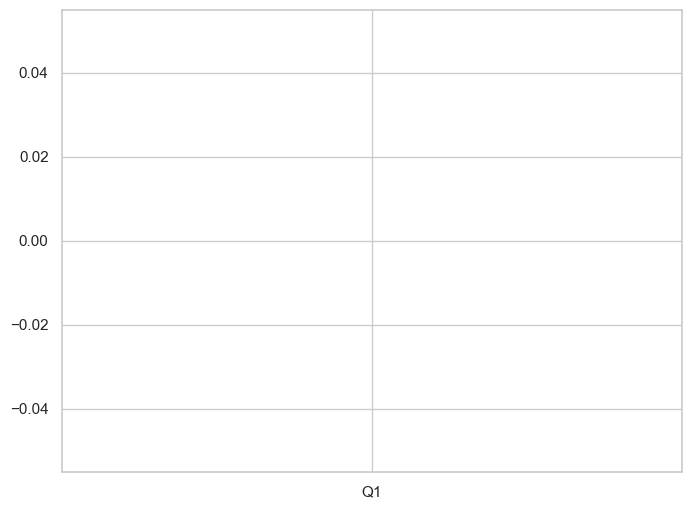

In [1]:
import pandas as pd
import numpy as np
from tableone import TableOne
import pingouin as pg
import seaborn as sns
import colorlog
import logging
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.api import het_breuschpagan
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import binomtest, mannwhitneyu
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from sklearn.cluster import KMeans

# Constants
RAW_MERGE_FILE = "24EI+03TS-raw-merge.xlsx"
FEATURES_FILE = "features_24EI_compiled.csv"
PATIENT_ID_PREFIX = "24EI-"
PLOTS_DIR = Path("plots")
SUMMARY_DIR = Path("summaries")
CLINICAL_COLUMNS = [
    'USUBJID', 'AGE', 'SEX', 'OUTCOME',
    'Adrenaline/Urine (µg/24h)', 'Noradrenaline/Urine (µg/24h)', 'Dopamine/Urine (µg/24h)',
    'ANSD d1', 'ANSD d5', 'ANSD'
]
HRV_COLUMNS = [
    'patient_id', 'date', 'sdnn', 'rmssd', 'nn50', 'pnn50',
    'hrv_triangular_index', 'lf_power', 'hf_power', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_area', 'diastolic_area',
    'systolic_slope', 'diastolic_slope', 'signal_skewness', 'peak_trend_slope',
    'systolic_amplitude_variability', 'diastolic_amplitude_variability', 'dfa'
]
CATECHOLAMINE_RENAME = {
    'Adrenaline/Urine (µg/24h)': 'Adrenalin',
    'Noradrenaline/Urine (µg/24h)': 'Noradrenalin',
    'Dopamine/Urine (µg/24h)': 'Dopamin'
}
PPG_FEATURES = [
    'sdnn', 'rmssd', 'poincare_sd1', 'poincare_sd2',
    'systolic_duration', 'diastolic_duration', 'systolic_slope', 'diastolic_slope',
    'heart_rate', 'sample_entropy', 'nn50', 'pnn50',
    'hrv_triangular_index', 'lf_power', 'hf_power',
    'signal_skewness', 'peak_trend_slope', 'systolic_area', 'diastolic_area',
    'systolic_amplitude_variability', 'diastolic_amplitude_variability'
]

# Setup colored logging
def setup_logging() -> logging.Logger:
    """Configure colored logging with custom formatting."""
    handler = colorlog.StreamHandler()
    handler.setFormatter(
        colorlog.ColoredFormatter(
            '%(log_color)s%(levelname)s: %(message)s',
            log_colors={
                'DEBUG': 'cyan',
                'INFO': 'green',
                'WARNING': 'yellow',
                'ERROR': 'red',
                'CRITICAL': 'red,bg_white',
            }
        )
    )
    logger = colorlog.getLogger()
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)
    return logger

logger = setup_logging()

# Load and validate data
def load_data(file_path: str, file_type: str = 'excel') -> pd.DataFrame:
    """
    Load data from Excel or CSV file with error handling.
    
    Args:
        file_path: Path to the file.
        file_type: 'excel' or 'csv'.
    
    Returns:
        Loaded DataFrame.
    
    Raises:
        FileNotFoundError: If file is not found.
        ValueError: If file type is invalid.
    """
    logger.info(f"Loading {file_type} file: {file_path}...")
    try:
        if file_type == 'excel':
            df = pd.read_excel(file_path)
        elif file_type == 'csv':
            df = pd.read_csv(file_path)
        else:
            raise ValueError(f"Unsupported file type: {file_type}")
        logger.debug(f"Loaded dataset with shape: {df.shape}")
        return df
    except FileNotFoundError:
        logger.error(f"File '{file_path}' not found. Please check the path.")
        raise

def validate_columns(df: pd.DataFrame, required_columns: List[str]) -> None:
    """
    Validate that required columns exist in the DataFrame.
    
    Args:
        df: DataFrame to validate.
        required_columns: List of required column names.
    
    Raises:
        ValueError: If any required columns are missing.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        logger.error(f"Missing columns: {missing}")
        raise ValueError(f"Missing columns: {missing}")

def preprocess_clinical_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess clinical data: select columns, filter, mutate, and rename.
    
    Args:
        df: Raw clinical DataFrame.
    
    Returns:
        Preprocessed DataFrame with renamed columns and patient_id.
    """
    logger.info("Preprocessing clinical data...")
    
    # Select columns
    validate_columns(df, CLINICAL_COLUMNS)
    clinical = df[CLINICAL_COLUMNS].copy()
    logger.debug(f"Selected columns, shape: {clinical.shape}")
    
    # Filter out NA in Adrenaline
    clinical = clinical.dropna(subset=['Adrenaline/Urine (µg/24h)'])
    logger.debug(f"After filtering NA, shape: {clinical.shape}")
    
    # Mutate ANSD columns
    clinical['ANSD d1'] = clinical['ANSD d1'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    clinical['ANSD d5'] = clinical['ANSD d5'].apply(lambda x: 'Yes_ANSD' if x == 1 else 'No_ANSD')
    logger.debug("ANSD columns mutated.")
    
    # Rename catecholamine columns
    clinical = clinical.rename(columns=CATECHOLAMINE_RENAME)
    logger.debug("Catecholamine columns renamed.")
    
    # Rename USUBJID to patient_id and add prefix
    clinical = clinical.rename(columns={'USUBJID': 'patient_id'})
    clinical['patient_id'] = PATIENT_ID_PREFIX + clinical['patient_id'].astype(str)
    logger.debug("Patient_id renamed and prefixed.")
    
    return clinical

def generate_summary_table(df: pd.DataFrame, columns: List[str], groupby: str) -> pd.DataFrame:
    """
    Generate a summary table using TableOne with standardized mean differences, enhanced with Day 1, Day 5, change, and overall stats.
    
    Args:
        df: DataFrame to summarize (merged data with DayLabel for overall stats).
        columns: Columns to include in the summary.
        groupby: Column to group by.
    
    Returns:
        DataFrame with detailed summary statistics.
    """
    logger.info(f"Generating summary table for {columns} by {groupby} with Day 1, Day 5, and overall stats...")
    
    # Split data into Day 1 and Day 5
    day1_data = df[df['DayLabel'] == 'Day1'].copy()
    day5_data = df[df['DayLabel'] == 'Day5'].copy()
    
    # Generate TableOne summaries for Day 1 and Day 5
    table_day1 = TableOne(
        day1_data,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True,
        smd=True
    )
    table_day5 = TableOne(
        day5_data,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True,
        smd=True
    )
    
    # Overall summary
    table_overall = TableOne(
        df,
        columns=columns,
        groupby=groupby,
        pval=True,
        missing=True,
        decimals=2,
        htest_name=True,
        smd=True
    )
    
    # Convert to DataFrames
    df_day1 = table_day1.tableone.reset_index().rename(columns={'level_0': 'Feature', 'level_1': 'Statistic'})
    df_day5 = table_day5.tableone.reset_index().rename(columns={'level_0': 'Feature', 'level_1': 'Statistic'})
    df_overall = table_overall.tableone.reset_index().rename(columns={'level_0': 'Feature', 'level_1': 'Statistic'})
    
    # Add Day identifier as multi-index column
    df_day1[('Day', '')] = 'Day1'
    df_day5[('Day', '')] = 'Day5'
    df_overall[('Day', '')] = 'Overall'
    
    # Calculate change (Day 5 - Day 1) for mean and median
    change_data = []
    for feature in columns:
        row_mean = {('Feature', ''): feature, ('Statistic', ''): 'Mean Change (Day5 - Day1)', ('Day', ''): 'Change'}
        row_median = {('Feature', ''): feature, ('Statistic', ''): 'Median Change (Day5 - Day1)', ('Day', ''): 'Change'}
        for group in df[groupby].unique():
            day1_mean = day1_data[day1_data[groupby] == group][feature].mean()
            day5_mean = day5_data[day5_data[groupby] == group][feature].mean()
            change_mean = day5_mean - day1_mean
            row_mean[('Grouped by ANSD', str(group))] = f"{change_mean:.2f}" if not np.isnan(change_mean) else 'NA'
            
            day1_median = day1_data[day1_data[groupby] == group][feature].median()
            day5_median = day5_data[day5_data[groupby] == group][feature].median()
            change_median = day5_median - day1_median
            row_median[('Grouped by ANSD', str(group))] = f"{change_median:.2f}" if not np.isnan(change_median) else 'NA'
        
        change_data.append(row_mean)
        change_data.append(row_median)
    
    df_change = pd.DataFrame(change_data)
    
    # Combine all summaries
    summary_df = pd.concat([df_day1, df_day5, df_change, df_overall], ignore_index=True)
    
    # Save to CSV
    summary_path = SUMMARY_DIR / "catecholamine_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    logger.info(f"Saved detailed catecholamine summary to {summary_path}")
    
    return summary_df

def merge_with_features(clinical: pd.DataFrame, features_file: str) -> pd.DataFrame:
    """
    Merge clinical data with features data on patient_id, ensuring patients have exactly two rows in features data.
    
    Args:
        clinical: Preprocessed clinical DataFrame.
        features_file: Path to features CSV file.
    
    Returns:
        Merged DataFrame with only patients having exactly two rows in features data.
    
    Raises:
        ValueError: If merge results in an empty DataFrame.
    """
    # Load features data
    features = load_data(features_file, file_type='csv')
    
    # Filter patients with exactly 2 rows in features data
    logger.info("Filtering patients with exactly 2 rows in features data...")
    patient_counts = features.groupby('patient_id').size()
    valid_patients = patient_counts[patient_counts == 2].index
    features_filtered = features[features['patient_id'].isin(valid_patients)]
    
    logger.debug(f"Total patients in features data: {len(patient_counts)}")
    logger.debug(f"Patients with exactly 2 rows: {len(valid_patients)}")
    logger.debug(f"Features data shape after filtering: {features_filtered.shape}")
    
    if features_filtered.empty:
        logger.error("No patients with exactly 2 rows found in features data.")
        raise ValueError("No patients with exactly 2 rows found in features data.")
    
    # Merge with clinical data
    logger.info("Merging clinical and filtered features data...")
    merged = pd.merge(
        clinical,
        features_filtered,
        left_on='patient_id',
        right_on='patient_id',
        how='inner'
    )
    logger.debug(f"After merging, shape: {merged.shape}")
    logger.info(f"Unique patients after merge: {merged['patient_id'].nunique()}")
    
    if merged.empty:
        logger.error("Merge resulted in an empty DataFrame. Check patient_id values.")
        raise ValueError("Merge resulted in an empty DataFrame.")
    
    return merged

def process_hrv_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Process HRV data: filter, select columns, assign Day1/Day5 labels, and pivot.
    
    Args:
        df: Merged DataFrame.
    
    Returns:
        Pivoted DataFrame with Day1 and Day5 columns, and long format DataFrame before pivoting.
    """
    logger.info("Processing HRV data...")
    
    # Filter patients with exactly 2 records
    hrv = df.groupby('patient_id').filter(lambda x: len(x) == 2)
    logger.debug(f"After filtering 2 records, shape: {hrv.shape}")
    
    # Select HRV columns
    available_hrv_columns = [col for col in HRV_COLUMNS if col in hrv.columns]
    if len(available_hrv_columns) < len(HRV_COLUMNS):
        logger.warning(f"Missing HRV columns: {[col for col in HRV_COLUMNS if col not in hrv.columns]}")
    hrv = hrv[available_hrv_columns].copy()
    logger.debug(f"HRV columns selected, shape: {hrv.shape}")
    
    # Convert date to datetime
    if 'date' not in hrv.columns:
        logger.error("Column 'date' not found.")
        raise ValueError("Column 'date' not found.")
    hrv['Date'] = pd.to_datetime(hrv['date'], errors='coerce')
    if hrv['Date'].isna().all():
        logger.error("All Date values are invalid or missing.")
        raise ValueError("All Date values are invalid or missing.")
    logger.debug(f"Date NAs: {hrv['Date'].isna().sum()}")
    
    # Assign Day1 and Day5 labels
    hrv = hrv.sort_values(['patient_id', 'Date'])
    hrv['DayLabel'] = hrv.groupby('patient_id')['Date'].transform(
        lambda x: np.where(x == x.min(), 'Day1', np.where(x == x.max(), 'Day5', np.nan))
    )
    hrv = hrv.dropna(subset=['DayLabel']).reset_index(drop=True)
    logger.debug(f"After labeling, shape: {hrv.shape}")
    
    # Save long format for plotting
    hrv_long = hrv.copy()
    
    # Pivot to wide format
    pivot_columns = [col for col in hrv.columns if col not in ['patient_id', 'Date', 'DayLabel', 'date']]
    hrv_wide = hrv.pivot(
        index='patient_id',
        columns='DayLabel',
        values=pivot_columns
    )
    hrv_wide.columns = [f"{col[0]}_{col[1]}" for col in hrv_wide.columns]
    hrv_wide = hrv_wide.reset_index()
    logger.debug(f"Pivoted shape: {hrv_wide.shape}")
    
    return hrv_wide, hrv_long

def summarize_features(df: pd.DataFrame, merged_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize features with medians, IQRs, and statistical tests for Day1 vs Day5.
    Includes paired t-test or Wilcoxon based on normality, sign test, means, changes, multiple tests, and overall stats.
    
    Args:
        df: Pivoted HRV DataFrame with Day1 and Day5 columns.
        merged_df: Merged DataFrame with DayLabel for overall stats.
    
    Returns:
        Summary DataFrame with statistics, including p-values and effect sizes.
    """
    logger.info("Summarizing features...")
    features = [col for col in df.columns if col != 'patient_id' and not col.lower().startswith('date')]
    base_features = list(set([col.replace('_Day1', '').replace('_Day5', '') for col in features]))
    
    def summarize_single_feature(feature: str) -> pd.Series:
        logger.info(f"Summarizing feature: {feature}")
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        
        # Ensure paired data
        paired = df[['patient_id', day1_col, day5_col]].dropna()
        logger.debug(f"Paired DataFrame shape for {feature}: {paired.shape}")
        
        # Extract as Series
        day1 = paired[day1_col]
        day5 = paired[day5_col]
        
        # Overall data from merged_df
        overall_data = merged_df[feature].dropna()
        
        # Validate sample size and data
        n_samples = len(paired)
        logger.debug(f"Paired samples for {feature}: {n_samples}")
        if n_samples < 2 or not (pd.api.types.is_numeric_dtype(day1) and pd.api.types.is_numeric_dtype(day5)):
            logger.warning(f"Insufficient or non-numeric data ({n_samples} samples) for {feature}. Skipping tests.")
            return pd.Series({
                'Feature': feature,
                'Day1_Median_IQR': 'NA',
                'Day1_Mean_SD': 'NA',
                'Day5_Median_IQR': 'NA',
                'Day5_Mean_SD': 'NA',
                'Median_Change_Pct': 'NA',
                'Mean_Change_Pct': 'NA',
                'Overall_Median_IQR': 'NA',
                'Overall_Mean_SD': 'NA',
                'Wilcoxon_P': 'NA',
                'TTest_P': 'NA',
                'SignTest_P': 'NA',
                'Cohens_d': 'NA',
                'P_value': 'NA',
                'Test': 'None',
                'Effect_size': 'NA',
                'Sign_test_p': 'NA',
                'Sign_test_es': 'NA'
            })
        
        # Calculate medians, IQRs, means, and SDs
        med1 = np.median(day1)
        q1_1, q3_1 = np.percentile(day1, [25, 75])
        mean1 = np.mean(day1)
        sd1 = np.std(day1)
        
        med5 = np.median(day5)
        q1_5, q3_5 = np.percentile(day5, [25, 75])
        mean5 = np.mean(day5)
        sd5 = np.std(day5)
        
        # Overall stats
        med_overall = np.median(overall_data)
        q1_overall, q3_overall = np.percentile(overall_data, [25, 75])
        mean_overall = np.mean(overall_data)
        sd_overall = np.std(overall_data)
        
        # Calculate changes
        median_change_pct = ((med5 - med1) / med1 * 100) if med1 != 0 else np.nan
        mean_change_pct = ((mean5 - mean1) / mean1 * 100) if mean1 != 0 else np.nan
        
        # Initialize outputs
        p = np.nan
        es = np.nan
        test = 'None'
        sign_p = np.nan
        sign_es = np.nan
        wilcoxon_p = np.nan
        ttest_p = np.nan
        cohens_d = np.nan
        
        if n_samples >= 2:
            diff = day1 - day5
            norm_res = pg.normality(diff)
            norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
            
            try:
                if norm_p > 0.05:
                    # Paired t-test for normally distributed differences
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n_samples)  # Cohen's d
                    test = 't-test'
                    ttest_p = p
                else:
                    # Wilcoxon test for non-normal differences
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['CLES'].iloc[0] if 'CLES' in w_res.columns else w_res['RBC'].iloc[0]
                    test = 'Wilcoxon'
                    wilcoxon_p = p
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
                test = 'Failed'
            
            # Sign test
            try:
                # Count positive and negative differences (exclude zeros)
                non_zero_diff = diff[diff != 0]
                if len(non_zero_diff) > 0:
                    n_positive = np.sum(non_zero_diff > 0)
                    n_total = len(non_zero_diff)
                    # Perform sign test using binomtest
                    sign_result = binomtest(n_positive, n_total, p=0.5, alternative='two-sided')
                    sign_p = sign_result.pvalue
                    sign_es = n_positive / n_total if n_total > 0 else np.nan  # Proportion of positive differences
                else:
                    logger.warning(f"No non-zero differences for sign test in {feature}")
            except Exception as e:
                logger.warning(f"Sign test failed for {feature}: {e}")
            
            # Cohen's d
            try:
                cohens_d = pg.compute_effsize(day1, day5, paired=True, eftype='cohen')
            except Exception as e:
                logger.warning(f"Cohen's d failed for {feature}: {str(e)}")
        
        # Format p-values and effect sizes
        p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
        es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
        sign_p_str = '<0.001' if sign_p < 0.001 else f"{sign_p:.3f}" if not np.isnan(sign_p) else 'NA'
        sign_es_str = f"{sign_es:.2f}" if not np.isnan(sign_es) else 'NA'
        
        return pd.Series({
            'Feature': feature,
            'Day1_Median_IQR': f"{med1:.1f} ({q1_1:.1f}–{q3_1:.1f})" if not day1.empty else 'NA',
            'Day1_Mean_SD': f"{mean1:.1f} ± {sd1:.1f}" if not day1.empty else 'NA',
            'Day5_Median_IQR': f"{med5:.1f} ({q1_5:.1f}–{q3_5:.1f})" if not day5.empty else 'NA',
            'Day5_Mean_SD': f"{mean5:.1f} ± {sd5:.1f}" if not day5.empty else 'NA',
            'Median_Change_Pct': f"{median_change_pct:.1f}%" if not np.isnan(median_change_pct) else 'NA',
            'Mean_Change_Pct': f"{mean_change_pct:.1f}%" if not np.isnan(mean_change_pct) else 'NA',
            'Overall_Median_IQR': f"{med_overall:.1f} ({q1_overall:.1f}–{q3_overall:.1f})" if not overall_data.empty else 'NA',
            'Overall_Mean_SD': f"{mean_overall:.1f} ± {sd_overall:.1f}" if not overall_data.empty else 'NA',
            'P_value': p_str,
            'Test': test,
            'Effect_size': es_str,
            'Sign_test_p': sign_p_str,
            'Sign_test_es': sign_es_str,
            'Wilcoxon_P': f"{wilcoxon_p:.3f}" if not np.isnan(wilcoxon_p) else 'NA',
            'TTest_P': f"{ttest_p:.3f}" if not np.isnan(ttest_p) else 'NA',
            'SignTest_P': f"{sign_p:.3f}" if not np.isnan(sign_p) else 'NA',
            'Cohens_d': f"{cohens_d:.3f}" if not np.isnan(cohens_d) else 'NA'
        })
    
    summary = pd.DataFrame([summarize_single_feature(f) for f in base_features])
    logger.debug("Summary table generated.")
    summary_path = SUMMARY_DIR / "feature_summary.csv"
    summary.to_csv(summary_path, index=False)
    return summary

def detect_outliers(df: pd.DataFrame, y_col: str, day: str, x_col: str = 'Adrenalin', clinical_cols: List[str] = ['ANSD', 'OUTCOME']) -> pd.DataFrame:
    """
    Detect outliers using IQR method for a PPG feature on a specific day with detailed explanation.
    
    Args:
        df: DataFrame with data for a specific day.
        y_col: PPG feature column name.
        day: 'Day1' or 'Day5'.
        x_col: X-axis column name (default: 'Adrenalin').
        clinical_cols: Clinical columns to include for context.
    
    Returns:
        DataFrame of outliers with explanations.
    """
    clinical_cols = [x_col] + clinical_cols
    logger.info(f"Detecting outliers for {y_col} on {day}...")
    cols = [y_col, 'patient_id'] + [col for col in clinical_cols if col in df.columns]
    if x_col not in cols:
        logger.warning(f"'{x_col}' not in columns for {y_col}. Available columns: {df.columns.tolist()}")
        cols.append(x_col) if x_col in df.columns else logger.error(f"'{x_col}' missing from DataFrame.")
    
    df_clean = df[cols].dropna(subset=[y_col])
    
    # Validate data size
    if len(df_clean) < 4:
        logger.warning(f"Too few data points ({len(df_clean)}) for {y_col} on {day}. Skipping outlier detection.")
        return pd.DataFrame(columns=cols + ['Day', 'Plot', 'Deviation', 'Explanation'])
    
    logger.debug(f"Valid data points for {y_col} on {day}: {len(df_clean)}, values: {df_clean[y_col].tolist()}")
    
    def get_outlier_indices(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return (series < lower) | (series > upper)
    
    # Apply IQR to the entire Series
    outlier_mask = get_outlier_indices(df_clean[y_col])
    outliers = df_clean[outlier_mask].copy()
    
    if not outliers.empty:
        outliers['Day'] = day
        outliers['Plot'] = y_col
        median = df_clean[y_col].median()
        std = df_clean[y_col].std()
        outliers['Deviation'] = outliers[y_col].apply(
            lambda x: (x - median) / std if std != 0 else np.nan
        )
        outliers['Explanation'] = outliers.apply(
            lambda row: (
                f"Value {row[y_col]:.2f} on {day} is {row['Deviation']:.2f} SD from median "
                f"(median={median:.2f}, IQR=[{df_clean[y_col].quantile(0.25):.2f}, "
                f"{df_clean[y_col].quantile(0.75):.2f}]). "
                f"{x_col}={row.get(x_col, 'NA'):.2f}, "
                f"Patient ANSD={row.get('ANSD', 'NA')}, OUTCOME={row.get('OUTCOME', 'NA')}."
            ),
            axis=1
        )
    
    logger.debug(f"Found {len(outliers)} outliers for {y_col} on {day}.")
    return outliers

def plot_ppg_features(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Plot PPG features vs catecholamine (Adrenalin or Noradrenalin) for Day 1 and Day 5 separately, with dots colored by ANSD status.
    Detect outliers, annotate them with patient_id, include outliers in plots and regression, perform model checking with advanced diagnostics,
    and save in feature-specific folders. Scatter points are colored by ANSD (red for Yes_ANSD, blue for No_ANSD).
    
    Args:
        df: DataFrame with data (must include 'DayLabel', 'ANSD d1', 'ANSD d5').
        features: List of PPG feature column names.
        x_col: X-axis column name (default: 'Adrenalin').
        base_output_dir: Base directory to save plots.
    
    Returns:
        DataFrame of all outliers across plots with enhanced details.
    """
    logger.info(f"Creating PPG feature plots vs {x_col} and detecting outliers for Day 1 and Day 5...")
    all_outliers = []
    
    sns.set_theme(style="whitegrid", palette="muted")
    
    # Validate required columns
    required_cols = [x_col, 'DayLabel', 'ANSD d1', 'ANSD d5', 'patient_id']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        logger.error(f"Missing required columns in df: {missing_cols}. Available columns: {df.columns.tolist()}")
        raise KeyError(f"Missing required columns in df: {missing_cols}")
    
    # Split data into Day 1 and Day 5
    day1_data = df[df['DayLabel'] == 'Day1'].copy()
    day5_data = df[df['DayLabel'] == 'Day5'].copy()
    
    logger.debug(f"Day 1 data shape: {day1_data.shape}, columns: {day1_data.columns.tolist()}")
    logger.debug(f"Day 5 data shape: {day5_data.shape}, columns: {day5_data.columns.tolist()}")
    
    if day1_data.empty or day5_data.empty:
        logger.error("No data available for Day 1 or Day 5 after splitting.")
        raise ValueError("No data available for Day 1 or Day 5 after splitting.")
    
    # Map ANSD status to the respective day
    day1_data['ANSD_status'] = day1_data['ANSD d1']
    day5_data['ANSD_status'] = day5_data['ANSD d5']
    
    # For outlier enhancement: create feature_changes with explicit patient_id column
    logger.info("Creating feature_changes DataFrame...")
    feature_changes = df.pivot(index='patient_id', columns='DayLabel', values=features)
    feature_changes.columns = [f"{col[0]}_{col[1]}" for col in feature_changes.columns]
    # Reset index and ensure patient_id is a column
    feature_changes = feature_changes.reset_index()
    logger.debug(f"feature_changes columns after pivot and reset: {feature_changes.columns.tolist()}")
    if 'patient_id' not in feature_changes.columns:
        logger.error("patient_id column missing in feature_changes after reset_index.")
        raise KeyError("patient_id column missing in feature_changes after reset_index.")
    
    # Ensure patient_id is a string and check for invalid values
    feature_changes['patient_id'] = feature_changes['patient_id'].astype(str)
    if feature_changes['patient_id'].isna().any() or (feature_changes['patient_id'] == '').any():
        logger.error("Invalid values (NaN or empty) found in feature_changes['patient_id'].")
        raise ValueError("Invalid values (NaN or empty) found in feature_changes['patient_id'].")
    logger.debug(f"feature_changes patient_id dtype: {feature_changes['patient_id'].dtype}")
    logger.debug(f"feature_changes patient_id sample: {feature_changes['patient_id'].head().tolist()}")
    
    for feature in features:
        feature_dir = base_output_dir / feature / x_col.lower()
        feature_dir.mkdir(parents=True, exist_ok=True)
        
        if feature not in df.columns or x_col not in df.columns:
            logger.warning(f"Skipping plot for {feature} vs {x_col}: column missing.")
            continue
        
        # Detect outliers for each day
        outliers_day1 = detect_outliers(day1_data, feature, 'Day1', x_col=x_col)
        outliers_day5 = detect_outliers(day5_data, feature, 'Day5', x_col=x_col)
        
        # Enhance outliers with Day 1, Day 5 values, and change
        if not outliers_day1.empty:
            logger.debug(f"Before merge for {feature} Day 1 - outliers_day1 columns: {outliers_day1.columns.tolist()}")
            logger.debug(f"Before merge for {feature} Day 1 - feature_changes columns: {feature_changes.columns.tolist()}")
            logger.debug(f"Before merge for {feature} Day 1 - outliers_day1 patient_id dtype: {outliers_day1['patient_id'].dtype}")
            logger.debug(f"Before merge for {feature} Day 1 - feature_changes patient_id dtype: {feature_changes['patient_id'].dtype}")
            logger.debug(f"Before merge for {feature} Day 1 - outliers_day1 patient_id sample: {outliers_day1['patient_id'].head().tolist()}")
            logger.debug(f"Before merge for {feature} Day 1 - feature_changes patient_id sample: {feature_changes['patient_id'].head().tolist()}")
            logger.debug(f"Merging columns: {f'{feature}_Day1'}, {f'{feature}_Day5'}")
            
            if 'patient_id' not in outliers_day1.columns:
                logger.error(f"patient_id column missing in outliers_day1 for feature {feature}.")
                raise KeyError(f"patient_id column missing in outliers_day1 for feature {feature}.")
            if 'patient_id' not in feature_changes.columns:
                logger.error(f"patient_id column missing in feature_changes for feature {feature}.")
                raise KeyError(f"patient_id column missing in feature_changes for feature {feature}.")
            
            # Ensure patient_id is a string in outliers_day1
            outliers_day1['patient_id'] = outliers_day1['patient_id'].astype(str)
            
            # Check for invalid patient_id values
            if outliers_day1['patient_id'].isna().any() or (outliers_day1['patient_id'] == '').any():
                logger.error(f"Invalid values (NaN or empty) found in outliers_day1['patient_id'] for feature {feature}.")
                raise ValueError(f"Invalid values (NaN or empty) found in outliers_day1['patient_id'] for feature {feature}.")
            
            # Ensure merge columns exist in feature_changes
            merge_cols = [f"{feature}_Day1", f"{feature}_Day5"]
            missing_merge_cols = [col for col in merge_cols if col not in feature_changes.columns]
            if missing_merge_cols:
                logger.error(f"Missing merge columns in feature_changes: {missing_merge_cols}")
                raise KeyError(f"Missing merge columns in feature_changes: {missing_merge_cols}")
            
            # Attempt merge, with fallback if it fails
            try:
                outliers_day1 = outliers_day1.merge(
                    feature_changes[['patient_id'] + merge_cols],
                    on='patient_id',
                    how='left'
                )
            except KeyError as e:
                logger.error(f"Merge failed for {feature} Day 1: {str(e)}. Attempting fallback merge strategy...")
                # Fallback: Set patient_id as index and join
                try:
                    outliers_day1 = outliers_day1.set_index('patient_id')
                    feature_subset = feature_changes.set_index('patient_id')[merge_cols]
                    outliers_day1 = outliers_day1.join(feature_subset, how='left')
                    outliers_day1 = outliers_day1.reset_index()
                    logger.info(f"Fallback merge succeeded for {feature} Day 1.")
                except Exception as e2:
                    logger.error(f"Fallback merge also failed for {feature} Day 1: {str(e2)}")
                    # Save DataFrames for manual inspection
                    outliers_day1.to_csv(feature_dir / f"outliers_{x_col}_day1_{feature}_failed.csv", index=True)
                    feature_changes.to_csv(feature_dir / f"feature_changes_{feature}_failed.csv", index=False)
                    raise
            
            outliers_day1[f"{feature}_Change_Pct"] = (
                (outliers_day1[f"{feature}_Day5"] - outliers_day1[f"{feature}_Day1"]) / 
                outliers_day1[f"{feature}_Day1"].replace(0, np.nan) * 100
            )
            all_outliers.append(outliers_day1)
        
        if not outliers_day5.empty:
            outliers_day5['patient_id'] = outliers_day5['patient_id'].astype(str)
            
            try:
                outliers_day5 = outliers_day5.merge(
                    feature_changes[['patient_id', f"{feature}_Day1", f"{feature}_Day5"]],
                    on='patient_id',
                    how='left'
                )
            except KeyError as e:
                logger.error(f"Merge failed for {feature} Day 5: {str(e)}. Attempting fallback merge strategy...")
                try:
                    outliers_day5 = outliers_day5.set_index('patient_id')
                    feature_subset = feature_changes.set_index('patient_id')[[f"{feature}_Day1", f"{feature}_Day5"]]
                    outliers_day5 = outliers_day5.join(feature_subset, how='left')
                    outliers_day5 = outliers_day5.reset_index()
                    logger.info(f"Fallback merge succeeded for {feature} Day 5.")
                except Exception as e2:
                    logger.error(f"Fallback merge also failed for {feature} Day 5: {str(e2)}")
                    raise
            
            outliers_day5[f"{feature}_Change_Pct"] = (
                (outliers_day5[f"{feature}_Day5"] - outliers_day5[f"{feature}_Day1"]) / 
                outliers_day5[f"{feature}_Day1"].replace(0, np.nan) * 100
            )
            all_outliers.append(outliers_day5)
        
        # Day 1 plot and diagnostics
        df_day1 = day1_data[[x_col, feature, 'patient_id', 'ANSD_status']].dropna()
        if len(df_day1) < 2:
            logger.warning(f"Too few points for {feature} vs {x_col} on Day1. Skipping plot.")
            continue
        
        # Ensure ANSD is properly formatted
        df_day1 = df_day1.copy()
        df_day1['ANSD_status'] = df_day1['ANSD_status'].apply(lambda x: 'Yes_ANSD' if x == 'Yes_ANSD' else 'No_ANSD' if x == 'No_ANSD' else np.nan)
        
        # Check for unexpected ANSD values
        unique_ansd = df_day1['ANSD_status'].dropna().unique()
        expected_ansd = {'Yes_ANSD', 'No_ANSD'}
        if not set(unique_ansd).issubset(expected_ansd):
            logger.warning(f"Unexpected ANSD values {set(unique_ansd) - expected_ansd} for {feature}. Skipping plot.")
            continue
        if df_day1['ANSD_status'].isna().all():
            logger.warning(f"All ANSD values are NA for {feature}. Skipping plot.")
            continue
        
        # Linear regression using statsmodels for diagnostics (include outliers)
        logger.info(f"Plotting {feature} vs {x_col} with linear regression for Day1...")
        model_day1 = smf.ols(f"{feature} ~ {x_col}", data=df_day1).fit()
        
        # Generate smooth curve for plotting with confidence interval
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=df_day1, x=x_col, y=feature, 
            hue='ANSD_status', palette={'Yes_ANSD': 'red', 'No_ANSD': 'blue'}, 
            s=50, alpha=0.8
        )
        sns.regplot(
            data=df_day1, x=x_col, y=feature, 
            scatter=False, 
            color='red', 
            line_kws={'lw': 2, 'label': 'Linear Fit', 'color': 'red'},
            ci=95,  # 95% confidence interval
            scatter_kws={'alpha': 0}  # Hide extra scatter points from regplot
        )
        # Add LOWESS trace for additional trend
        sns.regplot(
            data=df_day1, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1, 'label': 'LOWESS Trend'},
            ci=None
        )
        # if not outliers_day1.empty:
        #     for _, row in outliers_day1.iterrows():
        #         if x_col in row:
        #             plt.scatter(row[x_col], row[feature], color='orange', s=100, label='Outlier' if _ == 0 else None)
        #             plt.text(
        #                 row[x_col] + 0.5, row[feature] + 0.5,
        #                 row['patient_id'],
        #                 fontsize=8, color='black', ha='left', va='bottom'
        #             )
        plt.title(f"Day1: Linear Regression of {feature.upper()} vs {x_col}/Urine (µg/24h)", fontsize=14)
        plt.xlabel(f"{x_col}/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.legend(loc='best')
        
        # Save plot
        plot_path = feature_dir / f"{feature}_vs_{x_col.lower()}_day1_linear.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 linear regression plot to {plot_path}")
        
        # Description for linear regression plot
        desc_text = f"""Description of {feature}_vs_{x_col.lower()}_day1_linear.png:
This plot shows a linear regression of {feature.upper()} against {x_col}/Urine levels on Day1.
Scatter points are colored by ANSD: red for Yes_ANSD, blue for No_ANSD.
The red line is the linear fit, with a red shaded area indicating the 95% confidence interval.
A green LOWESS line is added as an additional trend trace.
Outliers are included and annotated with patient_id.
The shaded region shows the uncertainty of the regression line."""
        desc_path = feature_dir / f"{feature}_vs_{x_col.lower()}_day1_linear_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Model checking for Day1
        resid = model_day1.resid
        fitted = model_day1.fittedvalues
        influence = model_day1.get_influence()
        cooks_dist = influence.cooks_distance[0]
        
        # Heteroscedasticity test
        bp_test = het_breuschpagan(resid, model_day1.model.exog)
        bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = bp_test
        
        # Normality test on residuals
        norm_test = pg.normality(resid)
        norm_p = norm_test['pval'].iloc[0] if not norm_test.empty else np.nan
        
        # Interpretation
        interpretation = f"""Model Interpretation for {feature} (Linear OLS) on Day1:
R-squared: {model_day1.rsquared:.3f} - Explains {model_day1.rsquared*100:.1f}% of variance.
Coefficient for {x_col}: {model_day1.params[x_col]:.3f} (p={model_day1.pvalues[x_col]:.3f})
If p < 0.05, significant linear relationship.

Diagnostics:
Heteroscedasticity (Breusch-Pagan test): LM={bp_lm:.3f}, p={bp_lm_pvalue:.3f}
If p < 0.05, residuals have non-constant variance (heteroscedastic).
Normality of residuals (Shapiro-Wilk): p={norm_p:.3f}
If p < 0.05, residuals not normally distributed.
Outliers/Influence: Max Cook's distance {np.max(cooks_dist):.3f} (threshold ~1 or 4/n={4/len(df_day1):.3f})
"""
        summary_path = feature_dir / "model_summary_day1.txt"
        with open(summary_path, 'w') as f:
            f.write(model_day1.summary().as_text() + "\n\n" + interpretation)
        logger.debug(f"Saved Day1 model summary to {summary_path}")
        
        # Residuals vs Fitted with color based on residual magnitude
        resid_std = np.std(resid)
        colors = ['green' if abs(r) < resid_std else 'orange' if abs(r) < 2*resid_std else 'red' for r in resid]
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=fitted, y=resid, c=colors, alpha=0.8, s=60)
        sns.regplot(x=fitted, y=resid, lowess=True, scatter=False, line_kws={'color': 'blue', 'lw': 1}, ci=None)
        plt.axhline(0, color='red', ls='--', lw=2)
        plt.title(f'Residuals vs Fitted for {feature.upper()} on Day1\n(Green: <1SD, Orange: 1-2SD, Red: >2SD)', fontsize=14)
        plt.xlabel('Fitted Values (Linear OLS)', fontsize=12)
        plt.ylabel('Residuals', fontsize=12)
        
        # Add legend for blue line
        legend_elements = [mpatches.Patch(color='blue', label='LOWESS trend (detects residual patterns like curvature or spread)')]
        plt.legend(handles=legend_elements, loc='best', fontsize=10)
        
        resid_path = feature_dir / "residuals_day1.png"
        plt.savefig(resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 residuals plot to {resid_path}")
        
        # Description for residuals plot
        desc_text = f"""Description of residuals_day1.png:
This plot shows residuals (prediction errors) against fitted values for {feature} using linear OLS on Day1.
Green points: residuals within 1 SD.
Orange points: residuals between 1-2 SD.
Red points: residuals beyond 2 SD (potential outliers).
The blue LOWESS trend line highlights patterns like curvature (non-linearity) or changing spread (heteroscedasticity).
Ideal: random scatter around zero with a flat blue line, indicating no systematic errors."""
        desc_path = feature_dir / "residuals_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # QQ Plot with enhanced visualization
        plt.figure(figsize=(6, 6))
        qqplot(resid, line='s', ax=plt.gca(), marker='o', markerfacecolor='blue', markeredgecolor='darkblue', alpha=0.7)
        plt.title(f'QQ Plot for {feature.upper()} Residuals (Linear OLS) on Day1', fontsize=14)
        plt.xlabel('Theoretical Quantiles', fontsize=12)
        plt.ylabel('Sample Quantiles', fontsize=12)
        qq_path = feature_dir / "qq_day1.png"
        plt.savefig(qq_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 QQ plot to {qq_path}")
        
        # Description for QQ plot
        desc_text = f"""Description of qq_day1.png:
This QQ plot compares residuals of {feature} (from linear OLS) to a normal distribution on Day1.
Blue points represent sample quantiles vs theoretical normal quantiles.
Points along the red line indicate normality.
Deviations at ends suggest skewness or heavy tails in residuals."""
        desc_path = feature_dir / "qq_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Leverage plot with colors
        fig, ax = plt.subplots(figsize=(8, 6))
        sm.graphics.influence_plot(model_day1, criterion="cooks", ax=ax)
        ax.set_title(f'Influence Plot for {feature.upper()} (Linear OLS) on Day1', fontsize=14)
        leverage_path = feature_dir / "leverage_day1.png"
        fig.savefig(leverage_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 leverage plot to {leverage_path}")
        
        # Description for leverage plot
        desc_text = f"""Description of leverage_day1.png:
This influence plot shows leverage (x-axis) vs studentized residuals (y-axis) for {feature} (linear OLS) on Day1.
Point size reflects Cook's distance, indicating influence.
Large or distant points are potentially influential outliers."""
        desc_path = feature_dir / "leverage_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Residual histogram
        plt.figure(figsize=(6, 4))
        sns.histplot(resid, kde=True, color='purple', bins=10)
        plt.title(f'Residual Histogram for {feature.upper()} (Linear OLS) on Day1', fontsize=14)
        plt.xlabel('Residuals', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        hist_resid_path = feature_dir / "residual_histogram_day1.png"
        plt.savefig(hist_resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 residual histogram to {hist_resid_path}")
        
        # Description for residual histogram
        desc_text = f"""Description of residual_histogram_day1.png:
This histogram with KDE shows the distribution of residuals for {feature} (linear OLS) on Day1.
A normal distribution centered at zero supports OLS assumptions.
Skewness or multimodality may indicate model issues."""
        desc_path = feature_dir / "residual_histogram_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Jointplot for bivariate distribution with hue
        joint_g = sns.jointplot(
            data=df_day1, x=x_col, y=feature, kind='scatter', 
            hue='ANSD_status', palette={'Yes_ANSD': 'red', 'No_ANSD': 'blue'}, 
            marginal_kws={'fill': True}
        )
        sns.regplot(
            data=df_day1, x=x_col, y=feature, 
            scatter=False, color='red', line_kws={'lw': 2}, ci=95, ax=joint_g.ax_joint
        )
        sns.regplot(
            data=df_day1, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1}, ci=None, ax=joint_g.ax_joint
        )
        joint_g.set_axis_labels(f"{x_col}/Urine (µg/24h)", feature.upper(), fontsize=12)
        joint_g.fig.suptitle(f'Joint Plot of {feature.upper()} vs {x_col} on Day1', y=1.02, fontsize=14)
        joint_path = feature_dir / "joint_plot_day1.png"
        joint_g.savefig(joint_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 joint plot to {joint_path}")
        
        # Description for joint plot
        desc_text = f"""Description of joint_plot_day1.png:
This joint plot shows the scatter of {feature.upper()} vs {x_col} colored by ANSD: red for Yes_ANSD, blue for No_ANSD on Day1.
Marginal histograms with KDE show variable distributions, colored by ANSD.
The red regression line indicates the strength and direction of the relationship, with red CI shade.
A green LOWESS line is added as an additional trend trace."""
        desc_path = feature_dir / "joint_plot_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Hexbin plot for density visualization
        plt.figure(figsize=(8, 6))
        plt.hexbin(df_day1[x_col], df_day1[feature], gridsize=30, cmap='Blues', mincnt=1)
        plt.colorbar(label='Count')
        plt.title(f'Hexbin Plot of {feature.upper()} vs {x_col} on Day1', fontsize=14)
        plt.xlabel(f"{x_col}/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        hexbin_path = feature_dir / "hexbin_plot_day1.png"
        plt.savefig(hexbin_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day1 hexbin plot to {hexbin_path}")
        
        # Description for hexbin plot
        desc_text = f"""Description of hexbin_plot_day1.png:
This hexbin plot visualizes the density of {feature.upper()} vs {x_col} data points on Day1.
Darker hexagons indicate higher point density.
Useful for identifying clusters or patterns in dense datasets."""
        desc_path = feature_dir / "hexbin_plot_day1_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Repeat for Day5
        df_day5 = day5_data[[x_col, feature, 'patient_id', 'ANSD_status']].dropna()
        if len(df_day5) < 2:
            logger.warning(f"Too few points for {feature} vs {x_col} on Day5. Skipping plot.")
            continue
        
        df_day5 = df_day5.copy()
        df_day5['ANSD_status'] = df_day5['ANSD_status'].apply(lambda x: 'Yes_ANSD' if x == 'Yes_ANSD' else 'No_ANSD' if x == 'No_ANSD' else np.nan)
        
        unique_ansd = df_day5['ANSD_status'].dropna().unique()
        if not set(unique_ansd).issubset(expected_ansd):
            logger.warning(f"Unexpected ANSD values {set(unique_ansd) - expected_ansd} for {feature}. Skipping plot.")
            continue
        if df_day5['ANSD_status'].isna().all():
            logger.warning(f"All ANSD values are NA for {feature}. Skipping plot.")
            continue
        
        model_day5 = smf.ols(f"{feature} ~ {x_col}", data=df_day5).fit()
        
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=df_day5, x=x_col, y=feature, 
            hue='ANSD_status', palette={'Yes_ANSD': 'red', 'No_ANSD': 'blue'}, 
            s=50, alpha=0.8
        )
        sns.regplot(
            data=df_day5, x=x_col, y=feature, 
            scatter=False, 
            color='red', 
            line_kws={'lw': 2, 'label': 'Linear Fit', 'color': 'red'},
            ci=95,
            scatter_kws={'alpha': 0}
        )
        sns.regplot(
            data=df_day5, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1, 'label': 'LOWESS Trend'},
            ci=None
        )
        # if not outliers_day5.empty:
        #     for _, row in outliers_day5.iterrows():
        #         if x_col in row:
        #             plt.scatter(row[x_col], row[feature], color='orange', s=100, label='Outlier' if _ == 0 else None)
        #             plt.text(
        #                 row[x_col] + 0.5, row[feature] + 0.5,
        #                 row['patient_id'],
        #                 fontsize=8, color='black', ha='left', va='bottom'
        #             )
        plt.title(f"Day5: Linear Regression of {feature.upper()} vs {x_col}/Urine (µg/24h)", fontsize=14)
        plt.xlabel(f"{x_col}/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.legend(loc='best')
        
        plot_path = feature_dir / f"{feature}_vs_{x_col.lower()}_day5_linear.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 linear regression plot to {plot_path}")
        
        desc_text = f"""Description of {feature}_vs_{x_col.lower()}_day5_linear.png:
This plot shows a linear regression of {feature.upper()} against {x_col}/Urine levels on Day5.
Scatter points are colored by ANSD: red for Yes_ANSD, blue for No_ANSD.
The red line is the linear fit, with a red shaded area indicating the 95% confidence interval.
A green LOWESS line is added as an additional trend trace.
Outliers are included and annotated with patient_id.
The shaded region shows the uncertainty of the regression line."""
        desc_path = feature_dir / f"{feature}_vs_{x_col.lower()}_day5_linear_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        resid = model_day5.resid
        fitted = model_day5.fittedvalues
        influence = model_day5.get_influence()
        cooks_dist = influence.cooks_distance[0]
        
        bp_test = het_breuschpagan(resid, model_day5.model.exog)
        bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = bp_test
        
        norm_test = pg.normality(resid)
        norm_p = norm_test['pval'].iloc[0] if not norm_test.empty else np.nan
        
        interpretation = f"""Model Interpretation for {feature} (Linear OLS) on Day5:
R-squared: {model_day5.rsquared:.3f} - Explains {model_day5.rsquared*100:.1f}% of variance.
Coefficient for {x_col}: {model_day5.params[x_col]:.3f} (p={model_day5.pvalues[x_col]:.3f})
If p < 0.05, significant linear relationship.

Diagnostics:
Heteroscedasticity (Breusch-Pagan test): LM={bp_lm:.3f}, p={bp_lm_pvalue:.3f}
If p < 0.05, residuals have non-constant variance (heteroscedastic).
Normality of residuals (Shapiro-Wilk): p={norm_p:.3f}
If p < 0.05, residuals not normally distributed.
Outliers/Influence: Max Cook's distance {np.max(cooks_dist):.3f} (threshold ~1 or 4/n={4/len(df_day5):.3f})
"""
        summary_path = feature_dir / "model_summary_day5.txt"
        with open(summary_path, 'w') as f:
            f.write(model_day5.summary().as_text() + "\n\n" + interpretation)
        logger.debug(f"Saved Day5 model summary to {summary_path}")
        
        resid_std = np.std(resid)
        colors = ['green' if abs(r) < resid_std else 'orange' if abs(r) < 2*resid_std else 'red' for r in resid]
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=fitted, y=resid, c=colors, alpha=0.8, s=60)
        sns.regplot(x=fitted, y=resid, lowess=True, scatter=False, line_kws={'color': 'blue', 'lw': 1}, ci=None)
        plt.axhline(0, color='red', ls='--', lw=2)
        plt.title(f'Residuals vs Fitted for {feature.upper()} on Day5\n(Green: <1SD, Orange: 1-2SD, Red: >2SD)', fontsize=14)
        plt.xlabel('Fitted Values (Linear OLS)', fontsize=12)
        plt.ylabel('Residuals', fontsize=12)
        
        legend_elements = [mpatches.Patch(color='blue', label='LOWESS trend (detects residual patterns like curvature or spread)')]
        plt.legend(handles=legend_elements, loc='best', fontsize=10)
        
        resid_path = feature_dir / "residuals_day5.png"
        plt.savefig(resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 residuals plot to {resid_path}")
        
        desc_text = f"""Description of residuals_day5.png:
This plot shows residuals (prediction errors) against fitted values for {feature} using linear OLS on Day5.
Green points: residuals within 1 SD.
Orange points: residuals between 1-2 SD.
Red points: residuals beyond 2 SD (potential outliers).
The blue LOWESS trend line highlights patterns like curvature (non-linearity) or changing spread (heteroscedasticity).
Ideal: random scatter around zero with a flat blue line, indicating no systematic errors."""
        desc_path = feature_dir / "residuals_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        plt.figure(figsize=(6, 6))
        qqplot(resid, line='s', ax=plt.gca(), marker='o', markerfacecolor='blue', markeredgecolor='darkblue', alpha=0.7)
        plt.title(f'QQ Plot for {feature.upper()} Residuals (Linear OLS) on Day5', fontsize=14)
        plt.xlabel('Theoretical Quantiles', fontsize=12)
        plt.ylabel('Sample Quantiles', fontsize=12)
        qq_path = feature_dir / "qq_day5.png"
        plt.savefig(qq_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 QQ plot to {qq_path}")
        
        desc_text = f"""Description of qq_day5.png:
This QQ plot compares residuals of {feature} (from linear OLS) to a normal distribution on Day5.
Blue points represent sample quantiles vs theoretical normal quantiles.
Points along the red line indicate normality.
Deviations at ends suggest skewness or heavy tails in residuals."""
        desc_path = feature_dir / "qq_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        sm.graphics.influence_plot(model_day5, criterion="cooks", ax=ax)
        ax.set_title(f'Influence Plot for {feature.upper()} (Linear OLS) on Day5', fontsize=14)
        leverage_path = feature_dir / "leverage_day5.png"
        fig.savefig(leverage_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 leverage plot to {leverage_path}")
        
        desc_text = f"""Description of leverage_day5.png:
This influence plot shows leverage (x-axis) vs studentized residuals (y-axis) for {feature} (linear OLS) on Day5.
Point size reflects Cook's distance, indicating influence.
Large or distant points are potentially influential outliers."""
        desc_path = feature_dir / "leverage_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        plt.figure(figsize=(6, 4))
        sns.histplot(resid, kde=True, color='purple', bins=10)
        plt.title(f'Residual Histogram for {feature.upper()} (Linear OLS) on Day5', fontsize=14)
        plt.xlabel('Residuals', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        hist_resid_path = feature_dir / "residual_histogram_day5.png"
        plt.savefig(hist_resid_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 residual histogram to {hist_resid_path}")
        
        desc_text = f"""Description of residual_histogram_day5.png:
This histogram with KDE shows the distribution of residuals for {feature} (linear OLS) on Day5.
A normal distribution centered at zero supports OLS assumptions.
Skewness or multimodality may indicate model issues."""
        desc_path = feature_dir / "residual_histogram_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        joint_g = sns.jointplot(
            data=df_day5, x=x_col, y=feature, kind='scatter', 
            hue='ANSD_status', palette={'Yes_ANSD': 'red', 'No_ANSD': 'blue'}, 
            marginal_kws={'fill': True}
        )
        sns.regplot(
            data=df_day5, x=x_col, y=feature, 
            scatter=False, color='red', line_kws={'lw': 2}, ci=95, ax=joint_g.ax_joint
        )
        sns.regplot(
            data=df_day5, x=x_col, y=feature, 
            lowess=True, scatter=False, line_kws={'color': 'green', 'lw': 1}, ci=None, ax=joint_g.ax_joint
        )
        joint_g.set_axis_labels(f"{x_col}/Urine (µg/24h)", feature.upper(), fontsize=12)
        joint_g.fig.suptitle(f'Joint Plot of {feature.upper()} vs {x_col} on Day5', y=1.02, fontsize=14)
        joint_path = feature_dir / "joint_plot_day5.png"
        joint_g.savefig(joint_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 joint plot to {joint_path}")
        
        desc_text = f"""Description of joint_plot_day5.png:
This joint plot shows the scatter of {feature.upper()} vs {x_col} colored by ANSD: red for Yes_ANSD, blue for No_ANSD on Day5.
Marginal histograms with KDE show variable distributions, colored by ANSD.
The red regression line indicates the strength and direction of the relationship, with red CI shade.
A green LOWESS line is added as an additional trend trace."""
        desc_path = feature_dir / "joint_plot_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        plt.figure(figsize=(8, 6))
        plt.hexbin(df_day5[x_col], df_day5[feature], gridsize=30, cmap='Blues', mincnt=1)
        plt.colorbar(label='Count')
        plt.title(f'Hexbin Plot of {feature.upper()} vs {x_col} on Day5', fontsize=14)
        plt.xlabel(f"{x_col}/Urine (µg/24h)", fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        hexbin_path = feature_dir / "hexbin_plot_day5.png"
        plt.savefig(hexbin_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved Day5 hexbin plot to {hexbin_path}")
        
        desc_text = f"""Description of hexbin_plot_day5.png:
This hexbin plot visualizes the density of {feature.upper()} vs {x_col} data points on Day5.
Darker hexagons indicate higher point density.
Useful for identifying clusters or patterns in dense datasets."""
        desc_path = feature_dir / "hexbin_plot_day5_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
    
    # Combine outliers
    outliers_df = pd.concat(all_outliers, ignore_index=True) if all_outliers else pd.DataFrame()
    if not outliers_df.empty:
        feature_cols = [f"{feature}_Day1" for feature in features] + [f"{feature}_Day5" for feature in features] + [f"{feature}_Change_Pct" for feature in features]
        cols = ['Day', 'patient_id'] + [col for col in df.columns if col in features] + feature_cols + [x_col] + ['ANSD', 'OUTCOME', 'Plot', 'Deviation', 'Explanation']
        cols = [col for col in cols if col in outliers_df.columns]
        outliers_df = outliers_df[cols]
        outliers_path = base_output_dir / f"outliers_summary_{x_col.lower()}.csv"
        outliers_df.to_csv(outliers_path, index=False)
        logger.info(f"Saved outliers summary to {outliers_path}")
    
    return outliers_df

def plot_feature_changes(hrv_long: pd.DataFrame, features: List[str], base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Plot feature changes from Day1 to Day5 using boxplots with paired lines colored by increase/decrease, compute stats, and save in feature-specific folders.
    
    Args:
        hrv_long: Long format DataFrame with DayLabel.
        features: List of features to plot.
        base_output_dir: Base directory to save plots.
    """
    logger.info("Creating Day1 vs Day5 comparison plots...")
    
    sns.set_theme(style="ticks", palette="pastel")
    for feature in features:
        feature_dir = base_output_dir / feature
        feature_dir.mkdir(parents=True, exist_ok=True)
        
        if feature not in hrv_long.columns:
            logger.warning(f"Skipping plot for {feature}: column missing.")
            continue
        
        plt.figure(figsize=(7, 6))
        sns.boxplot(data=hrv_long, x='DayLabel', y=feature, color='lightblue', width=0.35, order=['Day1', 'Day5'], fliersize=0)
        sns.stripplot(data=hrv_long, x='DayLabel', y=feature, color='blue', jitter=0.2, size=6, order=['Day1', 'Day5'], alpha=0.7)
        
        # Add paired lines with color based on increase/decrease
        changes = []
        day1_vals = []
        day5_vals = []
        for pid in hrv_long['patient_id'].unique():
            sub = hrv_long[hrv_long['patient_id'] == pid]
            if len(sub) == 2:
                sub_sorted = sub.sort_values('DayLabel')
                day1_val = sub_sorted[feature].iloc[0]
                day5_val = sub_sorted[feature].iloc[1]
                change = day5_val - day1_val
                changes.append(change)
                day1_vals.append(day1_val)
                day5_vals.append(day5_val)
                color = 'green' if change > 0 else 'red' if change < 0 else 'gray'
                plt.plot([0, 1], [day1_val, day5_val], color=color, alpha=0.6, linewidth=1.5)
        
        sns.despine(trim=True)
        plt.title(f'{feature.upper()} on Day1 vs Day5', fontsize=14)
        plt.xlabel('Day', fontsize=12)
        plt.ylabel(feature.upper(), fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # Add legend for colors
        legend_elements = [
            mpatches.Patch(color='green', label='Increase'),
            mpatches.Patch(color='red', label='Decrease'),
            mpatches.Patch(color='gray', label='No Change')
        ]
        plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
        
        # Add text annotation for counts
        if len(changes) > 0:
            increasing = np.sum(np.array(changes) > 0)
            decreasing = np.sum(np.array(changes) < 0)
            no_change = np.sum(np.array(changes) == 0)
            plt.text(0.5, 0.95, f"Increase: {increasing}\nDecrease: {decreasing}\nNo Change: {no_change}", 
                     ha='center', va='top', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
        
        plot_path = feature_dir / f"{feature}_day_comparison.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved comparison plot to {plot_path}")
        
        # Description for day comparison plot
        desc_text = f"""Description of {feature}_day_comparison.png:
Boxplot with connected lines showing {feature.upper()} from Day1 to Day5.
Green lines indicate increase, red decrease, gray no change.
Strip points show individual values.
Counts: Increase: {increasing if len(changes) > 0 else 0}, Decrease: {decreasing if len(changes) > 0 else 0}, No Change: {no_change if len(changes) > 0 else 0}.
This quantifies the number of patients with each change type."""
        desc_path = feature_dir / f"{feature}_day_comparison_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
        
        # Compute stats
        if len(changes) > 0:
            changes = np.array(changes)
            day1 = np.array(day1_vals)
            day5 = np.array(day5_vals)
            n = len(changes)
            increasing = np.sum(changes > 0)
            decreasing = np.sum(changes < 0)
            no_change = np.sum(changes == 0)
            mean_change = np.mean(changes)
            median_change = np.median(changes)
            percent_increasing = (increasing / n) * 100
            percent_decreasing = (decreasing / n) * 100
            
            # Statistical test
            test = 'None'
            p = np.nan
            es = np.nan
            try:
                changes_diff = day1 - day5
                norm_res = pg.normality(changes_diff)
                norm_p = norm_res['pval'].iloc[0] if not norm_res.empty else 0
                if norm_p > 0.05:
                    t_res = pg.ttest(day1, day5, paired=True)
                    p = t_res['p-val'].iloc[0]
                    t = t_res['T'].iloc[0]
                    es = t / np.sqrt(n)  # Cohen's d
                    test = 't-test'
                else:
                    w_res = pg.wilcoxon(day1, day5)
                    p = w_res['p-val'].iloc[0]
                    es = w_res['CLES'].iloc[0] if 'CLES' in w_res.columns else w_res['RBC'].iloc[0]
                    test = 'Wilcoxon'
            except Exception as e:
                logger.warning(f"Statistical test failed for {feature}: {e}")
            
            p_str = '<0.001' if p < 0.001 else f"{p:.3f}" if not np.isnan(p) else 'NA'
            es_str = f"{es:.2f}" if not np.isnan(es) else 'NA'
            
            # Interpretation
            sig_diff = "significant" if p < 0.05 else "not significant"
            direction = "increase" if mean_change > 0 else "decrease" if mean_change < 0 else "no change"
            es_interp = "small" if abs(es) < 0.5 else "medium" if abs(es) < 0.8 else "large"
            
            stats_text = f"""Change Statistics for {feature}:
Total patients: {n}
Increasing: {increasing} ({percent_increasing:.1f}%)
Decreasing: {decreasing} ({percent_decreasing:.1f}%)
No change: {no_change}
Mean change: {mean_change:.2f}
Median change: {median_change:.2f}
Paired test ({test}): p = {p_str}, effect size = {es_str}

Interpretation:
There is a {sig_diff} difference between Day1 and Day5 (p={p_str}).
The change shows an overall {direction} with {es_interp} effect size ({es_str}).
{percent_increasing:.1f}% of patients showed increase, suggesting potential trend in {feature}.
"""
            stats_path = feature_dir / "change_stats.txt"
            with open(stats_path, 'w') as f:
                f.write(stats_text)
            logger.debug(f"Saved change stats to {stats_path}")
            print(stats_text)
            
            # Additional plot: Histogram of changes with colors
            plt.figure(figsize=(6, 4))
            sns.histplot(changes, kde=True, color='purple', bins=10)
            plt.title(f'Distribution of Changes in {feature.upper()}', fontsize=14)
            plt.xlabel('Change (Day5 - Day1)', fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            hist_path = feature_dir / "change_histogram.png"
            plt.savefig(hist_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved change histogram to {hist_path}")
            
            # Description for change histogram
            desc_text = f"""Description of change_histogram.png:
This histogram with KDE shows the distribution of changes in {feature.upper()} from Day1 to Day5.
Centered around {np.median(changes):.2f}, skewness indicates asymmetry in changes."""
            desc_path = feature_dir / "change_histogram_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)
        
        # Additional plot: QQ plot for changes with colors
        if len(changes) > 1:
            plt.figure(figsize=(6, 6))
            qqplot(changes, line='s', ax=plt.gca(), marker='o', markerfacecolor='green', markeredgecolor='darkgreen', alpha=0.7)
            plt.title(f'QQ Plot of Changes in {feature.upper()}', fontsize=14)
            plt.xlabel('Theoretical Quantiles', fontsize=12)
            plt.ylabel('Sample Quantiles', fontsize=12)
            qq_change_path = feature_dir / "change_qq.png"
            plt.savefig(qq_change_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved change QQ plot to {qq_change_path}")
            
            # Description for change QQ plot
            desc_text = f"""Description of change_qq.png:
This QQ plot compares changes in {feature.upper()} to a normal distribution.
Green points should align with the red line for normality.
Deviations at ends indicate skewness or heavy tails."""
            desc_path = feature_dir / "change_qq_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)
        
        # Replacement plot: Overlapping KDE for Day1 and Day5
        if len(changes) > 0:
            plt.figure(figsize=(6, 4))
            sns.kdeplot(day1, color='blue', label='Day1', fill=True, alpha=0.5)
            sns.kdeplot(day5, color='green', label='Day5', fill=True, alpha=0.5)
            plt.title(f'KDE Comparison of {feature.upper()} on Day1 vs Day5', fontsize=14)
            plt.xlabel(feature.upper(), fontsize=12)
            plt.ylabel('Density', fontsize=12)
            plt.legend(loc='upper right')
            kde_path = feature_dir / "day_kde_comparison.png"
            plt.savefig(kde_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved day KDE comparison to {kde_path}")
            
            # Description for day KDE comparison
            desc_text = f"""Description of day_kde_comparison.png:
This plot shows overlapping kernel density estimates (KDE) for {feature.upper()} on Day1 (blue) and Day5 (green).
Filled areas represent density, allowing easy comparison of distributions.
Shifts in peaks or shapes indicate changes in the feature over time."""
            desc_path = feature_dir / "day_kde_comparison_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)

def create_additional_plots(df: pd.DataFrame, features: List[str], x_col: str = 'Adrenalin', base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Create additional plots: pair plot, correlation heatmap, PCA plot, and feature distribution plots, saved in a general folder.
    
    Args:
        df: DataFrame with data.
        features: List of features to include.
        x_col: X-axis column name (default: 'Adrenalin').
        base_output_dir: Base directory to save plots.
    """
    logger.info(f"Creating additional plots for {x_col}...")
    general_dir = base_output_dir / "general" / x_col.lower()
    general_dir.mkdir(parents=True, exist_ok=True)
    
    # Select available columns
    plot_cols = [x_col] + [f for f in features if f in df.columns]
    if len(plot_cols) < 2:
        logger.warning("Not enough columns for pair plot or heatmap.")
        return
    
    # Pair plot
    logger.info("Creating pair plot...")
    sns.set_theme(style="whitegrid", palette="muted")
    pair_plot = sns.pairplot(
        df[plot_cols],
        diag_kind='kde',
        plot_kws={'color': 'blue', 's': 50, 'alpha': 0.8}
    )
    pair_plot.fig.suptitle(f"Pair Plot of {x_col} and PPG Features", y=1.02, fontsize=16)
    pair_path = general_dir / "pair_plot.png"
    pair_plot.savefig(pair_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved pair plot to {pair_path}")
    
    # Description for pair plot
    desc_text = f"""Description of pair_plot.png:
This pair plot shows pairwise relationships between {x_col} and PPG features.
Diagonal: KDE distributions for each variable.
Off-diagonal: Scatter plots with regression lines for correlations."""
    desc_path = general_dir / "pair_plot_desc.txt"
    with open(desc_path, 'w') as f:
        f.write(desc_text)
    
    # Correlation heatmap
    logger.info("Creating correlation heatmap...")
    corr = df[plot_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title(f"Correlation Heatmap of {x_col} and PPG Features", fontsize=16)
    heatmap_path = general_dir / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.close()
    logger.debug(f"Saved heatmap to {heatmap_path}")
    
    # Description for heatmap
    desc_text = f"""Description of correlation_heatmap.png:
This heatmap shows Pearson correlations between {x_col} and PPG features.
Colors range from blue (negative) to red (positive), with values annotated.
Strong correlations (close to ±1) indicate linear relationships."""
    desc_path = general_dir / "correlation_heatmap_desc.txt"
    with open(desc_path, 'w') as f:
        f.write(desc_text)
    
    # PCA plot
    logger.info("Creating PCA plot...")
    df_features = df[features].dropna()
    if len(df_features) < 2:
        logger.warning("Not enough samples after dropping NA for PCA analysis.")
    else:
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_features)
        pca = PCA(n_components=2)
        pca_components = pca.fit_transform(scaled_data)
        pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'], index=df_features.index)
        pca_df[x_col] = df[x_col].loc[pca_df.index]  # Align with dropped NA
        
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=x_col, palette='viridis', s=60)
        plt.title(f'PCA of PPG Features Colored by {x_col}', fontsize=16)
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
        pca_path = general_dir / "pca_plot.png"
        plt.savefig(pca_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved PCA plot to {pca_path}")
        
        # Description for PCA plot
        desc_text = f"""Description of pca_plot.png:
This PCA plot reduces PPG features to two principal components (PC1, PC2).
Points are colored by {x_col} levels (viridis: low to high).
Clustering or gradients suggest how {x_col} relates to feature variance.
PC1 explains {pca.explained_variance_ratio_[0]:.2%}, PC2 {pca.explained_variance_ratio_[1]:.2%} of variance."""
        desc_path = general_dir / "pca_plot_desc.txt"
        with open(desc_path, 'w') as f:
            f.write(desc_text)
    
    # Additional analysis: Boxplot by {x_col} quartiles
    logger.info(f"Creating boxplot by {x_col} quartiles...")
    df_quartiles = df[plot_cols].copy()
    df_quartiles[f'{x_col}_Quartile'] = pd.qcut(df_quartiles[x_col], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    
    for feature in features:
        if feature in df_quartiles.columns:
            plt.figure(figsize=(8, 6))
            sns.boxplot(data=df_quartiles, x=f'{x_col}_Quartile', y=feature, palette='Set2')
            plt.title(f'{feature.upper()} by {x_col} Quartiles', fontsize=16)
            plt.xlabel(f'{x_col} Quartiles', fontsize=12)
            plt.ylabel(feature.upper(), fontsize=12)
            box_quartile_path = general_dir / f"{feature}_{x_col.lower()}_quartiles.png"
            plt.savefig(box_quartile_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved boxplot by {x_col} quartiles to {box_quartile_path}")
            
            # Description for boxplot
            desc_text = f"""Description of {feature}_{x_col.lower()}_quartiles.png:
This boxplot shows {feature.upper()} across {x_col} quartiles (Q1 to Q4, low to high).
Boxes represent IQR, with median lines and whiskers (1.5*IQR).
Differences in medians or spread suggest how {feature} varies with {x_col} levels."""
            desc_path = general_dir / f"{feature}_{x_col.lower()}_quartiles_desc.txt"
            with open(desc_path, 'w') as f:
                f.write(desc_text)

def analyze_with_features(df: pd.DataFrame, features: List[str], x_col: str, base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Analyze the relationship between catecholamine (Adrenalin or Noradrenalin) and PPG features through correlations, statistical tests, and visualizations.
    Include Day 1, Day 5, change, and overall stats.
    
    Args:
        df: Merged DataFrame with catecholamine and PPG features.
        features: List of PPG feature names.
        x_col: Catecholamine column name ('Adrenalin' or 'Noradrenalin').
        base_output_dir: Directory to save results and plots.
    
    Returns:
        DataFrame with detailed correlation and statistical test results.
    """
    logger.info(f"Analyzing {x_col} with PPG features, including Day 1, Day 5, and overall stats...")
    general_dir = base_output_dir / "general" / x_col.lower()
    general_dir.mkdir(parents=True, exist_ok=True)
    
    if x_col not in df.columns:
        logger.error(f"'{x_col}' column missing from DataFrame. Available columns: {df.columns.tolist()}")
        raise KeyError(f"'{x_col}' column missing from DataFrame.")
    
    day1_data = df[df['DayLabel'] == 'Day1'].copy()
    day5_data = df[df['DayLabel'] == 'Day5'].copy()
    
    results = []
    
    for feature in features:
        if feature not in df.columns:
            logger.warning(f"Skipping {feature}: column missing from DataFrame.")
            continue
        
        logger.debug(f"Analyzing {feature} vs {x_col}...")
        
        # Day 1 correlation
        valid_day1 = day1_data[[x_col, feature]].dropna()
        corr_day1_r = corr_day1_p = n_day1 = np.nan
        if len(valid_day1) >= 2:
            corr_day1 = pg.corr(valid_day1[x_col], valid_day1[feature], method='spearman')
            corr_day1_r = corr_day1['r'].iloc[0]
            corr_day1_p = corr_day1['p-val'].iloc[0]
            n_day1 = len(valid_day1)
        
        # Day 5 correlation
        valid_day5 = day5_data[[x_col, feature]].dropna()
        corr_day5_r = corr_day5_p = n_day5 = np.nan
        if len(valid_day5) >= 2:
            corr_day5 = pg.corr(valid_day5[x_col], valid_day5[feature], method='spearman')
            corr_day5_r = corr_day5['r'].iloc[0]
            corr_day5_p = corr_day5['p-val'].iloc[0]
            n_day5 = len(valid_day5)
        
        # Overall correlation
        valid_data = df[[x_col, feature]].dropna()
        corr_overall_r = corr_overall_p = n_samples = np.nan
        if len(valid_data) >= 2:
            corr_overall = pg.corr(valid_data[x_col], valid_data[feature], method='spearman')
            corr_overall_r = corr_overall['r'].iloc[0]
            corr_overall_p = corr_overall['p-val'].iloc[0]
            n_samples = len(valid_data)
        
        # Statistical comparison: Mann-Whitney U test for overall data
        mw_p = effect_size = high_n = low_n = np.nan
        if feature in valid_data.columns:
            median_feature = valid_data[feature].median()
            high_group = valid_data[valid_data[feature] > median_feature][x_col].dropna()
            low_group = valid_data[valid_data[feature] <= median_feature][x_col].dropna()
            if len(high_group) >= 2 and len(low_group) >= 2:
                mw_stat, mw_p = mannwhitneyu(high_group, low_group)
                effect_size = pg.compute_effsize(high_group, low_group, eftype='cohen')
                high_n = len(high_group)
                low_n = len(low_group)
        
        results.append({
            'Feature': feature,
            'Day1_Spearman_R': corr_day1_r,
            'Day1_Spearman_P': corr_day1_p,
            'Day1_N_Samples': n_day1,
            'Day5_Spearman_R': corr_day5_r,
            'Day5_Spearman_P': corr_day5_p,
            'Day5_N_Samples': n_day5,
            'Overall_Spearman_R': corr_overall_r,
            'Overall_Spearman_P': corr_overall_p,
            'Overall_N_Samples': n_samples,
            'MannWhitney_P': mw_p,
            'Cohen_d': effect_size,
            'High_Group_N': high_n,
            'Low_Group_N': low_n
        })
        
        # Scatter plot
        plt.figure(figsize=(6, 4))
        sns.regplot(
            data=df,
            x=x_col,
            y=feature,
            scatter_kws={'color': 'blue', 's': 50},
            line_kws={'color': 'red'}
        )
        plt.title(f"{x_col} vs {feature.upper()}")
        plt.xlabel(f"{x_col}/Urine (µg/24h)")
        plt.ylabel(feature.upper())
        scatter_path = general_dir / f"{x_col.lower()}_vs_{feature}.png"
        plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved scatter plot to {scatter_path}")
        
        # Boxplot
        try:
            df[f"{feature}_quartile"] = pd.qcut(df[feature], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
            plt.figure(figsize=(6, 4))
            sns.boxplot(x=f"{feature}_quartile", y=x_col, data=df)
            plt.title(f"{x_col} by {feature.upper()} Quartiles")
            plt.xlabel(f"{feature.upper()} Quartile")
            plt.ylabel(f"{x_col}/Urine (µg/24h)")
            boxplot_path = general_dir / f"{x_col.lower()}_by_{feature}_quartile.png"
            plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved boxplot to {boxplot_path}")
        except Exception as e:
            logger.warning(f"Boxplot failed for {feature}: {str(e)}")
    
    # Save results
    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_path = general_dir / f"{x_col.lower()}_feature_analysis.csv"
        results_df.to_csv(results_path, index=False)
        logger.info(f"Saved detailed {x_col} analysis results to {results_path}")
        
        # Correlation heatmap
        corr_series = results_df.set_index('Feature')['Overall_Spearman_R']
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_series.to_frame(), annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Spearman R'})
        plt.title(f"Spearman Correlations: {x_col} vs PPG Features")
        heatmap_path = general_dir / f"{x_col.lower()}_feature_correlations.png"
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved correlation heatmap to {heatmap_path}")
    
    return results_df

def analyze_feature_changes(df: pd.DataFrame, merged_df: pd.DataFrame, features: List[str], base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Calculate and visualize percentage changes in PPG features from Day1 to Day5, including Day 1, Day 5, and overall stats.
    
    Args:
        df: Pivoted DataFrame with Day1 and Day5 columns.
        merged_df: Merged DataFrame for overall stats.
        features: List of PPG feature names.
        base_output_dir: Directory to save plots.
    
    Returns:
        DataFrame with detailed feature changes.
    """
    logger.info("Analyzing feature changes with Day 1, Day 5, and overall stats...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    changes = df[['patient_id']].copy()
    
    # Add Day 1 and Day 5 values
    for feature in features:
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        if day1_col in df.columns and day5_col in df.columns:
            changes[day1_col] = df[day1_col]
            changes[day5_col] = df[day5_col]
    
    # Compute percentage changes
    for feature in features:
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        if day1_col not in df.columns or day5_col not in df.columns:
            logger.warning(f"Skipping {feature}: {day1_col} or {day5_col} not in DataFrame.")
            continue
        
        try:
            pct_change = (
                (df[day5_col] - df[day1_col]) / df[day1_col].replace(0, np.nan) * 100
            )
            changes[f"{feature}_pct_change"] = pct_change
        except Exception as e:
            logger.warning(f"Failed to compute percentage change for {feature}: {str(e)}")
            continue
    
    # Add overall summary statistics as a new row
    summary_row = {'patient_id': 'Overall_Summary'}
    for feature in features:
        if feature in merged_df.columns:
            overall_data = merged_df[feature].dropna()
            if len(overall_data) == 0:
                logger.warning(f"Skipping overall stats for {feature}: No valid data after dropping NaN values.")
                summary_row[f"{feature}_Overall_Median_IQR"] = 'NA'
                summary_row[f"{feature}_Overall_Mean_SD"] = 'NA'
                continue
            try:
                med = np.median(overall_data)
                q1, q3 = np.percentile(overall_data, [25, 75])
                mean = np.mean(overall_data)
                sd = np.std(overall_data)
                summary_row[f"{feature}_Day1"] = np.nan
                summary_row[f"{feature}_Day5"] = np.nan
                summary_row[f"{feature}_pct_change"] = np.nan
                summary_row[f"{feature}_Overall_Median_IQR"] = f"{med:.1f} ({q1:.1f}–{q3:.1f})"
                summary_row[f"{feature}_Overall_Mean_SD"] = f"{mean:.1f} ± {sd:.1f}"
            except Exception as e:
                logger.warning(f"Failed to compute overall stats for {feature}: {str(e)}")
                summary_row[f"{feature}_Overall_Median_IQR"] = 'NA'
                summary_row[f"{feature}_Overall_Mean_SD"] = 'NA'
    
    # Append summary row
    summary_df = pd.DataFrame([summary_row])
    changes = pd.concat([changes, summary_df], ignore_index=True)
    
    # Plot histograms
    for feature in features:
        if f"{feature}_pct_change" in changes.columns:
            plt.figure(figsize=(6, 4))
            sns.histplot(changes[f"{feature}_pct_change"].dropna(), kde=True)
            plt.title(f"Percentage Change in {feature.upper()} (Day5 - Day1)")
            plt.xlabel("Percentage Change (%)")
            plt.ylabel("Count")
            hist_path = general_dir / f"{feature}_pct_change_hist.png"
            plt.savefig(hist_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved histogram to {hist_path}")
    
    changes_path = general_dir / "feature_changes.csv"
    changes.to_csv(changes_path, index=False)
    logger.info(f"Saved detailed feature changes to {changes_path}")
    return changes

def correlate_with_clinical(df: pd.DataFrame, feature_changes: pd.DataFrame, clinical_cols: List[str] = ['ANSD', 'OUTCOME', 'Adrenalin', 'Noradrenalin'], base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Correlate feature changes with clinical outcomes, including Day 1, Day 5, and overall correlations.
    
    Args:
        df: Merged DataFrame with clinical data.
        feature_changes: DataFrame with percentage changes.
        clinical_cols: Clinical columns to correlate with.
        base_output_dir: Directory to save plots.
    
    Returns:
        DataFrame with detailed correlation coefficients.
    """
    logger.info("Correlating feature changes with clinical outcomes, including Day 1 and Day 5...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    
    merged = df.merge(feature_changes, on='patient_id')
    day1_data = merged[merged['DayLabel'] == 'Day1'].copy()
    day5_data = merged[merged['DayLabel'] == 'Day5'].copy()
    
    correlations = []
    
    for feature in feature_changes.columns:
        if feature.endswith('_pct_change'):
            base_feature = feature.replace('_pct_change', '')
            for col in clinical_cols:
                if col in merged.columns:
                    # Day 1 correlation
                    if base_feature in day1_data.columns:
                        corr_day1 = pg.corr(day1_data[base_feature], day1_data[col].rank(), method='spearman')
                        corr_day1_r = corr_day1['r'].iloc[0]
                        corr_day1_p = corr_day1['p-val'].iloc[0]
                    else:
                        corr_day1_r = corr_day1_p = np.nan
                    
                    # Day 5 correlation
                    if base_feature in day5_data.columns:
                        corr_day5 = pg.corr(day5_data[base_feature], day5_data[col].rank(), method='spearman')
                        corr_day5_r = corr_day5['r'].iloc[0]
                        corr_day5_p = corr_day5['p-val'].iloc[0]
                    else:
                        corr_day5_r = corr_day5_p = np.nan
                    
                    # Change correlation
                    corr_change = pg.corr(merged[feature], merged[col].rank(), method='spearman')
                    corr_change_r = corr_change['r'].iloc[0]
                    corr_change_p = corr_change['p-val'].iloc[0]
                    
                    # Overall correlation
                    if base_feature in merged.columns:
                        corr_overall = pg.corr(merged[base_feature], merged[col].rank(), method='spearman')
                        corr_overall_r = corr_overall['r'].iloc[0]
                        corr_overall_p = corr_overall['p-val'].iloc[0]
                    else:
                        corr_overall_r = corr_overall_p = np.nan
                    
                    correlations.append({
                        'Feature': base_feature,
                        'Clinical_Var': col,
                        'Day1_Spearman_R': corr_day1_r,
                        'Day1_P_value': corr_day1_p,
                        'Day5_Spearman_R': corr_day5_r,
                        'Day5_P_value': corr_day5_p,
                        'Change_Spearman_R': corr_change_r,
                        'Change_P_value': corr_change_p,
                        'Overall_Spearman_R': corr_overall_r,
                        'Overall_P_value': corr_overall_p
                    })
    
    corr_df = pd.DataFrame(correlations)
    if not corr_df.empty:
        corr_path = general_dir / "clinical_correlations.csv"
        corr_df.to_csv(corr_path, index=False)
        logger.info(f"Saved detailed correlations to {corr_path}")
        
        # Heatmap of change correlations
        pivot = corr_df.pivot(index='Feature', columns='Clinical_Var', values='Change_Spearman_R')
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot, annot=True, cmap='coolwarm', center=0)
        plt.title("Spearman Correlations: Feature Changes vs Clinical Outcomes")
        heatmap_path = general_dir / "clinical_correlations_heatmap.png"
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved correlation heatmap to {heatmap_path}")
    
    return corr_df

def cluster_patients(df: pd.DataFrame, features: List[str], merged_df: pd.DataFrame, n_clusters: int = 3, base_output_dir: Path = PLOTS_DIR) -> pd.DataFrame:
    """
    Cluster patients based on PPG feature feature changes, including Day 1, Day 5, and overall stats.
    
    Args:
        df: DataFrame with feature changes.
        features: List of feature change columns.
        merged_df: Merged DataFrame for overall stats.
        n_clusters: Number of clusters.
        base_output_dir: Directory to save plots.
    
    Returns:
        DataFrame with detailed cluster assignments.
    """
    logger.info(f"Clustering patients into {n_clusters} clusters with detailed stats...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    
    feature_cols = [f"{f}_pct_change" for f in features if f"{f}_pct_change" in df.columns]
    if len(feature_cols) < 2:
        logger.warning("Too few features for clustering.")
        return pd.DataFrame()
    
    X = df[feature_cols].dropna()
    if len(X) < n_clusters:
        logger.warning(f"Too few samples ({len(X)}) for {n_clusters} clusters.")
        return pd.DataFrame()
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df.loc[X.index, 'Cluster'] = kmeans.fit_predict(X)
    
    # Add Day 1 and Day 5 values
    for feature in features:
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        if day1_col in df.columns and day5_col in df.columns:
            df[day1_col] = df[day1_col]
            df[day5_col] = df[day5_col]
    
    # Add overall summary statistics per cluster
    cluster_stats = []
    for cluster in df['Cluster'].dropna().unique():
        cluster_data = df[df['Cluster'] == cluster]
        stats = {'Cluster': cluster}
        for feature in features:
            if feature in merged_df.columns:
                cluster_feature_data = merged_df[merged_df['patient_id'].isin(cluster_data['patient_id'])][feature].dropna()
                med = np.median(cluster_feature_data)
                q1, q3 = np.percentile(cluster_feature_data, [25, 75])
                mean = np.mean(cluster_feature_data)
                sd = np.std(cluster_feature_data)
                stats[f"{feature}_Overall_Median_IQR"] = f"{med:.1f} ({q1:.1f}–{q3:.1f})"
                stats[f"{feature}_Overall_Mean_SD"] = f"{mean:.1f} ± {sd:.1f}"
        cluster_stats.append(stats)
    
    cluster_stats_df = pd.DataFrame(cluster_stats)
    cluster_stats_df['patient_id'] = 'Cluster_Summary'
    
    # Combine with original data
    cluster_summary = pd.concat([df, cluster_stats_df], ignore_index=True)
    
    # Scatter plot
    if len(feature_cols) >= 2:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=df,
            x=feature_cols[0],
            y=feature_cols[1],
            hue='Cluster',
            palette='deep'
        )
        plt.title(f"Patient Clusters: {feature_cols[0]} vs {feature_cols[1]}")
        plt.xlabel(feature_cols[0])
        plt.ylabel(feature_cols[1])
        cluster_path = general_dir / "patient_clusters.png"
        plt.savefig(cluster_path, dpi=300, bbox_inches='tight')
        plt.close()
        logger.debug(f"Saved cluster plot to {cluster_path}")
    
    cluster_path = general_dir / "cluster_assignments.csv"
    cluster_summary.to_csv(cluster_path, index=False)
    logger.info(f"Saved detailed cluster assignments to {cluster_path}")
    return cluster_summary

def plot_time_series_trends(df: pd.DataFrame, features: List[str], base_output_dir: Path = PLOTS_DIR) -> None:
    """
    Plot median and IQR trends for PPG features across Day1 and Day5.
    
    Args:
        df: Pivoted DataFrame with Day1 and Day5 columns.
        features: List of PPG feature names.
        base_output_dir: Directory to save plots.
    """
    logger.info("Plotting time-series trends...")
    general_dir = base_output_dir / "general"
    general_dir.mkdir(parents=True, exist_ok=True)
    
    for feature in features:
        day1_col = f"{feature}_Day1"
        day5_col = f"{feature}_Day5"
        if day1_col in df.columns and day5_col in df.columns:
            data = {
                'Day1': df[day1_col].dropna(),
                'Day5': df[day5_col].dropna()
            }
            medians = [np.median(data['Day1']), np.median(data['Day5'])]
            q1 = [np.percentile(data['Day1'], 25), np.percentile(data['Day5'], 25)]
            q3 = [np.percentile(data['Day1'], 75), np.percentile(data['Day5'], 75)]
            
            plt.figure(figsize=(6, 4))
            plt.plot(['Day1', 'Day5'], medians, marker='o', label='Median')
            plt.fill_between(['Day1', 'Day5'], q1, q3, alpha=0.2, label='IQR')
            plt.title(f"Trend in {feature.upper()} (Day1 to Day5)")
            plt.ylabel(feature.upper())
            plt.legend()
            trend_path = general_dir / f"{feature}_trend.png"
            plt.savefig(trend_path, dpi=300, bbox_inches='tight')
            plt.close()
            logger.debug(f"Saved trend plot to {trend_path}")

def generate_markdown_report():
    """Generate a comprehensive Markdown report combining all analysis outputs."""
    md_path = Path("analysis_report.md")
    with open(md_path, 'w') as md:
        md.write("# Analysis Summary\n\n")
        
        # Feature Summary Table
        feature_summary_path = SUMMARY_DIR / "feature_summary.csv"
        if feature_summary_path.exists():
            md.write("## Feature Summary Table\n\n")
            df = pd.read_csv(feature_summary_path)
            md.write(df.to_markdown(index=False))
            md.write("\n\n")
        
        # Catecholamine Summary
        catecholamine_summary_path = SUMMARY_DIR / "catecholamine_summary.csv"
        if catecholamine_summary_path.exists():
            md.write("## Catecholamine Summary\n\n")
            df = pd.read_csv(catecholamine_summary_path)
            md.write(df.to_markdown(index=False))
            md.write("\n\n")
        
        # General Sections (e.g., pair plots, heatmaps, PCA, etc. for Adrenalin and Noradrenalin)
        for x_col in ['Adrenalin', 'Noradrenalin']:
            general_dir = PLOTS_DIR / "general" / x_col.lower()
            md.write(f"## General Analysis for {x_col}\n\n")
            
            # Pair Plot
            pair_path = general_dir / "pair_plot.png"
            desc_path = general_dir / "pair_plot_desc.txt"
            if pair_path.exists():
                md.write(f"### Pair Plot\n\n![Pair Plot]({pair_path})\n\n")
                if desc_path.exists():
                    with open(desc_path, 'r') as f:
                        md.write(f.read() + "\n\n")
            
            # Correlation Heatmap
            heatmap_path = general_dir / "correlation_heatmap.png"
            desc_path = general_dir / "correlation_heatmap_desc.txt"
            if heatmap_path.exists():
                md.write(f"### Correlation Heatmap\n\n![Correlation Heatmap]({heatmap_path})\n\n")
                if desc_path.exists():
                    with open(desc_path, 'r') as f:
                        md.write(f.read() + "\n\n")
            
            # PCA Plot
            pca_path = general_dir / "pca_plot.png"
            desc_path = general_dir / "pca_plot_desc.txt"
            if pca_path.exists():
                md.write(f"### PCA Plot\n\n![PCA Plot]({pca_path})\n\n")
                if desc_path.exists():
                    with open(desc_path, 'r') as f:
                        md.write(f.read() + "\n\n")
            
            # Feature Analysis CSV
            analysis_path = general_dir / f"{x_col.lower()}_feature_analysis.csv"
            if analysis_path.exists():
                md.write(f"### Feature Analysis Table\n\n")
                df = pd.read_csv(analysis_path)
                md.write(df.to_markdown(index=False))
                md.write("\n\n")
            
            # Correlation Heatmap for Features
            corr_heatmap_path = general_dir / f"{x_col.lower()}_feature_correlations.png"
            if corr_heatmap_path.exists():
                md.write(f"### Feature Correlations Heatmap\n\n![Feature Correlations]({corr_heatmap_path})\n\n")
            
            # Boxplots by Quartiles
            for feature in PPG_FEATURES:
                box_path = general_dir / f"{feature}_{x_col.lower()}_quartiles.png"
                desc_path = general_dir / f"{feature}_{x_col.lower()}_quartiles_desc.txt"
                if box_path.exists():
                    md.write(f"#### {feature} by {x_col} Quartiles\n\n![Boxplot]({box_path})\n\n")
                    if desc_path.exists():
                        with open(desc_path, 'r') as f:
                            md.write(f.read() + "\n\n")
            
            # Scatter Plots
            for feature in PPG_FEATURES:
                scatter_path = general_dir / f"{x_col.lower()}_vs_{feature}.png"
                if scatter_path.exists():
                    md.write(f"#### Scatter Plot: {x_col} vs {feature}\n\n![Scatter]({scatter_path})\n\n")
        
        # Per-Feature Sections
        for feature in PPG_FEATURES:
            md.write(f"# Feature: {feature.upper()}\n\n")
            
            feature_dir = PLOTS_DIR / feature
            
            # Day Comparison
            comp_path = feature_dir / f"{feature}_day_comparison.png"
            comp_desc_path = feature_dir / f"{feature}_day_comparison_desc.txt"
            if comp_path.exists():
                md.write(f"## Day Comparison\n\n![Day Comparison]({comp_path})\n\n")
                if comp_desc_path.exists():
                    with open(comp_desc_path, 'r') as f:
                        md.write(f.read() + "\n\n")
            
            # Change Stats
            stats_path = feature_dir / "change_stats.txt"
            if stats_path.exists():
                md.write("### Change Statistics\n\n")
                with open(stats_path, 'r') as f:
                    md.write("```\n" + f.read() + "\n```\n\n")
            
            # Change Histogram
            hist_path = feature_dir / "change_histogram.png"
            hist_desc_path = feature_dir / "change_histogram_desc.txt"
            if hist_path.exists():
                md.write(f"### Change Histogram\n\n![Change Histogram]({hist_path})\n\n")
                if hist_desc_path.exists():
                    with open(hist_desc_path, 'r') as f:
                        md.write(f.read() + "\n\n")
            
            # Change QQ Plot
            qq_path = feature_dir / "change_qq.png"
            qq_desc_path = feature_dir / "change_qq_desc.txt"
            if qq_path.exists():
                md.write(f"### Change QQ Plot\n\n![Change QQ]({qq_path})\n\n")
                if qq_desc_path.exists():
                    with open(qq_desc_path, 'r') as f:
                        md.write(f.read() + "\n\n")
            
            # Day KDE Comparison
            kde_path = feature_dir / "day_kde_comparison.png"
            kde_desc_path = feature_dir / "day_kde_comparison_desc.txt"
            if kde_path.exists():
                md.write(f"### Day KDE Comparison\n\n![Day KDE]({kde_path})\n\n")
                if kde_desc_path.exists():
                    with open(kde_desc_path, 'r') as f:
                        md.write(f.read() + "\n\n")
            
            # Vs Adrenalin and Noradrenalin
            for x_col in ['adrenalin', 'noradrenalin']:
                sub_dir = feature_dir / x_col
                
                md.write(f"## Vs {x_col.capitalize()}\n\n")
                
                for day in ['day1', 'day5']:
                    md.write(f"### {day.capitalize()}\n\n")
                    
                    # Linear Regression Plot
                    lin_path = sub_dir / f"{feature}_vs_{x_col}_ {day}_linear.png"
                    lin_desc_path = sub_dir / f"{feature}_vs_{x_col}_ {day}_linear_desc.txt"
                    if lin_path.exists():
                        md.write(f"#### Linear Regression Plot\n\n![Linear Regression]({lin_path})\n\n")
                        if lin_desc_path.exists():
                            with open(lin_desc_path, 'r') as f:
                                md.write(f.read() + "\n\n")
                    
                    # Model Summary
                    model_path = sub_dir / f"model_summary_{day}.txt"
                    if model_path.exists():
                        md.write(f"#### Model Summary\n\n")
                        with open(model_path, 'r') as f:
                            md.write("```\n" + f.read() + "\n```\n\n")
                    
                    # Residuals Plot
                    res_path = sub_dir / f"residuals_{day}.png"
                    res_desc_path = sub_dir / f"residuals_{day}_desc.txt"
                    if res_path.exists():
                        md.write(f"#### Residuals Plot\n\n![Residuals]({res_path})\n\n")
                        if res_desc_path.exists():
                            with open(res_desc_path, 'r') as f:
                                md.write(f.read() + "\n\n")
                    
                    # QQ Plot
                    qq_path = sub_dir / f"qq_{day}.png"
                    qq_desc_path = sub_dir / f"qq_{day}_desc.txt"
                    if qq_path.exists():
                        md.write(f"#### QQ Plot\n\n![QQ Plot]({qq_path})\n\n")
                        if qq_desc_path.exists():
                            with open(qq_desc_path, 'r') as f:
                                md.write(f.read() + "\n\n")
                    
                    # Leverage Plot
                    lev_path = sub_dir / f"leverage_{day}.png"
                    lev_desc_path = sub_dir / f"leverage_{day}_desc.txt"
                    if lev_path.exists():
                        md.write(f"#### Leverage Plot\n\n![Leverage]({lev_path})\n\n")
                        if lev_desc_path.exists():
                            with open(lev_desc_path, 'r') as f:
                                md.write(f.read() + "\n\n")
                    
                    # Residual Histogram
                    res_hist_path = sub_dir / f"residual_histogram_{day}.png"
                    res_hist_desc_path = sub_dir / f"residual_histogram_{day}_desc.txt"
                    if res_hist_path.exists():
                        md.write(f"#### Residual Histogram\n\n![Residual Histogram]({res_hist_path})\n\n")
                        if res_hist_desc_path.exists():
                            with open(res_hist_desc_path, 'r') as f:
                                md.write(f.read() + "\n\n")
                    
                    # Joint Plot
                    joint_path = sub_dir / f"joint_plot_{day}.png"
                    joint_desc_path = sub_dir / f"joint_plot_{day}_desc.txt"
                    if joint_path.exists():
                        md.write(f"#### Joint Plot\n\n![Joint Plot]({joint_path})\n\n")
                        if joint_desc_path.exists():
                            with open(joint_desc_path, 'r') as f:
                                md.write(f.read() + "\n\n")
                    
                    # Hexbin Plot
                    hex_path = sub_dir / f"hexbin_plot_{day}.png"
                    hex_desc_path = sub_dir / f"hexbin_plot_{day}_desc.txt"
                    if hex_path.exists():
                        md.write(f"#### Hexbin Plot\n\n![Hexbin Plot]({hex_path})\n\n")
                        if hex_desc_path.exists():
                            with open(hex_desc_path, 'r') as f:
                                md.write(f.read() + "\n\n")
        
        # Outliers Summary
        for x_col in ['Adrenalin', 'Noradrenalin']:
            outliers_path = PLOTS_DIR / f"outliers_summary_{x_col.lower()}.csv"
            if outliers_path.exists():
                md.write(f"## Outliers Summary for {x_col}\n\n")
                df = pd.read_csv(outliers_path)
                md.write(df.to_markdown(index=False))
                md.write("\n\n")
        
        # Feature Changes
        changes_path = PLOTS_DIR / "general" / "feature_changes.csv"
        if changes_path.exists():
            md.write("## Feature Changes\n\n")
            df = pd.read_csv(changes_path)
            md.write(df.to_markdown(index=False))
            md.write("\n\n")
        
        # Clinical Correlations
        corr_path = PLOTS_DIR / "general" / "clinical_correlations.csv"
        if corr_path.exists():
            md.write("## Clinical Correlations\n\n")
            df = pd.read_csv(corr_path)
            md.write(df.to_markdown(index=False))
            md.write("\n\n")
        
        corr_heatmap_path = PLOTS_DIR / "general" / "clinical_correlations_heatmap.png"
        if corr_heatmap_path.exists():
            md.write(f"### Clinical Correlations Heatmap\n\n![Clinical Correlations Heatmap]({corr_heatmap_path})\n\n")
        
        # Cluster Assignments
        cluster_path = PLOTS_DIR / "general" / "cluster_assignments.csv"
        if cluster_path.exists():
            md.write("## Cluster Assignments\n\n")
            df = pd.read_csv(cluster_path)
            md.write(df.to_markdown(index=False))
            md.write("\n\n")
        
        cluster_plot_path = PLOTS_DIR / "general" / "patient_clusters.png"
        if cluster_plot_path.exists():
            md.write(f"### Patient Clusters Plot\n\n![Patient Clusters]({cluster_plot_path})\n\n")
        
        # Time Series Trends
        md.write("## Time Series Trends\n\n")
        for feature in PPG_FEATURES:
            trend_path = PLOTS_DIR / "general" / f"{feature}_trend.png"
            if trend_path.exists():
                md.write(f"### Trend for {feature.upper()}\n\n![Trend]({trend_path})\n\n")
    
    logger.info(f"Generated Markdown report at {md_path}")

def main():
    """Main function to orchestrate the data processing pipeline."""
    logger = setup_logging()
    
    SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    
    # Load and preprocess clinical data
    clinical_raw = load_data(RAW_MERGE_FILE, file_type='excel')
    clinical = preprocess_clinical_data(clinical_raw)
    
    # Merge with features data
    merged = merge_with_features(clinical, FEATURES_FILE)
    
    # Process HRV data
    hrv_wide, hrv_long = process_hrv_data(merged)
    
    # Summarize features
    feature_summary = summarize_features(hrv_wide, merged)
    print("Feature Summary Table:")
    print(feature_summary)
    
    # Ensure DayLabel is added
    merged['Date'] = pd.to_datetime(merged['date'], errors='coerce')
    merged = merged.sort_values(['patient_id', 'Date'])
    merged['DayLabel'] = merged.groupby('patient_id')['Date'].transform(
        lambda x: np.where(x == x.min(), 'Day1', np.where(x == x.max(), 'Day5', np.nan))
    )
    merged = merged.dropna(subset=['DayLabel']).reset_index(drop=True)
    
    # Generate summary table for catecholamines
    generate_summary_table(
        merged,
        columns=['Adrenalin', 'Noradrenalin', 'Dopamin'],
        groupby='ANSD'
    )
    
    # Plot PPG features and detect outliers for Adrenalin and Noradrenalin
    plot_ppg_features(merged, PPG_FEATURES, x_col='Adrenalin')
    plot_ppg_features(merged, PPG_FEATURES, x_col='Noradrenalin')
    
    # Plot feature changes Day1 vs Day5
    plot_feature_changes(hrv_long, PPG_FEATURES)
    
    # Create additional plots for Adrenalin and Noradrenalin
    create_additional_plots(merged, PPG_FEATURES, x_col='Adrenalin')
    create_additional_plots(merged, PPG_FEATURES, x_col='Noradrenalin')
    
    # Analyze with features for Adrenalin and Noradrenalin
    analyze_with_features(merged, PPG_FEATURES, x_col='Adrenalin')
    analyze_with_features(merged, PPG_FEATURES, x_col='Noradrenalin')
    
    # Analyze feature changes
    feature_changes = analyze_feature_changes(hrv_wide, merged, PPG_FEATURES)
    
    # Correlate with clinical
    correlate_with_clinical(merged, feature_changes)
    
    # Cluster patients
    cluster_patients(feature_changes, PPG_FEATURES, merged)
    
    # Plot time series trends
    plot_time_series_trends(hrv_wide, PPG_FEATURES)
    
    # Generate Markdown report
    generate_markdown_report()

if __name__ == "__main__":
    main()